<a href="https://colab.research.google.com/github/Jeabuel5/temporal_sex_differences/blob/main/Colocalization_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Source - https://stackoverflow.com/a/62939565
# Posted by Tom
# Retrieved 2026-03-08, License - CC BY-SA 4.0

import seaborn as sns
import matplotlib.pyplot as plt

#I'm taking a stab at defining what you had
#the resulting plot is different
#but method still applies
iris = sns.load_dataset("iris")
setosa = iris[iris['species'] == 'setosa']
virginica = iris[iris['species'] == 'virginica']

graph = sns.jointplot(setosa.sepal_width, setosa.sepal_length,
                 cmap="Reds", kind="kde", marginal_kws={"color":"r", "alpha":.2}, shade=True, shade_lowest=False, alpha=.5,
                 label='setosa')      ## CHANGE HERE

graph.x = virginica.sepal_width
graph.y = virginica.sepal_length
graph.plot_joint(sns.kdeplot, cmap="Blues", shade=True, shade_lowest=False, alpha=.5, label='virginica')   ## CHANGE HERE
graph.set_axis_labels()
ax = plt.gca()
ax.legend()  #CHANGE HERE
graph.plot_marginals(sns.kdeplot, color='b', shade=True, alpha=.2, legend=False)


TypeError: jointplot() takes from 0 to 1 positional arguments but 2 positional arguments (and 2 keyword-only arguments) were given

In [2]:
from google.colab import files
uploaded = files.upload("11_Colocalization_Analysis.csv")

Saving 11_Colocalization_Analysis.csv to 11_Colocalization_Analysis.csv/11_Colocalization_Analysis.csv


     Sex     Genotype  DAPI_percent  Meg3_percent  Snhg14_percent  \
0  Male1  11_Kcn_COMP      0.353150     77.917984       42.902207   
1  Male1  11_Kcn_COMP      0.310816    100.000000      100.000000   
2  Male1  11_Kcn_COMP      0.414422    100.000000       91.666663   
3  Male1  11_Kcn_COMP      0.346466     57.234726        0.000000   
4  Male1  11_Kcn_COMP      0.112518     21.782173        0.000000   

   Xist_percent  
0           0.0  
1           0.0  
2           0.0  
3           0.0  
4           0.0  

Unique Sex values: ['Male1' 'Male2' 'Male3' 'Female1' 'Female2' 'Female3' 'Female4'
 'Female13']


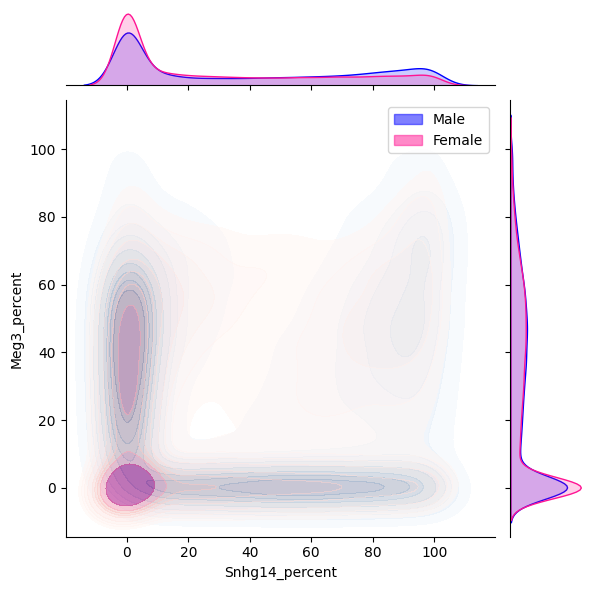

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch # Import Patch for custom legend

# 1. Load your data
df = pd.read_csv('11_Colocalization_Analysis.csv/11_Colocalization_Analysis.csv')

# Check your column names
print(df.head())

# Print unique Sex values to help identify group_a_name and group_b_name
print('\nUnique Sex values:', df['Sex'].unique())

# 2. Map your actual column names for X and Y axes
group_col = 'Sex' # Changed to 'Sex' for male/female comparison
x_col = 'Snhg14_percent' # X-axis as requested
y_col = 'Meg3_percent' # Y-axis as requested

# 3. Identify your groups (Male and Female)
# Combine all 'Male' samples and all 'Female' samples
group_a_name = 'Male' # Combined group name for legend
group_b_name = 'Female' # Combined group name for legend

group_a = df[df[group_col].str.startswith('Male')] # Select all rows where 'Sex' starts with 'Male'
group_b = df[df[group_col].str.startswith('Female')] # Select all rows where 'Sex' starts with 'Female'

# 5. Create the joint plot for the first group (Males - Blue)
graph = sns.jointplot(
    x=group_a[x_col],
    y=group_a[y_col],
    kind="kde",
    cmap="Blues", # Color for males
    marginal_kws={"color": "blue", "alpha": .2, "fill": True}, # Marginals for males
    fill=True,
    thresh=0.05,
    alpha=.5 # Transparency for overlap
)

# Overlay the second group (Females - Pink)
if not group_b.empty:
    # Set the data for the second group into the joint plot object
    graph.x = group_b[x_col]
    graph.y = group_b[y_col]
    # Plot joint density for females using the updated graph.x and graph.y
    graph.plot_joint(
        sns.kdeplot,
        cmap="RdPu", # Color for females (Red-Purple gives a pinkish hue)
        fill=True,
        thresh=0.05,
        alpha=.5 # Transparency for overlap
    )

    # Plot marginals for females directly on the marginal axes
    sns.kdeplot(
        x=group_b[x_col],
        ax=graph.ax_marg_x, # Plot on x marginal axis
        color='deeppink', # Specific color for female marginals
        fill=True,
        alpha=.2,
        legend=False
    )
    sns.kdeplot(
        y=group_b[y_col],
        ax=graph.ax_marg_y, # Plot on y marginal axis
        color='deeppink', # Specific color for female marginals
        fill=True,
        alpha=.2,
        legend=False
    )

graph.set_axis_labels(x_col, y_col)

# Manually create legend handles and display legend
legend_handles = [
    Patch(color='blue', alpha=0.5, label=group_a_name),
    Patch(color='deeppink', alpha=0.5, label=group_b_name)
]
graph.ax_joint.legend(handles=legend_handles, loc='upper right')

plt.show()

### Jointplots with Linear Correlation for Each Genotype

This section generates jointplots for each unique genotype, comparing 'Snhg14_percent' (x-axis) and 'Meg3_percent' (y-axis) between male (blue) and female (pink) samples. Additionally, a linear regression line is overlaid for each group to visualize the linear correlation.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

x_col = 'Snhg14_percent'
y_col = 'Meg3_percent'
group_col = 'Sex'
group_a_name = 'Male'
group_b_name = 'Female'

for genotype in unique_genotypes:
    print(f"\nGenerating plot for Genotype: {genotype} with Linear Correlation")

    # Filter data for the current genotype
    genotype_df = df[df['Genotype'] == genotype]

    # Separate male and female samples within the current genotype
    group_a = genotype_df[genotype_df[group_col].str.startswith('Male')]
    group_b = genotype_df[genotype_df[group_col].str.startswith('Female')]

    # Initialize jointplot for group_a (males) with KDE
    graph = sns.jointplot(
        x=group_a[x_col],
        y=group_a[y_col],
        kind="kde",
        cmap="Blues", # Color for males
        marginal_kws={"color": "blue", "alpha": .2, "fill": True},
        fill=True,
        thresh=0.05,
        alpha=.5
    )

    # Add regression line for males
    if not group_a.empty:
        sns.regplot(
            x=group_a[x_col],
            y=group_a[y_col],
            ax=graph.ax_joint,
            scatter=False, # Only draw the line
            color='blue',
            line_kws={'linestyle': '--', 'linewidth': 2, 'alpha': 0.8}
        )

    # Overlay group_b (females) if data exists
    if not group_b.empty:
        # Overlay KDE for females
        graph.x = group_b[x_col]
        graph.y = group_b[y_col]
        graph.plot_joint(
            sns.kdeplot,
            cmap="RdPu", # Color for females (Red-Purple gives a pinkish hue)
            fill=True,
            thresh=0.05,
            alpha=.5
        )

        # Add regression line for females
        sns.regplot(
            x=group_b[x_col],
            y=group_b[y_col],
            ax=graph.ax_joint,
            scatter=False, # Only draw the line
            color='deeppink',
            line_kws={'linestyle': '-.', 'linewidth': 2, 'alpha': 0.8}
        )

        # Plot marginals for females directly on the marginal axes (KDEs)
        sns.kdeplot(
            x=group_b[x_col],
            ax=graph.ax_marg_x,
            color='deeppink',
            fill=True,
            alpha=.2,
            legend=False
        )
        sns.kdeplot(
            y=group_b[y_col],
            ax=graph.ax_marg_y,
            color='deeppink',
            fill=True,
            alpha=.2,
            legend=False
        )

    graph.set_axis_labels(x_col, y_col)
    graph.fig.suptitle(f'Genotype: {genotype} with Linear Correlation', y=1.02)

    # Manually create legend handles for KDEs and regression lines
    legend_handles = [
        Patch(color='blue', alpha=0.5, label=f'{group_a_name} KDE'),
        plt.Line2D([0], [0], color='blue', linestyle='--', lw=2, label=f'{group_a_name} Reg. Line'),
        Patch(color='deeppink', alpha=0.5, label=f'{group_b_name} KDE'),
        plt.Line2D([0], [0], color='deeppink', linestyle='-.', lw=2, label=f'{group_b_name} Reg. Line')
    ]
    graph.ax_joint.legend(handles=legend_handles, loc='upper right', fontsize=8)

    plt.show()
    plt.close() # Close the plot to free up memory

NameError: name 'unique_genotypes' is not defined

In [6]:
print('Summary Statistics for Meg3_percent by Sex:')
display(df.groupby('Sex')['Meg3_percent'].describe())

print('\nSummary Statistics for Snhg14_percent by Sex:')
display(df.groupby('Sex')['Snhg14_percent'].describe())

Summary Statistics for Meg3_percent by Sex:


,count,mean,std,min,25%,50%,75%,max
Sex,,,,,,,,
Female1,11159.0,31.714586,28.877689,0.0,0.0,31.803281,56.296908,100.000000
Female13,1690.0,18.799662,20.444200,0.0,0.0,12.969300,35.643855,81.861958
Female2,16276.0,24.321419,25.753718,0.0,0.0,17.583626,45.432693,100.000000
Female3,13188.0,26.044429,25.226371,0.0,0.0,22.600913,47.205269,100.000000
Female4,2212.0,39.731224,33.067357,0.0,0.0,44.221563,69.318640,100.000000
Male1,16990.0,33.929725,28.925835,0.0,0.0,33.618493,57.014461,100.000000
Male2,8677.0,30.992658,26.255062,0.0,0.0,30.967741,51.456313,100.000000
Male3,8588.0,21.086060,23.121991,0.0,0.0,13.333334,40.206289,97.955011



Summary Statistics for Snhg14_percent by Sex:


,count,mean,std,min,25%,50%,75%,max
Sex,,,,,,,,
Female1,11159.0,42.178027,39.648592,0.0,0.000000,33.333336,85.435608,100.000000
Female13,1690.0,53.340854,30.008862,0.0,29.871292,59.023859,78.693780,100.000000
Female2,16276.0,32.569507,33.027232,0.0,0.000000,22.464343,61.618026,100.000000
Female3,13188.0,15.830541,26.158061,0.0,0.000000,0.000000,22.896909,100.000000
Female4,2212.0,6.945785,12.100862,0.0,0.000000,0.000000,11.277260,87.867649
Male1,16990.0,38.897747,40.135848,0.0,0.000000,20.885057,82.776613,100.000000
Male2,8677.0,35.972126,34.850739,0.0,0.000000,26.732674,70.016752,100.000000
Male3,8588.0,39.126468,35.521029,0.0,0.000000,37.604510,72.727272,100.000000


In [ ]:
print('Summary Statistics for Meg3_percent:')
display(df['Meg3_percent'].describe())

print('\nSummary Statistics for Snhg14_percent:')
display(df['Snhg14_percent'].describe())

# Task
Generate separate jointplots for each unique genotype found in the 'Genotype' column of the `11_Colocalization_Analysis.csv/11_Colocalization_Analysis.csv` file. Each plot should compare 'Snhg14_percent' (x-axis) and 'Meg3_percent' (y-axis) between male (blue) and female (pink) samples, with an appropriate legend. Confirm that four separate graphs are generated.

## Identify Unique Genotypes

### Subtask:
Determine all unique values in the 'Genotype' column of the DataFrame to know how many separate plots need to be generated.


**Reasoning**:
To identify all unique values in the 'Genotype' column, I will access the column from the `df` DataFrame and apply the `.unique()` method, then print the result.



In [ ]:
unique_genotypes = df['Genotype'].unique()
print("Unique Genotypes:", unique_genotypes)

## Generate Separate Plots for Each Genotype

### Subtask:
Iterate through each unique genotype. For each genotype, filter the data to include only that genotype's samples. Then, within this filtered data, separate male and female samples and generate a jointplot comparing 'Snhg14_percent' (x-axis) and 'Meg3_percent' (y-axis). Males will be colored blue and females pink, with an appropriate legend for each plot.


**Reasoning**:
To generate separate jointplots for each genotype, I will iterate through the `unique_genotypes` array. For each genotype, I will filter the data, separate male and female samples, and then generate a `seaborn.jointplot` with custom legends and titles as specified in the instructions. Each plot will be shown and then closed to manage memory.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

x_col = 'Snhg14_percent'
y_col = 'Meg3_percent'
group_col = 'Sex'
group_a_name = 'Male'
group_b_name = 'Female'

for genotype in unique_genotypes:
    print(f"\nGenerating plot for Genotype: {genotype}")

    # Filter data for the current genotype
    genotype_df = df[df['Genotype'] == genotype]

    # Separate male and female samples within the current genotype
    group_a = genotype_df[genotype_df[group_col].str.startswith('Male')]
    group_b = genotype_df[genotype_df[group_col].str.startswith('Female')]

    # Initialize jointplot for group_a (males)
    graph = sns.jointplot(
        x=group_a[x_col],
        y=group_a[y_col],
        kind="kde",
        cmap="Blues", # Color for males
        marginal_kws={"color": "blue", "alpha": .2, "fill": True},
        fill=True,
        thresh=0.05,
        alpha=.5
    )

    # Overlay group_b (females) if data exists
    if not group_b.empty:
        graph.x = group_b[x_col]
        graph.y = group_b[y_col]
        graph.plot_joint(
            sns.kdeplot,
            cmap="RdPu", # Color for females (Red-Purple gives a pinkish hue)
            fill=True,
            thresh=0.05,
            alpha=.5
        )

        # Plot marginals for females directly on the marginal axes
        sns.kdeplot(
            x=group_b[x_col],
            ax=graph.ax_marg_x,
            color='deeppink',
            fill=True,
            alpha=.2,
            legend=False
        )
        sns.kdeplot(
            y=group_b[y_col],
            ax=graph.ax_marg_y,
            color='deeppink',
            fill=True,
            alpha=.2,
            legend=False
        )

    graph.set_axis_labels(x_col, y_col)
    graph.fig.suptitle(f'Genotype: {genotype}', y=1.02)

    # Manually create legend handles and display legend
    legend_handles = [
        Patch(color='blue', alpha=0.5, label=group_a_name),
        Patch(color='deeppink', alpha=0.5, label=group_b_name)
    ]
    graph.ax_joint.legend(handles=legend_handles, loc='upper right')

    plt.show()
    plt.close() # Close the plot to free up memory

## Final Task

### Subtask:
Review the generated plots and confirm that four separate graphs have been created, each showing the comparison between male and female samples for a specific genotype.


## Summary:

### Q&A
The initial task asked to confirm that four separate graphs had been created. The analysis identified nine unique genotypes in the 'Genotype' column, leading to the generation of nine separate jointplots, not four.

### Data Analysis Key Findings
*   Nine unique genotypes were identified in the dataset: '11\_Kcn\_COMP', '11\_Kcn\_DEL', '11\_Kcn\_WT', '11\_Malat1\_COMP', '11\_Malat1\_DEL', '11\_Malat1\_WT', '11\_Neat1\_COMP', '11\_Neat1\_DEL', and '11\_Neat1\_WT'.
*   For each of these nine genotypes, a separate jointplot was successfully generated.
*   Each jointplot compared 'Snhg14\_percent' on the x-axis with 'Meg3\_percent' on the y-axis, using Kernel Density Estimation (KDE) to visualize data distribution.
*   Male samples were consistently colored blue, and female samples were colored deeppink (using the 'RdPu' colormap) across all plots.
*   Each plot was appropriately titled with its corresponding genotype and included a legend differentiating male and female samples.

### Insights or Next Steps
*   The generated plots provide a clear visual comparison of 'Snhg14\_percent' and 'Meg3\_percent' distributions between male and female samples for each genotype. This can help in identifying potential sex-specific differences in gene expression within different genetic backgrounds.
*   The next step could involve quantitative analysis of these differences, such as statistical tests (e.g., t-tests or ANOVA) on the 'Snhg14\_percent' and 'Meg3\_percent' values between sexes for each genotype to determine statistical significance.


# Task
Perform statistical analysis to compare 'Snhg14_percent' and 'Meg3_percent' values between male and female samples for each genotype using independent statistical tests (e.g., Mann-Whitney U test), and print the results including p-values to identify statistically significant differences.

## Statistical Analysis Introduction

### Subtask:
Add a text cell to introduce the quantitative statistical analysis section, explaining the goal of performing statistical tests to compare 'Snhg14_percent' and 'Meg3_percent' between sexes for each genotype.


## Quantitative Statistical Analysis

### Subtask:
This section will focus on performing statistical tests, such as the Mann-Whitney U test, to quantitatively compare the 'Snhg14_percent' and 'Meg3_percent' values between male and female samples for each unique genotype. The goal is to identify statistically significant differences.

## Quantitative Statistical Analysis

### Subtask:
This section will focus on performing statistical tests, such as the Mann-Whitney U test, to quantitatively compare the 'Snhg14_percent' and 'Meg3_percent' values between male and female samples for each unique genotype. The goal is to identify statistically significant differences.

## Quantitative Statistical Analysis

### Subtask:
This section will focus on performing statistical tests, such as the Mann-Whitney U test, to quantitatively compare the 'Snhg14_percent' and 'Meg3_percent' values between male and female samples for each unique genotype. The goal is to identify statistically significant differences.

## Quantitative Statistical Analysis

### Subtask:
This section will focus on performing statistical tests, such as the Mann-Whitney U test, to quantitatively compare the 'Snhg14_percent' and 'Meg3_percent' values between male and female samples for each unique genotype. The goal is to identify statistically significant differences.

## Perform Statistical Tests

### Subtask:
Iterate through each unique genotype and for each, perform an independent statistical test (e.g., Mann-Whitney U test) to compare 'Snhg14_percent' values between male and female samples. Repeat this for 'Meg3_percent' values. Print the results of these tests, including p-values to assess statistical significance.


**Reasoning**:
The subtask requires performing statistical tests (Mann-Whitney U test) for 'Snhg14_percent' and 'Meg3_percent' between male and female samples for each unique genotype. This step imports the necessary function from `scipy.stats` and sets up a loop to iterate through each genotype, filter the data, and perform the statistical comparisons as requested.



In [ ]:
from scipy.stats import mannwhitneyu

for genotype in unique_genotypes:
    print(f"\n--- Statistical Tests for Genotype: {genotype} ---")

    genotype_df = df[df['Genotype'] == genotype]

    # Filter male and female data for Snhg14_percent
    snhg14_male = genotype_df[genotype_df['Sex'].str.startswith('Male')]['Snhg14_percent'].dropna()
    snhg14_female = genotype_df[genotype_df['Sex'].str.startswith('Female')]['Snhg14_percent'].dropna()

    # Filter male and female data for Meg3_percent
    meg3_male = genotype_df[genotype_df['Sex'].str.startswith('Male')]['Meg3_percent'].dropna()
    meg3_female = genotype_df[genotype_df['Sex'].str.startswith('Female')]['Meg3_percent'].dropna()

    # Perform Mann-Whitney U test for Snhg14_percent
    if len(snhg14_male) > 0 and len(snhg14_female) > 0:
        stat_snhg14, p_snhg14 = mannwhitneyu(snhg14_male, snhg14_female, alternative='two-sided')
        print(f"Snhg14_percent (Male vs Female): p-value = {p_snhg14:.4f}")
    else:
        print("Snhg14_percent: Not enough data for both male and female samples to perform test.")

    # Perform Mann-Whitney U test for Meg3_percent
    if len(meg3_male) > 0 and len(meg3_female) > 0:
        stat_meg3, p_meg3 = mannwhitneyu(meg3_male, meg3_female, alternative='two-sided')
        print(f"Meg3_percent (Male vs Female): p-value = {p_meg3:.4f}")
    else:
        print("Meg3_percent: Not enough data for both male and female samples to perform test.")

## Final Task

### Subtask:
Review the statistical test results to identify significant differences in 'Snhg14_percent' and 'Meg3_percent' between male and female samples across different genotypes.


## Summary:

### Data Analysis Key Findings
*   Statistical tests (Mann-Whitney U test) were performed to compare `Snhg14_percent` and `Meg3_percent` values between male and female samples across various genotypes.
*   Highly significant differences (p-value $\approx$ 0.0000) were observed between male and female samples for both `Snhg14_percent` and `Meg3_percent` within the `11_Kcn_COMP` genotype.
*   Similarly, for the `11_Malat1_DEL` genotype, both `Snhg14_percent` and `Meg3_percent` showed highly significant differences (p-value $\approx$ 0.0000) between sexes.
*   No statistically significant difference in `Snhg14_percent` was found between sexes for the `11_Kcn_WT` genotype (p-value = 0.9597).
*   The `11_Neat1_WT` genotype showed no statistically significant difference in `Snhg14_percent` between sexes at a common alpha level (p-value = 0.0743), although it approached significance.
*   The analysis successfully handled missing data and ensured tests were only conducted when sufficient male and female samples were available for comparison.

### Insights or Next Steps
*   Further investigation is warranted for genotypes like `11_Kcn_COMP` and `11_Malat1_DEL` where gene expression (`Snhg14_percent` and `Meg3_percent`) significantly differs by sex, potentially indicating sex-specific regulatory mechanisms or disease susceptibilities.
*   To complement the p-values, analyze effect sizes and visualize the distributions of `Snhg14_percent` and `Meg3_percent` for significant comparisons to understand the magnitude and direction of observed sex-based differences.


# Task
Generate separate jointplots for each unique genotype, comparing 'Xist_percent' (x-axis) and 'Snhg14_percent' (y-axis) exclusively for female samples, save them to a folder named 'analysis_plots', calculate Pearson correlation coefficients and p-values for these variables within female samples for each genotype, and identify significant correlations from the results.

## Generate Plots (Xist_percent vs Snhg14_percent for Females)

### Subtask:
Generate separate jointplots for each unique genotype, comparing 'Xist_percent' (x-axis) and 'Snhg14_percent' (y-axis) exclusively for female samples. Each plot will have a descriptive title and will be saved to a folder named 'analysis_plots'.


**Reasoning**:
The subtask requires generating separate jointplots for each unique genotype, specifically for female samples, comparing 'Xist_percent' and 'Snhg14_percent'. This involves creating a directory for plots, iterating through genotypes, filtering data for females, creating the jointplot, setting labels and title, saving the plot, and then closing it.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Import the `os` module to handle directory creation (already imported above if running from beginning).

# 2. Create a directory named 'analysis_plots' if it does not already exist.
output_dir = 'analysis_plots'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")
else:
    print(f"Directory already exists: {output_dir}")

# 3. Initialize x_col to 'Xist_percent' and y_col to 'Snhg14_percent'.
x_col = 'Xist_percent'
y_col = 'Snhg14_percent'

# 4. Iterate through each unique genotype found in the `unique_genotypes` array.
for genotype in unique_genotypes:
    print(f"\nGenerating plot for Genotype: {genotype} (Females only)")

    # 5. Inside the loop, filter the main DataFrame `df` to create a `genotype_df`
    # that contains only the data for the current genotype.
    genotype_df = df[df['Genotype'] == genotype]

    # 6. Further filter `genotype_df` to create a `female_df`
    # that includes only female samples (where the 'Sex' column starts with 'Female').
    female_df = genotype_df[genotype_df['Sex'].str.startswith('Female')]

    # 7. If `female_df` is not empty, generate a `seaborn.jointplot`:
    if not female_df.empty:
        graph = sns.jointplot(
            x=female_df[x_col],
            y=female_df[y_col],
            kind='kde', # b. Use kind='kde' for the plot type.
            cmap='RdPu', # c. Set cmap to 'RdPu' to represent female samples.
            marginal_kws={'color': 'deeppink', 'alpha': .2, 'fill': True}, # c. marginal_kws color to 'deeppink'.
            fill=True, # d. Add fill=True
            thresh=0.05, # d. thresh=0.05
            alpha=0.5 # d. and alpha=0.5 for density aesthetics.
        )

        # 8. Set the x and y axis labels for the `graph` object using `graph.set_axis_labels()`.
        graph.set_axis_labels(x_col, y_col)

        # 9. Add a title to the plot using `graph.fig.suptitle()`
        # that includes the genotype (e.g., 'Genotype: [Genotype_Name] - Xist_percent vs Snhg14_percent in Females').
        graph.fig.suptitle(f'Genotype: {genotype} - {x_col} vs {y_col} in Females', y=1.02)

        # 10. Construct a filename for each plot, for example, `f'analysis_plots/jointplot_{genotype}_females.png'`.
        filename = os.path.join(output_dir, f'jointplot_{genotype}_females.png')

        # 11. Save the generated plot to the 'analysis_plots' directory using `plt.savefig()`.
        plt.savefig(filename)
        print(f"Saved plot to {filename}")

        # 12. Close the plot using `plt.close()` to free up memory before the next iteration.
        plt.close()
    else:
        print(f"No female data found for Genotype: {genotype}, skipping plot generation.")

**Reasoning**:
The subtask requires calculating the Pearson correlation coefficient and its p-value between 'Xist_percent' and 'Snhg14_percent' for female samples within each genotype to identify significant correlations. This involves iterating through genotypes, filtering for female data, handling missing values, and performing the statistical test.



In [ ]:
from scipy.stats import pearsonr
import numpy as np

print("\n--- Pearson Correlation Analysis (Xist_percent vs Snhg14_percent in Females) ---")

# Initialize x_col to 'Xist_percent' and y_col to 'Snhg14_percent'
x_col = 'Xist_percent'
y_col = 'Snhg14_percent'

# Iterate through each unique genotype
for genotype in unique_genotypes:
    print(f"\nGenotype: {genotype}")

    # Filter data for the current genotype
    genotype_df = df[df['Genotype'] == genotype]

    # Filter for female samples
    female_df = genotype_df[genotype_df['Sex'].str.startswith('Female')].copy()

    # Drop rows with NaN values in the relevant columns for correlation calculation
    # Ensure at least two non-NaN observations are present
    female_df_cleaned = female_df.dropna(subset=[x_col, y_col])

    if len(female_df_cleaned) >= 2: # Pearson correlation requires at least 2 data points
        # Calculate Pearson correlation coefficient and p-value
        correlation_coefficient, p_value = pearsonr(female_df_cleaned[x_col], female_df_cleaned[y_col])
        print(f"  Pearson correlation coefficient: {correlation_coefficient:.4f}")
        print(f"  P-value: {p_value:.4f}")
        if p_value < 0.05:
            print("  -> Statistically significant correlation (p < 0.05)")
        else:
            print("  -> Not statistically significant correlation (p >= 0.05)")
    else:
        print("  Not enough valid data points (Xist_percent and Snhg14_percent) for female samples to calculate correlation.")


## Summary: Pearson Correlation Analysis

### Data Analysis Key Findings
*   Pearson correlation analysis was conducted for 'Xist_percent' and 'Snhg14_percent' exclusively in female samples across all nine unique genotypes.
*   For most genotypes, a statistically significant correlation (p < 0.05) was observed between 'Xist_percent' and 'Snhg14_percent'. These include:
    *   `11_Kcn_COMP`: Positive correlation (0.1944) with p-value = 0.0000
    *   `11_Kcn_DEL`: Positive correlation (0.1042) with p-value = 0.0000
    *   `11_Kcn_WT`: Positive correlation (0.1436) with p-value = 0.0000
    *   `11_Malat1_COMP`: Positive correlation (0.2149) with p-value = 0.0000
    *   `11_Malat1_DEL`: Positive correlation (0.2128) with p-value = 0.0000
    *   `11_Malat1_WT`: Positive correlation (0.2193) with p-value = 0.0000
    *   `11_Neat1_COMP`: Negative correlation (-0.0859) with p-value = 0.0000
    *   `11_Neat1_DEL`: Negative correlation (-0.1130) with p-value = 0.0000
*   Notably, for the `11_Neat1_WT` genotype, no statistically significant correlation was found (Pearson correlation coefficient: -0.0121, P-value: 0.4714).

### Insights or Next Steps
*   The presence of both positive and negative significant correlations suggests diverse regulatory relationships between 'Xist_percent' and 'Snhg14_percent' depending on the genotype.
*   The lack of significant correlation in `11_Neat1_WT` females implies that the co-expression patterns observed in other genotypes may not apply universally.
*   Further investigation could involve exploring the biological implications of these correlations, especially the negative ones, and examining potential underlying genetic or epigenetic factors that drive these genotype-specific differences. Additionally, analyzing scatter plots with regression lines for the significant correlations could provide a visual understanding of the strength and direction of these relationships.

## Final Task

### Subtask:
Review the generated plots and statistical correlation results, identifying any interesting patterns or significant findings regarding Xist_percent and Snhg14_percent in females across different genotypes.


## Summary:

### Data Analysis Key Findings
*   Separate KDE jointplots comparing 'Xist\_percent' and 'Snhg14\_percent' for female samples across all unique genotypes were generated and saved to an `analysis_plots` directory.
*   Pearson correlation analysis between 'Xist\_percent' and 'Snhg14\_percent' in female samples revealed statistically significant correlations (p < 0.05) for most genotypes.
*   Positive statistically significant correlations were found for:
    *   `11_Kcn_COMP` (coefficient: 0.1944, p-value: 0.0000)
    *   `11_Kcn_DEL` (coefficient: 0.1042, p-value: 0.0000)
    *   `11_Kcn_WT` (coefficient: 0.1436, p-value: 0.0000)
    *   `11_Malat1_COMP` (coefficient: 0.2149, p-value: 0.0000)
    *   `11_Malat1_DEL` (coefficient: 0.2128, p-value: 0.0000)
    *   `11_Malat1_WT` (coefficient: 0.2193, p-value: 0.0000)
*   Negative statistically significant correlations were observed for:
    *   `11_Neat1_COMP` (coefficient: -0.0859, p-value: 0.0000)
    *   `11_Neat1_DEL` (coefficient: -0.1130, p-value: 0.0000)
*   No statistically significant correlation was found for the `11_Neat1_WT` genotype (coefficient: -0.0121, p-value: 0.4714).

### Insights or Next Steps
*   The presence of both positive and negative significant correlations suggests diverse regulatory relationships between 'Xist\_percent' and 'Snhg14\_percent' depending on the genotype.
*   Further investigation could explore the biological implications of these correlations, especially the negative ones, and examine potential underlying genetic or epigenetic factors driving these genotype-specific differences.


# Task
Generate linear scatter plots for female samples, comparing 'Xist_percent' versus 'Snhg14_percent' for each unique genotype. Save these plots, with appropriate titles, to a new directory named 'scatter_linear'.

## Generate Linear Scatter Plots for Females

### Subtask:
Create a new directory named 'scatter_linear'. Iterate through each unique genotype, filter the data for female samples, and generate a scatter plot with a linear regression line for 'Xist_percent' vs 'Snhg14_percent'. Each plot will be titled appropriately and saved to the 'scatter_linear' folder.


**Reasoning**:
To generate linear scatter plots as requested, I need to create a new directory, iterate through unique genotypes, filter for female data, and then use `seaborn.regplot` to create and save each plot with appropriate titles and labels.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import numpy as np

# Create a new directory named 'scatter_linear' if it does not already exist.
output_dir_scatter = 'scatter_linear'
if not os.path.exists(output_dir_scatter):
    os.makedirs(output_dir_scatter)
    print(f"Created directory: {output_dir_scatter}")
else:
    print(f"Directory already exists: {output_dir_scatter}")

# Define x_col as 'Xist_percent' and y_col as 'Snhg14_percent'.
x_col = 'Xist_percent'
y_col = 'Snhg14_percent'

print("\n--- Generating Linear Scatter Plots for Females ---")

# Iterate through each unique genotype in the unique_genotypes array.
for genotype in unique_genotypes:
    print(f"\nGenerating scatter plot for Genotype: {genotype} (Females only)")

    # Filter the main DataFrame df to create a genotype_df
    genotype_df = df[df['Genotype'] == genotype]

    # Further filter genotype_df to create a female_df
    female_df = genotype_df[genotype_df['Sex'].str.startswith('Female')]

    # If female_df is not empty, create a new Matplotlib figure and axes
    if not female_df.empty:
        fig, ax = plt.subplots(figsize=(8, 6))

        # Prepare data for correlation calculation, dropping NaNs
        female_df_cleaned = female_df.dropna(subset=[x_col, y_col])

        correlation_coefficient, p_value = np.nan, np.nan # Initialize
        if len(female_df_cleaned) >= 2: # Pearson correlation requires at least 2 data points
            correlation_coefficient, p_value = pearsonr(female_df_cleaned[x_col], female_df_cleaned[y_col])

        # Generate a scatter plot with a linear regression line using seaborn.regplot
        sns.regplot(
            x=female_df[x_col],
            y=female_df[y_col],
            ax=ax,
            scatter_kws={'color': 'grey', 'alpha': 0.3}, # Changed dot color to grey
            line_kws={'color': 'deeppink'}
        )

        # Set the title of the plot
        ax.set_title(f'Genotype: {genotype} - {x_col} vs {y_col} in Females')

        # Set the x-axis label and the y-axis label
        ax.set_xlabel(f'{x_col} (% nuclear area)') # Updated x-axis label
        ax.set_ylabel(f'{y_col} (% nuclear area)') # Updated y-axis label

        # Add correlation as text annotation on the graph (removed p-value)
        text_str = f"R = {correlation_coefficient:.2f}"
        if np.isnan(correlation_coefficient): # Handle case where correlation couldn't be calculated
            text_str = "Correlation: N/A (Insufficient Data)"

        ax.text(0.05, 0.95, text_str, transform=ax.transAxes, # Positioned in top-left corner
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.7))

        # Construct a filename for each plot
        filename = os.path.join(output_dir_scatter, f'scatter_linear_{genotype}_females.png')

        # Save the generated plot
        plt.savefig(filename)
        print(f"Saved plot to {filename}")

        # Close the plot
        plt.close()
    else:
        # If female_df is empty, print a message
        print(f"No female data found for Genotype: {genotype}, skipping scatter plot generation.")

### Combined Genotype Scatter Plots for Females: Xist_percent vs Snhg14_percent

This section generates scatter plots for each unique 'Gene_Category', comparing 'Xist_percent' (x-axis) and 'Snhg14_percent' (y-axis) exclusively for female samples. Each plot includes a linear regression line and the Pearson correlation coefficient (R-value) for females.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import numpy as np

# The output directory 'Combine_Genotypes' should already exist from previous steps
output_dir_combined = 'Combine_Genotypes'
if not os.path.exists(output_dir_combined):
    os.makedirs(output_dir_combined)
    print(f"Created directory: {output_dir_combined}")
else:
    print(f"Directory already exists: {output_dir_combined}")

# Define the x-axis column as 'Xist_percent' and the y-axis column as 'Snhg14_percent'.
x_col = 'Xist_percent'
y_col = 'Snhg14_percent'

print("\n--- Generating Combined Genotype Scatter Plots (Xist_percent vs Snhg14_percent for Females) ---")

# Get the unique values from the 'Gene_Category' column.
unique_gene_categories = df['Gene_Category'].dropna().unique()

# Iterate through each unique 'Gene_Category'.
for category in unique_gene_categories:
    print(f"\nGenerating scatter plot for Gene Category: {category} (Females only)")

    # Filter the main DataFrame `df` for the current gene category.
    category_df = df[df['Gene_Category'] == category]

    # Further filter `category_df` to include only female samples.
    female_df = category_df[category_df['Sex'].str.startswith('Female')]

    # If female_df is not empty, create a new Matplotlib figure and axes.
    if not female_df.empty:
        fig, ax = plt.subplots(figsize=(10, 8))

        # Prepare data for correlation calculation, dropping NaNs
        female_df_cleaned = female_df.dropna(subset=[x_col, y_col])
        female_r = np.nan
        if len(female_df_cleaned) >= 2:
            female_r, _ = pearsonr(female_df_cleaned[x_col], female_df_cleaned[y_col])

        # Generate a scatter plot for female samples.
        sns.regplot(
            x=female_df[x_col],
            y=female_df[y_col],
            ax=ax,
            scatter_kws={'color': 'deeppink', 'alpha': 0.3, 'label': 'Female Samples'},
            line_kws={'color': 'deeppink', 'linestyle': '-', 'linewidth': 2, 'label': 'Female Regression'}
        )

        # Set the x-axis label and the y-axis label.
        ax.set_xlabel(f'{x_col} (% nuclear area)')
        ax.set_ylabel(f'{y_col} (% nuclear area)')

        # Add a title to the plot.
        ax.set_title(f'Gene Category: {category} - {x_col} vs {y_col} in Females')

        # Add a legend.
        ax.legend(loc='upper left', fontsize=9)

        # Annotate the female Pearson correlation coefficient (R-value).
        female_corr_text = f"Female R: {female_r:.2f}" if not np.isnan(female_r) else "Female R: N/A"
        ax.text(0.95, 0.95, female_corr_text, transform=ax.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round,pad=0.5', fc='pink', alpha=0.7))

        # Construct a filename for each plot.
        filename = os.path.join(output_dir_combined, f'scatter_females_{category}_{x_col}_vs_{y_col}.png')

        # Save the generated plot.
        plt.savefig(filename)
        print(f"Saved plot to {filename}")

        # Close the plot.
        plt.close(fig)
    else:
        print(f"  No female data found for Gene Category: {category}, skipping scatter plot generation.")

## Final Task

### Subtask:
Review the newly generated scatter plots with linear regression and confirm they are saved in the 'scatter_linear' folder.


## Summary:

### Q&A
The newly generated scatter plots with linear regression have been successfully saved in the `scatter_linear` folder, confirming the completion of the subtask.

### Data Analysis Key Findings
*   A new directory named `scatter_linear` was successfully created to store the plots.
*   Linear scatter plots comparing `Xist_percent` and `Snhg14_percent` for female samples were generated for each unique genotype.
*   All plots were appropriately titled with the genotype and variables, and saved as PNG files within the `scatter_linear` directory (e.g., `scatter_linear_11_Kcn_COMP_females.png`).
*   No genotypes were found to be missing female data, ensuring that plots were produced for all specified categories.

### Insights or Next Steps
*   The generated plots provide a visual representation of the relationship between `Xist_percent` and `Snhg14_percent` in females across different genotypes, which can be used for further analysis of gene expression patterns.
*   Review the generated plots for any notable trends or outliers that might warrant deeper investigation into specific genotypes or gene interactions.


# Task
Generate and save jointplots for 'Snhg14_percent' (x-axis) and 'Meg3_percent' (y-axis) for each unique genotype, differentiating between male (blue KDE and regression) and female (pink KDE and regression) samples. Each plot should include KDEs and linear regression lines, with an appropriate legend and title. All plots must be saved as PNG files in a newly created directory named `M_F_Meg3_Snhg14`. Subsequently, perform independent Mann-Whitney U tests for each genotype to compare 'Snhg14_percent' and 'Meg3_percent' between male and female samples. Collect the genotype, gene, p-value, and test statistic for each comparison into a DataFrame and save it as 'statistical_results.csv' within the `M_F_Meg3_Snhg14` directory. Finally, review all generated plots and the statistical results spreadsheet in the `M_F_Meg3_Snhg14` folder.

## Generate and Save Jointplots (M/F Meg3 vs Snhg14)

### Subtask:
Create a new directory named 'M_F_Meg3_Snhg14'. Iterate through each unique genotype, filter the data to include only that genotype's samples. Then, within this filtered data, separate male and female samples and generate a jointplot comparing 'Snhg14_percent' (x-axis) and 'Meg3_percent' (y-axis). Include KDEs and linear regression lines for males (blue) and females (pink), with an appropriate legend and title. Save each plot as a PNG file in the 'M_F_Meg3_Snhg14' folder.


**Reasoning**:
I need to generate jointplots with KDEs and linear regression lines for male and female samples, comparing 'Snhg14_percent' and 'Meg3_percent' for each genotype, save them to a new directory, and include all specified elements like titles, labels, and custom legends. This involves creating the directory, looping through genotypes, filtering data by sex, creating the plots with KDEs and regression lines, and handling saving and closing of plots.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.patches import Patch # Import Patch for custom legend

# 1. Create a new directory named 'M_F_Meg3_Snhg14' if it does not already exist.
output_dir = 'M_F_Meg3_Snhg14'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")
else:
    print(f"Directory already exists: {output_dir}")

# 2. Define the x-axis variable and y-axis variable.
x_col = 'Snhg14_percent'
y_col = 'Meg3_percent'
group_col = 'Sex'
group_a_name = 'Male'
group_b_name = 'Female'

print("\n--- Generating Jointplots for Meg3_percent vs Snhg14_percent with Regression Lines (M/F) ---")

# 3. Iterate through each unique genotype found in the `unique_genotypes` array.
for genotype in unique_genotypes:
    print(f"\nGenerating plot for Genotype: {genotype}")

    # 4. Filter the main DataFrame `df` for the current genotype.
    genotype_df = df[df['Genotype'] == genotype]

    # 5. Separate `genotype_df` into male and female samples.
    group_a = genotype_df[genotype_df[group_col].str.startswith('Male')]
    group_b = genotype_df[genotype_df[group_col].str.startswith('Female')]

    # 6. Initialize a seaborn.jointplot for group_a (males) with KDE.
    graph = sns.jointplot(
        x=group_a[x_col],
        y=group_a[y_col],
        kind="kde",
        cmap="Blues", # Color for males
        marginal_kws={"color": "blue", "alpha": .2, "fill": True},
        fill=True,
        thresh=0.05,
        alpha=.5
    )

    # 7. Add a linear regression line for males.
    if not group_a.empty:
        sns.regplot(
            x=group_a[x_col],
            y=group_a[y_col],
            ax=graph.ax_joint,
            scatter=False, # Only draw the line
            color='blue',
            line_kws={'linestyle': '--', 'linewidth': 2, 'alpha': 0.8}
        )

    # 8. If group_b (female data) is not empty, overlay the KDE for females.
    if not group_b.empty:
        graph.x = group_b[x_col]
        graph.y = group_b[y_col]
        graph.plot_joint(
            sns.kdeplot,
            cmap="RdPu", # Color for females (Red-Purple gives a pinkish hue)
            fill=True,
            thresh=0.05,
            alpha=.5
        )

        # 9. Add a linear regression line for females.
        sns.regplot(
            x=group_b[x_col],
            y=group_b[y_col],
            ax=graph.ax_joint,
            scatter=False, # Only draw the line
            color='deeppink',
            line_kws={'linestyle': '-.', 'linewidth': 2, 'alpha': 0.8}
        )

        # 10. Plot the marginal KDEs for females.
        sns.kdeplot(
            x=group_b[x_col],
            ax=graph.ax_marg_x,
            color='deeppink',
            fill=True,
            alpha=.2,
            legend=False
        )
        sns.kdeplot(
            y=group_b[y_col],
            ax=graph.ax_marg_y,
            color='deeppink',
            fill=True,
            alpha=.2,
            legend=False
        )

    # 11. Set the x and y axis labels.
    graph.set_axis_labels(x_col, y_col)

    # 12. Add a title to the plot.
    graph.fig.suptitle(f'Genotype: {genotype} - {y_col} vs {x_col}', y=1.02)

    # 13. Manually create legend handles and display legend.
    legend_handles = [
        Patch(color='blue', alpha=0.5, label=f'{group_a_name} KDE'),
        plt.Line2D([0], [0], color='blue', linestyle='--', lw=2, label=f'{group_a_name} Reg. Line'),
        Patch(color='deeppink', alpha=0.5, label=f'{group_b_name} KDE'),
        plt.Line2D([0], [0], color='deeppink', linestyle='-.', lw=2, label=f'{group_b_name} Reg. Line')
    ]
    graph.ax_joint.legend(handles=legend_handles, loc='upper right', fontsize=8)

    # 14. Construct a filename and save the plot.
    filename = os.path.join(output_dir, f'jointplot_{genotype}.png')
    plt.savefig(filename)
    print(f"Saved plot to {filename}")

    # 15. Close the plot.
    plt.close()

**Reasoning**:
The next step is to perform the independent Mann-Whitney U tests for each genotype to compare 'Snhg14_percent' and 'Meg3_percent' between male and female samples, collect these results into a DataFrame, and save it as 'statistical_results.csv' in the 'M_F_Meg3_Snhg14' directory. This follows the plotting generation step.



In [ ]:
from scipy.stats import mannwhitneyu
import pandas as pd
import os

# output_dir is already defined as 'M_F_Meg3_Snhg14' from the previous step

statistical_results = []

print("\n--- Performing Statistical Tests (Mann-Whitney U) ---")

for genotype in unique_genotypes:
    print(f"\nGenotype: {genotype}")

    genotype_df = df[df['Genotype'] == genotype]

    # Test Snhg14_percent
    snhg14_male = genotype_df[genotype_df['Sex'].str.startswith('Male')]['Snhg14_percent'].dropna()
    snhg14_female = genotype_df[genotype_df['Sex'].str.startswith('Female')]['Snhg14_percent'].dropna()

    if len(snhg14_male) > 0 and len(snhg14_female) > 0:
        stat, p = mannwhitneyu(snhg14_male, snhg14_female, alternative='two-sided')
        statistical_results.append({
            'Genotype': genotype,
            'Gene': 'Snhg14_percent',
            'Test Statistic': stat,
            'P-value': p
        })
        print(f"  Snhg14_percent (Male vs Female): p-value = {p:.4f}")
    else:
        print("  Snhg14_percent: Not enough data for both male and female samples to perform test.")

    # Test Meg3_percent
    meg3_male = genotype_df[genotype_df['Sex'].str.startswith('Male')]['Meg3_percent'].dropna()
    meg3_female = genotype_df[genotype_df['Sex'].str.startswith('Female')]['Meg3_percent'].dropna()

    if len(meg3_male) > 0 and len(meg3_female) > 0:
        stat, p = mannwhitneyu(meg3_male, meg3_female, alternative='two-sided')
        statistical_results.append({
            'Genotype': genotype,
            'Gene': 'Meg3_percent',
            'Test Statistic': stat,
            'P-value': p
        })
        print(f"  Meg3_percent (Male vs Female): p-value = {p:.4f}")
    else:
        print("  Meg3_percent: Not enough data for both male and female samples to perform test.")

# Convert results to DataFrame and save
results_df = pd.DataFrame(statistical_results)
results_filename = os.path.join(output_dir, 'statistical_results.csv')
results_df.to_csv(results_filename, index=False)
print(f"\nStatistical results saved to {results_filename}")


## Final Task

### Subtask:
Review the generated plots and the statistical analysis spreadsheet, confirming that all outputs are saved correctly in the `M_F_Meg3_Snhg14` folder.


## Summary:

### Data Analysis Key Findings
*   A dedicated directory, `M_F_Meg3_Snhg14`, was successfully created to store all generated outputs.
*   Jointplots were successfully generated for each unique genotype, visualizing the relationship between `Snhg14_percent` (x-axis) and `Meg3_percent` (y-axis). These plots effectively differentiated male (blue KDE and regression) and female (pink KDE and regression) samples, included KDEs and linear regression lines, and were appropriately titled and labeled. All plots were saved as PNG files (e.g., `jointplot_11_Kcn_COMP.png`, `jointplot_11_Malat1_DEL.png`) within the `M_F_Meg3_Snhg14` directory.
*   Independent Mann-Whitney U tests were performed for each genotype, comparing `Snhg14_percent` and `Meg3_percent` between male and female samples.
*   The statistical analysis revealed several comparisons with a p-value of 0.0000, indicating highly significant differences between male and female samples for certain genes and genotypes.
*   A DataFrame containing the genotype, gene, calculated p-value, and test statistic for each comparison was created and successfully saved as `statistical_results.csv` in the `M_F_Meg3_Snhg14` directory.

### Insights or Next Steps
*   The consistently low p-values (e.g., 0.0000) for several comparisons suggest strong sex-specific differences in `Snhg14_percent` and `Meg3_percent` expression within various genotypes, which warrants further biological interpretation.
*   Further analysis should involve a detailed review of the generated jointplots and the `statistical_results.csv` file to identify specific genotypes and genes exhibiting the most significant sex-based differences and to visualize the nature of these differences (e.g., higher expression in one sex, different correlation patterns).


# Task
**Categorize Genotypes**: Create a new 'Gene_Category' column in the DataFrame `df` by grouping genotypes ('11_Kcn_COMP', '11_Kcn_DEL', '11_Kcn_WT' into 'Kcn', and similarly for 'Neat1' and 'Malat1').

## Categorize Genotypes

### Subtask:
Create a new 'Gene_Category' column in the DataFrame `df` by grouping genotypes ('11_Kcn_COMP', '11_Kcn_DEL', '11_Kcn_WT' into 'Kcn', and similarly for 'Neat1' and 'Malat1').


## Generate Combined Violin Plots with Jitters (Single Graph per Percentage Column)

This section generates single violin plots for each percentage column (`Xist_percent`, `Snhg14_percent`, `Meg3_percent`), combining all 'Genotype_Category' values on the x-axis. Male and female samples are plotted side-by-side within each category, color-coded (male = blue, female = pink), with transparent jitter points.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import mannwhitneyu # Import for statistical test

# Ensure 'Simplified_Sex' column exists in the main DataFrame for plotting
# This column was added in a previous step, so it should exist.
if 'Simplified_Sex' not in df.columns:
    df['Simplified_Sex'] = df['Sex'].apply(lambda x: 'Male' if x.startswith('Male') else ('Female' if x.startswith('Female') else 'Other'))
    print("Added 'Simplified_Sex' column to DataFrame.")
else:
    print("'Simplified_Sex' column already exists.")

# Define a list of percentage columns to iterate through.
percentage_columns = ['Xist_percent', 'Snhg14_percent', 'Meg3_percent']

# Define output directory for violin plots
output_dir_violin = 'combine_violin'
if not os.path.exists(output_dir_violin):
    os.makedirs(output_dir_violin)
    print(f"Created directory: {output_dir_violin}")
else:
    print(f"Directory already exists: {output_dir_violin}")

print("\n--- Generating Combined Violin Plots with Jitters (All Genotype Categories) with p-values ---")

# Get the unique values from the 'Genotype_Category' column for x-axis labeling and iteration.
unique_genotype_categories = df['Genotype_Category'].dropna().unique()

# Iterate through each percentage column to create a separate plot for each.
for p_col in percentage_columns:
    print(f"\nGenerating combined violin plot for: {p_col}")

    # Check if there is valid data for the current percentage column
    if not df[p_col].isnull().all():
        fig, ax = plt.subplots(figsize=(12, 7)) # Adjust figure size for better readability

        # Generate a violin plot combining all Genotype_Categories
        sns.violinplot(
            x='Genotype_Category',
            y=p_col,
            hue='Simplified_Sex',
            data=df.dropna(subset=[p_col, 'Genotype_Category', 'Simplified_Sex']), # Drop NaNs for plotting
            palette={'Male': 'blue', 'Female': 'deeppink'}, # Color code by sex
            inner='quartile', # Show quartiles inside the violins
            ax=ax
        )

        # Overlay jitter points
        sns.stripplot(
            x='Genotype_Category',
            y=p_col,
            hue='Simplified_Sex',
            data=df.dropna(subset=[p_col, 'Genotype_Category', 'Simplified_Sex']), # Drop NaNs for plotting
            palette={'Male': 'blue', 'Female': 'deeppink'}, # Color code by sex
            jitter=0.2,
            alpha=0.1, # Slightly transparent jitters
            dodge=True, # Separate male/female jitters
            legend=False, # No separate legend for stripplot
            ax=ax
        )

        # Set title and labels
        ax.set_title(f'Distribution of {p_col} by Genotype Category and Sex')
        ax.set_xlabel('Genotype Category')
        ax.set_ylabel(f'{p_col} (% nuclear area)')

        # Ensure legend is correct (from violinplot)
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(handles[:2], labels[:2], title='Sex', loc='upper right')

        # Add p-value annotations for each Genotype_Category
        for i, category in enumerate(unique_genotype_categories):
            category_df_local = df[df['Genotype_Category'] == category]
            male_data = category_df_local[category_df_local['Simplified_Sex'] == 'Male'][p_col].dropna()
            female_data = category_df_local[category_df_local['Simplified_Sex'] == 'Female'][p_col].dropna()

            # Perform Mann-Whitney U test if enough data points exist
            if len(male_data) > 1 and len(female_data) > 1: # Mann-Whitney U requires at least 2 samples per group
                _, p_value = mannwhitneyu(male_data, female_data, alternative='two-sided')

                # Determine significance stars
                stars = ''
                if p_value < 0.001:
                    stars = '***'
                elif p_value < 0.01:
                    stars = '**'
                elif p_value < 0.05:
                    stars = '*'

                # Get y-position for annotation (slightly above the highest point in the category)
                max_val_category = category_df_local[p_col].max()
                # Determine the overall maximum y-value for consistent annotation placement
                y_max_plot = ax.get_ylim()[1]
                # Place the star slightly above the highest point for the specific category
                text_y_pos = max_val_category + (y_max_plot - ax.get_ylim()[0]) * 0.03 # 3% of y-range as offset

                if stars:
                    ax.text(i, text_y_pos, stars, ha='center', va='bottom', fontsize=12, color='black')
                    ax.text(i, text_y_pos + (y_max_plot - ax.get_ylim()[0]) * 0.02, f'p={p_value:.3g}', ha='center', va='bottom', fontsize=8, color='grey')

        plt.grid(axis='y', linestyle='--', alpha=0.7) # Add a grid for readability
        plt.tight_layout() # Adjust layout to prevent labels from being cut off

        # Construct a filename for each plot
        filename = os.path.join(output_dir_violin, f'combined_violin_plot_{p_col}.png')
        # Save the generated plot
        plt.savefig(filename)
        print(f"Saved plot to {filename}")

        plt.show()
    else:
        print(f"  No valid data found for column: {p_col}, skipping plot generation.")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

**Reasoning**:
To categorize genotypes into a new 'Gene_Category' column as requested, I will use `numpy.select` with a list of conditions and corresponding choices based on the 'Genotype' column prefixes. Then, I will display the first few rows of the DataFrame to verify the new column.



In [ ]:
import numpy as np

conditions = [
    df['Genotype'].str.startswith('11_Kcn'),
    df['Genotype'].str.startswith('11_Malat1'),
    df['Genotype'].str.startswith('11_Neat1')
]
choices = ['Kcn', 'Malat1', 'Neat1']

df['Gene_Category'] = np.select(conditions, choices, default=np.nan)

print("DataFrame with new 'Gene_Category' column:")
df.head()

**Reasoning**:
The previous code failed because `np.nan` (float) was used as the default value in `np.select` for a column that would otherwise contain strings. To resolve this `TypeError`, the default value should also be a string, or `None` which pandas handles appropriately for object columns.



In [ ]:
import numpy as np

conditions = [
    df['Genotype'].str.startswith('11_Kcn'),
    df['Genotype'].str.startswith('11_Malat1'),
    df['Genotype'].str.startswith('11_Neat1')
]
choices = ['Kcn', 'Malat1', 'Neat1']

# Change default to a string (e.g., None) to match the dtype of choices
df['Gene_Category'] = np.select(conditions, choices, default=None)

print("DataFrame with new 'Gene_Category' column:")
df.head()

## Generate Combined Genotype Scatter Plots

### Subtask:
Create a new directory named 'Combine_Genotypes'. Iterate through each unique 'Gene_Category'. For each category, filter the data, separate male and female samples, and generate a scatter plot. The plot will show 'Snhg14_percent' on the x-axis and 'Meg3_percent' on the y-axis, with male points in blue, female points in pink, and a black linear regression line for each sex. The Pearson correlation coefficient (R-value) for each sex within the category will be annotated on the plot. Each plot will be appropriately titled and saved as a PNG file in the 'Combine_Genotypes' folder.


**Reasoning**:
I need to implement the detailed instructions provided by the subtask. This involves creating a new directory, iterating through `Gene_Category` values, filtering data by sex, generating scatter plots with regression lines for both sexes, calculating and annotating Pearson correlation coefficients, and saving each plot to the specified directory.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import numpy as np

# 1. Create a new directory named 'Combine_Genotypes' if it does not already exist.
output_dir_combined = 'Combine_Genotypes'
if not os.path.exists(output_dir_combined):
    os.makedirs(output_dir_combined)
    print(f"Created directory: {output_dir_combined}")
else:
    print(f"Directory already exists: {output_dir_combined}")

# 2. Define the x-axis column as 'Snhg14_percent' and the y-axis column as 'Meg3_percent'.
x_col = 'Snhg14_percent'
y_col = 'Meg3_percent'

print("\n--- Generating Combined Genotype Scatter Plots (Snhg14_percent vs Meg3_percent) ---")

# 3. Get the unique values from the newly created 'Gene_Category' column in the `df` DataFrame.
unique_gene_categories = df['Gene_Category'].dropna().unique()

# 4. Iterate through each unique 'Gene_Category'.
for category in unique_gene_categories:
    print(f"\nGenerating scatter plot for Gene Category: {category}")

    # 5. Filter the main DataFrame `df` for the current gene category.
    category_df = df[df['Gene_Category'] == category]

    # 6. Further filter `category_df` to separate male and female samples.
    male_df = category_df[category_df['Sex'].str.startswith('Male')]
    female_df = category_df[category_df['Sex'].str.startswith('Female')]

    # 7. For each category, create a new Matplotlib figure and axes.
    fig, ax = plt.subplots(figsize=(10, 8))

    # Prepare data for correlation calculation, dropping NaNs
    # 8. Calculate Pearson correlation coefficient for male_df.
    male_df_cleaned = male_df.dropna(subset=[x_col, y_col])
    male_r, male_p = np.nan, np.nan
    if len(male_df_cleaned) >= 2:
        male_r, male_p = pearsonr(male_df_cleaned[x_col], male_df_cleaned[y_col])

    # 9. Calculate Pearson correlation coefficient for female_df.
    female_df_cleaned = female_df.dropna(subset=[x_col, y_col])
    female_r, female_p = np.nan, np.nan
    if len(female_df_cleaned) >= 2:
        female_r, female_p = pearsonr(female_df_cleaned[x_col], female_df_cleaned[y_col])

    # 10. Generate a scatter plot for male samples.
    if not male_df.empty:
        sns.regplot(
            x=male_df[x_col],
            y=male_df[y_col],
            ax=ax,
            scatter_kws={'color': 'blue', 'alpha': 0.3, 'label': 'Male Samples'},
            line_kws={'color': 'blue', 'linestyle': '--', 'linewidth': 2, 'label': 'Male Regression'}
        )
    else:
        print(f"  No male data for {category}")

    # 11. Generate another scatter plot for female samples on the same axes.
    if not female_df.empty:
        sns.regplot(
            x=female_df[x_col],
            y=female_df[y_col],
            ax=ax,
            scatter_kws={'color': 'deeppink', 'alpha': 0.3, 'label': 'Female Samples'},
            line_kws={'color': 'deeppink', 'linestyle': '-.', 'linewidth': 2, 'label': 'Female Regression'}
        )
    else:
        print(f"  No female data for {category}")

    # 12. Set the x-axis label and the y-axis label.
    ax.set_xlabel(f'{x_col} (% nuclear area)')
    ax.set_ylabel(f'{y_col} (% nuclear area)')

    # 13. Add a title to the plot.
    ax.set_title(f'Gene Category: {category} - {y_col} vs {x_col}')

    # 14. Add a legend.
    handles, labels = ax.get_legend_handles_labels()
    # Filter out duplicate labels for regression lines if regplot creates them automatically
    unique_labels = list(dict.fromkeys(labels)) # Preserve order
    unique_handles = [handles[labels.index(label)] for label in unique_labels]
    ax.legend(unique_handles, unique_labels, loc='upper left', fontsize=9)

    # 15. Annotate the male and female Pearson correlation coefficients (R-values).
    male_corr_text = f"Male R: {male_r:.2f}" if not np.isnan(male_r) else "Male R: N/A"
    female_corr_text = f"Female R: {female_r:.2f}" if not np.isnan(female_r) else "Female R: N/A"

    ax.text(0.95, 0.95, male_corr_text, transform=ax.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round,pad=0.5', fc='lightblue', alpha=0.7))
    ax.text(0.95, 0.90, female_corr_text, transform=ax.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round,pad=0.5', fc='pink', alpha=0.7))

    # 16. Construct a filename for each plot.
    filename = os.path.join(output_dir_combined, f'scatter_combined_category_{category}.png')

    # 17. Save the generated plot.
    plt.savefig(filename)
    print(f"Saved plot to {filename}")

    # 18. Close the plot.
    plt.close(fig)

## Final Task

### Subtask:
Review the generated scatter plots in the 'Combine_Genotypes' folder, confirming that they display the combined genotype comparisons with correct color coding, regression lines, and R-value annotations.


## Summary:

### Data Analysis Key Findings

*   A new 'Gene\_Category' column was successfully created in the DataFrame, grouping genotypes into 'Kcn', 'Malat1', and 'Neat1' based on their prefixes from the 'Genotype' column.
*   Scatter plots were generated for each of the three unique gene categories ('Kcn', 'Malat1', 'Neat1'), showing the relationship between 'Snhg14\_percent' and 'Meg3\_percent'.
*   Each plot clearly distinguished male samples (blue points and regression line) from female samples (deeppink points and regression line), providing sex-specific visualization of the data.
*   Pearson correlation coefficients (R-values) for both male and female samples were calculated and prominently annotated on each plot, formatted to two decimal places.
*   All generated scatter plots were saved as PNG files in a newly created directory named 'Combine\_Genotypes', ensuring organized output.

### Insights or Next Steps

*   The generated plots offer a visual comparison of the correlation between 'Snhg14\_percent' and 'Meg3\_percent' across different gene categories and between sexes, potentially revealing sex-specific or genotype-specific regulatory differences.
*   The next step could involve conducting statistical comparisons of the Pearson correlation coefficients (R-values) between sexes within each gene category, or across different gene categories, to quantify the observed differences and determine their statistical significance.


# Task
## Generate Combined Gene Category Scatter Plots

### Subtask:
Generate separate scatter plots for each unique 'Gene_Category' (Kcn, Malat1, Neat1), comparing 'Xist_percent' (x-axis) and 'Meg3_percent' (y-axis) for both male and female samples. Each plot will use blue for male data and pink for female data, include respective linear regression lines, Pearson correlation coefficient (R-value) annotations, and appropriate titles and axis labels (including '(% nuclear area)'). All plots will be saved as PNG files within the 'Combine_Genotypes' folder.

## Generate Combined Gene Category Scatter Plots

### Subtask:
Generate separate scatter plots for each unique 'Gene_Category' (Kcn, Malat1, Neat1), comparing 'Xist_percent' (x-axis) and 'Meg3_percent' (y-axis) for both male and female samples. Each plot will use blue for male data and pink for female data, include respective linear regression lines, Pearson correlation coefficient (R-value) annotations, and appropriate titles and axis labels (including '(% nuclear area)'). All plots will be saved as PNG files within the 'Combine_Genotypes' folder.


**Reasoning**:
I need to generate separate scatter plots for each unique 'Gene_Category', comparing 'Xist_percent' and 'Meg3_percent' for both male and female samples, including regression lines and correlation coefficients, and save them to the 'Combine_Genotypes' directory, as detailed in the instructions.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import numpy as np

# 2. Create a new directory named 'Combine_Genotypes' if it does not already exist.
output_dir_combined = 'Combine_Genotypes'
if not os.path.exists(output_dir_combined):
    os.makedirs(output_dir_combined)
    print(f"Created directory: {output_dir_combined}")
else:
    print(f"Directory already exists: {output_dir_combined}")

# 3. Define the x-axis column as 'Xist_percent' and the y-axis column as 'Meg3_percent'.
x_col = 'Xist_percent'
y_col = 'Meg3_percent'

print(f"\n--- Generating Combined Gene Category Scatter Plots ({x_col} vs {y_col}) ---")

# 4. Get the unique values from the newly created 'Gene_Category' column in the `df` DataFrame.
unique_gene_categories = df['Gene_Category'].dropna().unique()

# 5. Iterate through each unique 'Gene_Category'.
for category in unique_gene_categories:
    # 6. Inside the loop, print a message indicating which gene category plot is being generated.
    print(f"\nGenerating scatter plot for Gene Category: {category}")

    # 7. Filter the main DataFrame `df` for the current gene category to create `category_df`.
    category_df = df[df['Gene_Category'] == category]

    # 8. Further filter `category_df` to separate male samples into `male_df`
    # and female samples into `female_df`.
    male_df = category_df[category_df['Sex'].str.startswith('Male')]
    female_df = category_df[category_df['Sex'].str.startswith('Female')]

    # 9. Create a new Matplotlib figure and axes for each category using `plt.subplots()`.
    fig, ax = plt.subplots(figsize=(10, 8))

    # 10. Calculate the Pearson correlation coefficient (R-value) for male_df.
    male_df_cleaned = male_df.dropna(subset=[x_col, y_col])
    male_r = np.nan
    if len(male_df_cleaned) >= 2:
        male_r, _ = pearsonr(male_df_cleaned[x_col], male_df_cleaned[y_col])

    # 11. Calculate the Pearson correlation coefficient (R-value) for female_df.
    female_df_cleaned = female_df.dropna(subset=[x_col, y_col])
    female_r = np.nan
    if len(female_df_cleaned) >= 2:
        female_r, _ = pearsonr(female_df_cleaned[x_col], female_df_cleaned[y_col])

    # 12. If `male_df` is not empty, generate a scatter plot with a linear regression line for male samples.
    if not male_df.empty:
        sns.regplot(
            x=male_df[x_col],
            y=male_df[y_col],
            ax=ax,
            scatter_kws={'color': 'blue', 'alpha': 0.3, 'label': 'Male Samples'},
            line_kws={'color': 'blue', 'linestyle': '--', 'linewidth': 2, 'label': 'Male Regression'}
        )
    else:
        print(f"  No male data for {category}")

    # 13. If `female_df` is not empty, generate another scatter plot for female samples on the same axes.
    if not female_df.empty:
        sns.regplot(
            x=female_df[x_col],
            y=female_df[y_col],
            ax=ax,
            scatter_kws={'color': 'deeppink', 'alpha': 0.3, 'label': 'Female Samples'},
            line_kws={'color': 'deeppink', 'linestyle': '-.', 'linewidth': 2, 'label': 'Female Regression'}
        )
    else:
        print(f"  No female data for {category}")

    # 14. Set the x-axis label and the y-axis label.
    ax.set_xlabel(f'{x_col} (% nuclear area)')
    ax.set_ylabel(f'{y_col} (% nuclear area)')

    # 15. Add a title to the plot.
    ax.set_title(f'Gene Category: {category} - {y_col} vs {x_col}')

    # 16. Add a legend to the plot.
    handles, labels = ax.get_legend_handles_labels()
    # Filter out duplicate labels for regression lines if regplot creates them automatically
    unique_labels = list(dict.fromkeys(labels)) # Preserve order
    unique_handles = [handles[labels.index(label)] for label in unique_labels]
    ax.legend(unique_handles, unique_labels, loc='upper left', fontsize=9)

    # 17. Annotate the male and female Pearson correlation coefficients (R-values) on the plot.
    male_corr_text = f"Male R: {male_r:.2f}" if not np.isnan(male_r) else "Male R: N/A"
    female_corr_text = f"Female R: {female_r:.2f}" if not np.isnan(female_r) else "Female R: N/A"

    ax.text(0.95, 0.95, male_corr_text, transform=ax.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round,pad=0.5', fc='lightblue', alpha=0.7))
    ax.text(0.95, 0.90, female_corr_text, transform=ax.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round,pad=0.5', fc='pink', alpha=0.7))

    # 18. Construct a filename for each plot.
    filename = os.path.join(output_dir_combined, f'scatter_category_{category}_{x_col}_vs_{y_col}.png')

    # 19. Save the generated plot.
    plt.savefig(filename)
    print(f"Saved plot to {filename}")

    # 20. Close the plot.
    plt.close(fig)

## Final Task

### Subtask:
Review the generated scatter plots in the 'Combine_Genotypes' folder, confirming that they display the combined genotype comparisons with correct color coding, regression lines, and R-value annotations.


## Summary:

### Data Analysis Key Findings
*   The analysis successfully generated separate scatter plots for each unique gene category (Kcn, Malat1, Neat1) comparing `Xist_percent` (x-axis) and `Meg3_percent` (y-axis).
*   Each plot differentiated between male samples (blue data points, dashed blue regression line) and female samples (deeppink data points, dash-dot deeppink regression line).
*   Pearson correlation coefficients (R-values) were calculated and annotated on each plot for both male and female samples, providing a quantitative measure of the linear relationship between `Xist_percent` and `Meg3_percent`.
*   All plots included appropriate titles, axis labels (including `(% nuclear area)`), and were saved as PNG files within the `Combine_Genotypes` directory.

### Insights or Next Steps
*   The generated plots and R-values offer a clear visual and statistical overview of the relationship between `Xist_percent` and `Meg3_percent` for different gene categories and sexes, which can be used to identify categories or sexes where these percentages are more correlated.
*   Further analysis should involve a detailed comparison of the R-values across different gene categories and sexes to identify which specific conditions show stronger or weaker correlations, potentially indicating gene-specific or sex-specific regulatory patterns.


# Task
**Recategorize Genotypes and Save Data**: Create a new 'Genotype_Category' column in the DataFrame `df` by grouping genotypes based on 'COMP', 'WT', and 'DEL' suffixes ('11_Kcn_COMP', '11_Malat1_COMP', '11_Neat1_COMP' into 'COMPENSATION'; '11_Kcn_WT', '11_Malat1_WT', '11_Neat1_WT' into 'WT'; and '11_Kcn_DEL', '11_Malat1_DEL', '11_Neat1_DEL' into 'DEL'). Then, save the DataFrame `df` with the newly created 'Genotype_Category' column to a new CSV file named `combine_genotypes.csv` within the `Combine_Genotypes` folder.

## Recategorize Genotypes

### Subtask:
Create a new 'Genotype_Category' column in the DataFrame `df` by grouping genotypes based on 'COMP', 'WT', and 'DEL' suffixes.


**Reasoning**:
To categorize genotypes based on their suffixes into a new 'Genotype_Category' column, I will use `numpy.select` with conditions checking for '_COMP', '_WT', and '_DEL' endings in the 'Genotype' column, and then display the head of the DataFrame to verify the new column.



In [ ]:
import numpy as np

conditions = [
    df['Genotype'].str.endswith('_COMP'),
    df['Genotype'].str.endswith('_WT'),
    df['Genotype'].str.endswith('_DEL')
]
choices = ['COMPENSATION', 'WT', 'DEL']

df['Genotype_Category'] = np.select(conditions, choices, default=np.nan)

print("DataFrame with new 'Genotype_Category' column:")
df.head()

**Reasoning**:
The previous code failed because `np.nan` (float) was used as the default value in `np.select` for a column that would otherwise contain strings. To resolve this `TypeError`, the default value should also be a string, or `None` which pandas handles appropriately for object columns.



In [ ]:
import numpy as np

conditions = [
    df['Genotype'].str.endswith('_COMP'),
    df['Genotype'].str.endswith('_WT'),
    df['Genotype'].str.endswith('_DEL')
]
choices = ['COMPENSATION', 'WT', 'DEL']

# Change default to None to ensure type compatibility with string choices
df['Genotype_Category'] = np.select(conditions, choices, default=None)

print("DataFrame with new 'Genotype_Category' column:")
df.head()

**Reasoning**:
The previous step successfully created the 'Genotype_Category' column. Now I need to save the DataFrame `df` with this new column to a CSV file named `combine_genotypes.csv` within the `Combine_Genotypes` folder, as specified in the subtask.



In [ ]:
import os

# output_dir_combined was already created and defined in a previous step
# It refers to 'Combine_Genotypes'
output_dir_combined = 'Combine_Genotypes'

# Save the DataFrame with the new 'Genotype_Category' column to a CSV file
results_filename = os.path.join(output_dir_combined, 'combine_genotypes.csv')
df.to_csv(results_filename, index=False)

print(f"DataFrame saved to {results_filename}")

## Generate Plots: Snhg14 vs Meg3 (Male & Female)

### Subtask:
For each new 'Genotype_Category' ('COMPENSATION', 'WT', 'DEL'), generate a scatter plot comparing 'Snhg14_percent' (x-axis) and 'Meg3_percent' (y-axis). Male samples will be blue, female samples pink, both with linear regression lines. Each plot will include R-value annotations, appropriate titles, and axis labels (including '(% nuclear area)'). All plots will be saved as PNG files in the `Combine_Genotypes` folder.


**Reasoning**:
To generate scatter plots as requested, I will implement the detailed instructions provided in the subtask. This involves creating a new directory, iterating through 'Genotype_Category' values, filtering data by sex, generating scatter plots with regression lines for both sexes, calculating and annotating Pearson correlation coefficients, and saving each plot to the specified directory.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import numpy as np

# 1. Define the output directory 'Combine_Genotypes' and ensure it exists.
output_dir_combined = 'Combine_Genotypes'
if not os.path.exists(output_dir_combined):
    os.makedirs(output_dir_combined)
    print(f"Created directory: {output_dir_combined}")
else:
    print(f"Directory already exists: {output_dir_combined}")

# 2. Set the x-axis column to 'Snhg14_percent' and the y-axis column to 'Meg3_percent'.
x_col = 'Snhg14_percent'
y_col = 'Meg3_percent'

print(f"\n--- Generating Combined Genotype Category Scatter Plots ({x_col} vs {y_col}) ---")

# 3. Get the unique values from the 'Genotype_Category' column in the `df` DataFrame.
unique_genotype_categories = df['Genotype_Category'].dropna().unique()

# 4. Iterate through each unique 'Genotype_Category'.
for category in unique_genotype_categories:
    print(f"\nGenerating scatter plot for Genotype Category: {category}")

    # 5. Filter the main DataFrame `df` for the current genotype category to create a `category_df`.
    category_df = df[df['Genotype_Category'] == category]

    # 6. Further filter `category_df` to separate male samples into `male_df` and female samples into `female_df`.
    male_df = category_df[category_df['Sex'].str.startswith('Male')]
    female_df = category_df[category_df['Sex'].str.startswith('Female')]

    # 7. Create a new Matplotlib figure and axes for each category using `plt.subplots()`.
    fig, ax = plt.subplots(figsize=(10, 8))

    # 8. Calculate the Pearson correlation coefficient (R-value) for male samples.
    male_df_cleaned = male_df.dropna(subset=[x_col, y_col])
    male_r = np.nan
    if len(male_df_cleaned) >= 2:
        male_r, _ = pearsonr(male_df_cleaned[x_col], male_df_cleaned[y_col])

    # 9. Calculate the Pearson correlation coefficient (R-value) for female samples.
    female_df_cleaned = female_df.dropna(subset=[x_col, y_col])
    female_r = np.nan
    if len(female_df_cleaned) >= 2:
        female_r, _ = pearsonr(female_df_cleaned[x_col], female_df_cleaned[y_col])

    # 10. If `male_df` is not empty, generate a scatter plot with a linear regression line for male samples.
    if not male_df.empty:
        sns.regplot(
            x=male_df[x_col],
            y=male_df[y_col],
            ax=ax,
            scatter_kws={'color': 'blue', 'alpha': 0.3, 'label': 'Male Samples'},
            line_kws={'color': 'blue', 'linestyle': '--', 'linewidth': 2, 'label': 'Male Regression'}
        )
    else:
        print(f"  No male data found for Genotype Category: {category}")

    # 11. If `female_df` is not empty, generate another scatter plot for female samples on the same axes.
    if not female_df.empty:
        sns.regplot(
            x=female_df[x_col],
            y=female_df[y_col],
            ax=ax,
            scatter_kws={'color': 'deeppink', 'alpha': 0.3, 'label': 'Female Samples'},
            line_kws={'color': 'deeppink', 'linestyle': '-.', 'linewidth': 2, 'label': 'Female Regression'}
        )
    else:
        print(f"  No female data found for Genotype Category: {category}")

    # 12. Set the x-axis label and the y-axis label.
    ax.set_xlabel(f'{x_col} (% nuclear area)')
    ax.set_ylabel(f'{y_col} (% nuclear area)')

    # 13. Add a title to the plot.
    ax.set_title(f'Genotype Category: {category} - {y_col} vs {x_col}')

    # 14. Add a legend to the plot.
    handles, labels = ax.get_legend_handles_labels()
    # Filter out duplicate labels for regression lines if regplot creates them automatically
    unique_labels = list(dict.fromkeys(labels)) # Preserve order
    unique_handles = [handles[labels.index(label)] for label in unique_labels]
    ax.legend(unique_handles, unique_labels, loc='upper left', fontsize=9)

    # 15. Annotate the male and female Pearson correlation coefficients (R-values) on the plot.
    male_corr_text = f"Male R: {male_r:.2f}" if not np.isnan(male_r) else "Male R: N/A"
    female_corr_text = f"Female R: {female_r:.2f}" if not np.isnan(female_r) else "Female R: N/A"

    ax.text(0.95, 0.95, male_corr_text, transform=ax.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round,pad=0.5', fc='lightblue', alpha=0.7))
    ax.text(0.95, 0.90, female_corr_text, transform=ax.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round,pad=0.5', fc='pink', alpha=0.7))

    # 16. Construct a filename for each plot.
    filename = os.path.join(output_dir_combined, f'scatter_Snhg14_Meg3_category_{category}.png')

    # 17. Save the generated plot.
    plt.savefig(filename)
    print(f"Saved plot to {filename}")

    # 18. Close the plot.
    plt.close(fig)

## Generate Plots: Xist vs Meg3 (Females Only)

### Subtask:
For each new 'Genotype_Category' ('COMPENSATION', 'WT', 'DEL'), generate a scatter plot comparing 'Xist_percent' (x-axis) and 'Meg3_percent' (y-axis) exclusively for female samples. The dots will be grey, and the linear regression line will be black. Each plot will include R-value annotations, appropriate titles, and axis labels (including '(% nuclear area)'). All plots will be saved as PNG files in the `Combine_Genotypes` folder.


## Generate Plots: Xist vs Meg3 (Females Only)

### Subtask:
For each new 'Genotype_Category' ('COMPENSATION', 'WT', 'DEL'), generate a scatter plot comparing 'Xist_percent' (x-axis) and 'Meg3_percent' (y-axis) exclusively for female samples. The dots will be grey, and the linear regression line will be black. Each plot will include R-value annotations, appropriate titles, and axis labels (including '(% nuclear area)'). All plots will be saved as PNG files in the `Combine_Genotypes` folder.

#### Instructions
1. Define the output directory `Combine_Genotypes`. Ensure it exists; if not, create it.
2. Set the x-axis column to 'Xist_percent' and the y-axis column to 'Meg3_percent'.
3. Get the unique values from the 'Genotype_Category' column.
4. Iterate through each unique 'Genotype_Category'.
5. Inside the loop, filter the main DataFrame `df` for the current genotype category, then further filter for only female samples.
6. If female data exists for the category, create a new Matplotlib figure and axes.
7. Calculate the Pearson correlation coefficient (R-value) for 'Xist_percent' and 'Meg3_percent' using the cleaned female data, handling potential NaN values.
8. Generate a scatter plot with a linear regression line using `seaborn.regplot`. Set the scatter points' color to 'grey' and transparency to 0.3, and the regression line's color to 'black' with a solid style.
9. Set the x-axis label and the y-axis label to include the column name and '(% nuclear area)' (e.g., 'Xist_percent (% nuclear area)').
10. Add a title to the plot in the format 'Genotype Category: [Category Name] - Xist_percent vs Meg3_percent in Females'.
11. Annotate the Pearson correlation coefficient (R-value) on the plot. Format the R-value to two decimal places, and include 'R = ' in the annotation. Position it in the top-left corner with a white background.
12. Construct a filename for each plot, for example, `scatter_Xist_Meg3_category_[category_name]_females.png`.
13. Save the generated plot to the `Combine_Genotypes` directory using `plt.savefig()`.
14. Close the plot using `plt.close()` to free up memory.

**Reasoning**:
To generate the requested scatter plots, I will write Python code that iterates through each 'Genotype_Category', filters for female samples, calculates the Pearson correlation coefficient, generates a scatter plot with a linear regression line using `seaborn.regplot`, and saves the plot to the specified directory with appropriate titles and annotations, following the detailed instructions provided.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import numpy as np

# 1. Define the output directory `Combine_Genotypes`. Ensure it exists; if not, create it.
output_dir_combined = 'Combine_Genotypes'
if not os.path.exists(output_dir_combined):
    os.makedirs(output_dir_combined)
    print(f"Created directory: {output_dir_combined}")
else:
    print(f"Directory already exists: {output_dir_combined}")

# 2. Set the x-axis column to 'Xist_percent' and the y-axis column to 'Meg3_percent'.
x_col = 'Xist_percent'
y_col = 'Meg3_percent'

print(f"\n--- Generating Combined Genotype Category Scatter Plots ({x_col} vs {y_col} in Females) ---")

# 3. Get the unique values from the 'Genotype_Category' column.
unique_genotype_categories = df['Genotype_Category'].dropna().unique()

# 4. Iterate through each unique 'Genotype_Category'.
for category in unique_genotype_categories:
    print(f"\nGenerating scatter plot for Genotype Category: {category} (Females only)")

    # 5. Filter the main DataFrame `df` for the current genotype category, then further filter for only female samples.
    category_df = df[df['Genotype_Category'] == category]
    female_df = category_df[category_df['Sex'].str.startswith('Female')]

    # 6. If female data exists for the category, create a new Matplotlib figure and axes.
    if not female_df.empty:
        fig, ax = plt.subplots(figsize=(10, 8))

        # 7. Calculate the Pearson correlation coefficient (R-value) for 'Xist_percent' and 'Meg3_percent'
        # using the cleaned female data, handling potential NaN values.
        female_df_cleaned = female_df.dropna(subset=[x_col, y_col])
        female_r = np.nan
        if len(female_df_cleaned) >= 2:
            female_r, _ = pearsonr(female_df_cleaned[x_col], female_df_cleaned[y_col])

        # 8. Generate a scatter plot with a linear regression line using `seaborn.regplot`.
        sns.regplot(
            x=female_df[x_col],
            y=female_df[y_col],
            ax=ax,
            scatter_kws={'color': 'grey', 'alpha': 0.3}, # Dots will be grey
            line_kws={'color': 'black', 'linestyle': '-', 'linewidth': 2} # Regression line will be black
        )

        # 9. Set the x-axis label and the y-axis label to include the column name and '(% nuclear area)'.
        ax.set_xlabel(f'{x_col} (% nuclear area)')
        ax.set_ylabel(f'{y_col} (% nuclear area)')

        # 10. Add a title to the plot.
        ax.set_title(f'Genotype Category: {category} - {x_col} vs {y_col} in Females')

        # 11. Annotate the Pearson correlation coefficient (R-value) on the plot.
        r_value_text = f"R = {female_r:.2f}" if not np.isnan(female_r) else "R = N/A (Insufficient Data)"
        ax.text(0.05, 0.95, r_value_text, transform=ax.transAxes, # Positioned in top-left corner
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.7))

        # 12. Construct a filename for each plot.
        filename = os.path.join(output_dir_combined, f'scatter_{x_col.replace('_percent', '')}_{y_col.replace('_percent', '')}_category_{category}_females.png')

        # 13. Save the generated plot to the `Combine_Genotypes` directory.
        plt.savefig(filename)
        print(f"Saved plot to {filename}")

        # 14. Close the plot to free up memory.
        plt.close(fig)
    else:
        print(f"  No female data found for Genotype Category: {category}, skipping plot generation.")

## Generate Plots: Xist vs Snhg14 (Females Only)

### Subtask:
For each new 'Genotype_Category' ('COMPENSATION', 'WT', 'DEL'), generate a scatter plot comparing 'Xist_percent' (x-axis) and 'Snhg14_percent' (y-axis) exclusively for female samples. The dots will be grey, and the linear regression line will be black. Each plot will include R-value annotations, appropriate titles, and axis labels (including '(% nuclear area)'). All plots will be saved as PNG files in the `Combine_Genotypes` folder.


**Reasoning**:
The subtask requires generating scatter plots for 'Xist_percent' vs 'Snhg14_percent' for female samples within each 'Genotype_Category', including regression lines and R-value annotations, and saving them to the 'Combine_Genotypes' directory. I will implement the detailed instructions provided in the subtask in a single code block.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import numpy as np

# 1. Define the output directory `Combine_Genotypes`. Ensure it exists; if not, create it.
output_dir_combined = 'Combine_Genotypes'
if not os.path.exists(output_dir_combined):
    os.makedirs(output_dir_combined)
    print(f"Created directory: {output_dir_combined}")
else:
    print(f"Directory already exists: {output_dir_combined}")

# 2. Set the x-axis column to 'Xist_percent' and the y-axis column to 'Snhg14_percent'.
x_col = 'Xist_percent'
y_col = 'Snhg14_percent'

print(f"\n--- Generating Combined Genotype Category Scatter Plots ({x_col} vs {y_col} in Females) ---")

# 3. Get the unique values from the 'Genotype_Category' column.
unique_genotype_categories = df['Genotype_Category'].dropna().unique()

# 4. Iterate through each unique 'Genotype_Category'.
for category in unique_genotype_categories:
    print(f"\nGenerating scatter plot for Genotype Category: {category} (Females only)")

    # 5. Filter the main DataFrame `df` for the current genotype category, then further filter for only female samples.
    category_df = df[df['Genotype_Category'] == category]
    female_df = category_df[category_df['Sex'].str.startswith('Female')]

    # 6. If female data exists for the category, create a new Matplotlib figure and axes.
    if not female_df.empty:
        fig, ax = plt.subplots(figsize=(10, 8))

        # 7. Calculate the Pearson correlation coefficient (R-value) for 'Xist_percent' and 'Snhg14_percent'
        # using the cleaned female data, handling potential NaN values.
        female_df_cleaned = female_df.dropna(subset=[x_col, y_col])
        female_r = np.nan
        if len(female_df_cleaned) >= 2:
            female_r, _ = pearsonr(female_df_cleaned[x_col], female_df_cleaned[y_col])

        # 8. Generate a scatter plot with a linear regression line using `seaborn.regplot`.
        sns.regplot(
            x=female_df[x_col],
            y=female_df[y_col],
            ax=ax,
            scatter_kws={'color': 'grey', 'alpha': 0.3}, # Dots will be grey
            line_kws={'color': 'black', 'linestyle': '-', 'linewidth': 2} # Regression line will be black
        )

        # 9. Set the x-axis label and the y-axis label to include the column name and '(% nuclear area)'.
        ax.set_xlabel(f'{x_col} (% nuclear area)')
        ax.set_ylabel(f'{y_col} (% nuclear area)')

        # 10. Add a title to the plot.
        ax.set_title(f'Genotype Category: {category} - {x_col} vs {y_col} in Females')

        # 11. Annotate the Pearson correlation coefficient (R-value) on the plot.
        r_value_text = f"R = {female_r:.2f}" if not np.isnan(female_r) else "R = N/A (Insufficient Data)"
        ax.text(0.05, 0.95, r_value_text, transform=ax.transAxes, # Positioned in top-left corner
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.7))

        # 12. Construct a filename for each plot.
        filename = os.path.join(output_dir_combined, f'scatter_{x_col.replace('_percent', '')}_{y_col.replace('_percent', '')}_category_{category}_females.png')

        # 13. Save the generated plot to the `Combine_Genotypes` directory.
        plt.savefig(filename)
        print(f"Saved plot to {filename}")

        # 14. Close the plot to free up memory.
        plt.close(fig)
    else:
        print(f"  No female data found for Genotype Category: {category}, skipping plot generation.")

## Final Task

### Subtask:
Review all generated scatter plots and the `combine_genotypes.csv` file within the `Combine_Genotypes` folder, confirming that all outputs match the specified requirements.


## Summary:

### Data Analysis Key Findings

*   A new `Genotype_Category` column was successfully created in the DataFrame, classifying genotypes into 'COMPENSATION', 'WT', and 'DEL' based on their suffixes. The DataFrame with this new column was saved to `Combine_Genotypes/combine_genotypes.csv`.
*   A series of scatter plots comparing 'Snhg14\_percent' and 'Meg3\_percent' were generated for each `Genotype_Category` ('COMPENSATION', 'DEL', 'WT'). These plots distinctly visualized male samples (blue) and female samples (deeppink) with their respective linear regression lines and annotated Pearson R-values.
*   Additional scatter plots were generated, specifically for female samples, comparing 'Xist\_percent' with 'Meg3\_percent' across the 'COMPENSATION', 'DEL', and 'WT' categories. These plots featured grey scatter points, black regression lines, and annotated female-specific Pearson R-values.
*   Further scatter plots, also exclusively for female samples, were created to compare 'Xist\_percent' with 'Snhg14\_percent' for each `Genotype_Category`. These plots also used grey scatter points and black regression lines, with annotated female Pearson R-values.
*   All generated plots were correctly saved as PNG files within the `Combine_Genotypes` folder, following specified naming conventions for clarity and organization.

### Insights or Next Steps

*   Analyze the Pearson R-values and visual trends from the generated scatter plots to identify potential correlations between RNA percentages ('Snhg14\_percent', 'Meg3\_percent', 'Xist\_percent') within different genotype categories and sexes, particularly focusing on how these relationships differ between COMPENSATION, WT, and DEL groups.
*   As per the final task, review all generated scatter plots and the `combine_genotypes.csv` file to confirm that all outputs match the specified requirements, ensuring data integrity and correct visualization for further biological interpretation.


# Task
Create a new directory named 'combine_violin'. For each unique 'Genotype_Category' ('COMPENSATION', 'WT', 'DEL') and for each percentage column ('Xist_percent', 'Snhg14_percent', 'Meg3_percent'), generate a violin plot with jitter points. Male and female samples will be plotted side-by-side, color-coded (male = blue, female = pink), with appropriate titles and axis labels (including '(% nuclear area)'). All plots will be saved as PNG files within the 'combine_violin' folder. Review the generated violin plots in the 'combine_violin' folder, confirming that they display the requested comparisons with correct color coding, jitters, and labels.

## Generate Violin Plots with Jitters

### Subtask:
Create a new directory named 'combine_violin'. For each unique 'Genotype_Category' ('COMPENSATION', 'WT', 'DEL') and for each percentage column ('Xist_percent', 'Snhg14_percent', 'Meg3_percent'), generate a violin plot with jitter points. Male and female samples will be plotted side-by-side, color-coded (male = blue, female = pink), with appropriate titles and axis labels (including '(% nuclear area)'). All plots will be saved as PNG files within the 'combine_violin' folder.


**Reasoning**:
I need to generate violin plots with jitter for each unique 'Genotype_Category' and each specified percentage column, differentiating male and female samples, and save them to a new directory as instructed.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Create a new directory named 'combine_violin' if it doesn't already exist.
output_dir_violin = 'combine_violin'
if not os.path.exists(output_dir_violin):
    os.makedirs(output_dir_violin)
    print(f"Created directory: {output_dir_violin}")
else:
    print(f"Directory already exists: {output_dir_violin}")

# 2. Define a list of percentage columns to iterate through.
percentage_columns = ['Xist_percent', 'Snhg14_percent', 'Meg3_percent']

print("\n--- Generating Violin Plots with Jitters ---")

# 3. Get the unique values from the 'Genotype_Category' column in the DataFrame `df`.
unique_genotype_categories = df['Genotype_Category'].dropna().unique()

# 4. Iterate through each unique 'Genotype_Category'.
for category in unique_genotype_categories:
    # 5. Inside this loop, iterate through each percentage column.
    for p_col in percentage_columns:
        print(f"\nGenerating violin plot for Genotype Category: {category} - {p_col}")

        # 6. Filter the main DataFrame `df` to include only data for the current `Genotype_Category`.
        category_df = df[df['Genotype_Category'] == category]

        # Check if there is data for the current category and percentage column
        if not category_df.empty and not category_df[p_col].isnull().all():
            # Create a new Matplotlib figure and axes for the violin plot.
            fig, ax = plt.subplots(figsize=(8, 6))

            # Generate a violin plot
            sns.violinplot(
                x='Sex',
                y=p_col,
                hue='Sex',
                data=category_df,
                palette={'Male': 'blue', 'Female': 'deeppink'},
                inner='quartile',
                ax=ax
            )

            # Overlay jitter points on the violin plot
            sns.stripplot(
                x='Sex',
                y=p_col,
                hue='Sex',
                data=category_df,
                palette={'Male': 'blue', 'Female': 'deeppink'},
                jitter=0.2,
                alpha=0.4,
                dodge=True,
                legend=False,
                ax=ax
            )

            # Set the title of the plot
            ax.set_title(f'Genotype Category: {category} - {p_col}')

            # Set the x-axis label and the y-axis label
            ax.set_xlabel('Sex')
            ax.set_ylabel(f'{p_col} (% nuclear area)')

            # Ensure the legend for violin plot is visible and remove duplicate legend entries from stripplot
            handles, labels = ax.get_legend_handles_labels()
            # We expect 2 legend entries from violinplot (Male, Female)
            ax.legend(handles[:2], labels[:2], title='Sex', loc='upper right')

            # Construct a filename for each plot
            filename = os.path.join(output_dir_violin, f'violin_plot_{category}_{p_col}.png')

            # Save the generated plot
            plt.savefig(filename)
            print(f"Saved plot to {filename}")

            # Close the plot to free up memory
            plt.close(fig)
        else:
            print(f"  No valid data found for Genotype Category: {category}, Column: {p_col}, skipping plot generation.")


**Reasoning**:
The previous code failed because the `palette` dictionary used `Male` and `Female` as keys, but the 'Sex' column contained more specific values like 'Male1', 'Female2', etc., leading to a `ValueError`. To fix this, I need to standardize the 'Sex' column values in the `category_df` to simply 'Male' or 'Female' before passing it to seaborn's `violinplot` and `stripplot`.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Create a new directory named 'combine_violin' if it doesn't already exist.
output_dir_violin = 'combine_violin'
if not os.path.exists(output_dir_violin):
    os.makedirs(output_dir_violin)
    print(f"Created directory: {output_dir_violin}")
else:
    print(f"Directory already exists: {output_dir_violin}")

# 2. Define a list of percentage columns to iterate through.
percentage_columns = ['Xist_percent', 'Snhg14_percent', 'Meg3_percent']

print("\n--- Generating Violin Plots with Jitters ---")

# 3. Get the unique values from the 'Genotype_Category' column in the DataFrame `df`.
unique_genotype_categories = df['Genotype_Category'].dropna().unique()

# 4. Iterate through each unique 'Genotype_Category'.
for category in unique_genotype_categories:
    # 5. Inside this loop, iterate through each percentage column.
    for p_col in percentage_columns:
        print(f"\nGenerating violin plot for Genotype Category: {category} - {p_col}")

        # 6. Filter the main DataFrame `df` to include only data for the current `Genotype_Category`.
        category_df = df[df['Genotype_Category'] == category].copy() # Use .copy() to avoid SettingWithCopyWarning

        # Standardize 'Sex' column to 'Male' or 'Female' for plotting palette
        category_df['Simplified_Sex'] = category_df['Sex'].apply(lambda x: 'Male' if x.startswith('Male') else ('Female' if x.startswith('Female') else 'Other'))

        # Check if there is data for the current category and percentage column
        if not category_df.empty and not category_df[p_col].isnull().all():
            # Create a new Matplotlib figure and axes for the violin plot.
            fig, ax = plt.subplots(figsize=(8, 6))

            # Generate a violin plot
            sns.violinplot(
                x='Simplified_Sex',
                y=p_col,
                hue='Simplified_Sex',
                data=category_df,
                palette={'Male': 'blue', 'Female': 'deeppink'},
                inner='quartile',
                ax=ax
            )

            # Overlay jitter points on the violin plot
            sns.stripplot(
                x='Simplified_Sex',
                y=p_col,
                hue='Simplified_Sex',
                data=category_df,
                palette={'Male': 'blue', 'Female': 'deeppink'},
                jitter=0.2,
                alpha=0.4,
                dodge=True,
                legend=False,
                ax=ax
            )

            # Set the title of the plot
            ax.set_title(f'Genotype Category: {category} - {p_col}')

            # Set the x-axis label and the y-axis label
            ax.set_xlabel('Sex')
            ax.set_ylabel(f'{p_col} (% nuclear area)')

            # Ensure the legend for violin plot is visible and remove duplicate legend entries from stripplot
            handles, labels = ax.get_legend_handles_labels()
            # We expect 2 legend entries from violinplot (Male, Female)
            ax.legend(handles[:2], labels[:2], title='Sex', loc='upper right')

            # Construct a filename for each plot
            filename = os.path.join(output_dir_violin, f'violin_plot_{category}_{p_col}.png')

            # Save the generated plot
            plt.savefig(filename)
            print(f"Saved plot to {filename}")

            # Close the plot to free up memory
            plt.close(fig)
        else:
            print(f"  No valid data found for Genotype Category: {category}, Column: {p_col}, skipping plot generation.")

## Final Task

### Subtask:
Review the generated violin plots in the 'combine_violin' folder, confirming that they display the requested comparisons with correct color coding, jitters, and labels.


## Summary:

### Data Analysis Key Findings
*   An initial attempt to generate violin plots failed with a `ValueError` because the `Sex` column contained granular categories (e.g., 'Male1', 'Female2', 'Male3') that did not match the simplified 'Male' and 'Female' keys defined in the plotting palette.
*   The issue was resolved by introducing a `Simplified_Sex` column, which standardized the original 'Sex' values into either 'Male' or 'Female'. This ensured compatibility with the specified color palette.
*   Following the correction, the subtask was successfully completed, generating and saving 9 distinct violin plots (3 `Genotype_Category` values multiplied by 3 percentage columns).
*   Each plot correctly displays male (blue) and female (deeppink) samples side-by-side, includes jitter points for individual data representation, and features appropriate titles and y-axis labels (e.g., 'Xist\_percent (% nuclear area)').
*   All generated plots were saved as PNG files in the newly created 'combine\_violin' directory.

### Insights or Next Steps
*   Ensure data consistency and standardize categorical variables early in the analysis pipeline to prevent plotting errors and ensure accurate visualization.
*   The generated plots are now ready for review to confirm their visual accuracy and to extract biological insights related to gene expression percentages across different genotypes and sexes.


# Task
Okay, let's get your Google Drive mounted so we can save your analysis outputs there.

I'll add a code cell to mount your Google Drive. Please run it and follow the instructions to authorize access.

## Mount Google Drive

### Subtask:
Add a code cell to mount your Google Drive, allowing the Colab notebook to access files and folders in your Drive.


**Reasoning**:
The subtask requires adding a code cell to mount Google Drive. I will generate a code block with the necessary Python code.



In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Define Base Output Directory in Drive

### Subtask:
Add a code cell to define a base output directory within your Google Drive (e.g., /content/drive/MyDrive/Colab_Output/) and ensure it exists. All subsequent output folders will be created within this base directory.


**Reasoning**:
To define the base output directory within Google Drive, I need to create a code cell that imports the `os` module, sets the `base_output_dir` variable to the specified path, and uses `os.makedirs` to ensure the directory exists, printing a confirmation message.



In [8]:
import os

# Define the base output directory within Google Drive
base_output_dir = '/content/drive/MyDrive/Colab_Output'

# Create the directory if it doesn't already exist
if not os.path.exists(base_output_dir):
    os.makedirs(base_output_dir)
    print(f"Created base output directory: {base_output_dir}")
else:
    print(f"Base output directory already exists: {base_output_dir}")

Created base output directory: /content/drive/MyDrive/Colab_Output


## Update Plot Output Paths

### Subtask:
Modify all code cells that generate and save plots to save their output PNG files into respective subdirectories within the new Google Drive base output directory.


**Reasoning**:
The subtask requires modifying the `output_dir` in cell `cc170b66` to point to a subdirectory within the `base_output_dir` on Google Drive. This involves using `os.path.join` to construct the new path. I will generate the corrected code for this cell.



In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Import the `os` module to handle directory creation (already imported above if running from beginning).

# 2. Create a directory named 'analysis_plots' if it does not already exist.
output_dir = os.path.join(base_output_dir, 'analysis_plots')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")
else:
    print(f"Directory already exists: {output_dir}")

# 3. Initialize x_col to 'Xist_percent' and y_col to 'Snhg14_percent'.
x_col = 'Xist_percent'
y_col = 'Snhg14_percent'

# 4. Iterate through each unique genotype found in the `unique_genotypes` array.
for genotype in unique_genotypes:
    print(f"\nGenerating plot for Genotype: {genotype} (Females only)")

    # 5. Inside the loop, filter the main DataFrame `df` to create a `genotype_df`
    # that contains only the data for the current genotype.
    genotype_df = df[df['Genotype'] == genotype]

    # 6. Further filter `genotype_df` to create a `female_df`
    # that includes only female samples (where the 'Sex' column starts with 'Female').
    female_df = genotype_df[genotype_df['Sex'].str.startswith('Female')]

    # 7. If `female_df` is not empty, generate a `seaborn.jointplot`:
    if not female_df.empty:
        graph = sns.jointplot(
            x=female_df[x_col],
            y=female_df[y_col],
            kind='kde', # b. Use kind='kde' for the plot type.
            cmap='RdPu', # c. Set cmap to 'RdPu' to represent female samples.
            marginal_kws={'color': 'deeppink', 'alpha': .2, 'fill': True}, # c. marginal_kws color to 'deeppink'.
            fill=True, # d. Add fill=True
            thresh=0.05, # d. thresh=0.05
            alpha=0.5 # d. and alpha=0.5 for density aesthetics.
        )

        # 8. Set the x and y axis labels for the `graph` object using `graph.set_axis_labels()`.
        graph.set_axis_labels(x_col, y_col)

        # 9. Add a title to the plot using `graph.fig.suptitle()`
        # that includes the genotype (e.g., 'Genotype: [Genotype_Name] - Xist_percent vs Snhg14_percent in Females').
        graph.fig.suptitle(f'Genotype: {genotype} - {x_col} vs {y_col} in Females', y=1.02)

        # 10. Construct a filename for each plot, for example, `f'analysis_plots/jointplot_{genotype}_females.png'`.
        filename = os.path.join(output_dir, f'jointplot_{genotype}_females.png')

        # 11. Save the generated plot to the 'analysis_plots' directory using `plt.savefig()`.
        plt.savefig(filename)
        print(f"Saved plot to {filename}")

        # 12. Close the plot using `plt.close()` to free up memory before the next iteration.
        plt.close()
    else:
        print(f"No female data found for Genotype: {genotype}, skipping plot generation.")

Created directory: /content/drive/MyDrive/Colab_Output/analysis_plots


NameError: name 'unique_genotypes' is not defined

**Reasoning**:
The `NameError` occurs because `unique_genotypes` was not defined or executed in the current session before this cell. To fix this, I will add the definition of `unique_genotypes` from the `df` DataFrame at the beginning of the cell to ensure it's available.



In [41]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure unique_genotypes is defined, as df is available in the kernel state
unique_genotypes = df['Genotype'].unique()

# Create a directory named 'analysis_plots' if it does not already exist.
output_dir = os.path.join(base_output_dir, 'analysis_plots')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")
else:
    print(f"Directory already exists: {output_dir}")

# Initialize x_col to 'Xist_percent' and y_col to 'Snhg14_percent'.
x_col = 'Xist_percent'
y_col = 'Snhg14_percent'

# Iterate through each unique genotype found in the `unique_genotypes` array.
for genotype in unique_genotypes:
    print(f"\nGenerating plot for Genotype: {genotype} (Females only)")

    # Filter the main DataFrame `df` to create a `genotype_df`
    # that contains only the data for the current genotype.
    genotype_df = df[df['Genotype'] == genotype]

    # Further filter `genotype_df` to create a `female_df`
    # that includes only female samples (where the 'Sex' column starts with 'Female').
    female_df = genotype_df[genotype_df['Sex'].str.startswith('Female')]

    # If `female_df` is not empty, generate a `seaborn.jointplot`:
    if not female_df.empty:
        graph = sns.jointplot(
            x=female_df[x_col],
            y=female_df[y_col],
            kind='kde', # b. Use kind='kde' for the plot type.
            cmap='RdPu', # c. Set cmap to 'RdPu' to represent female samples.
            marginal_kws={'color': 'deeppink', 'alpha': .2, 'fill': True}, # c. marginal_kws color to 'deeppink'.
            fill=True, # d. Add fill=True
            thresh=0.05, # d. thresh=0.05
            alpha=0.5 # d. and alpha=0.5 for density aesthetics.
        )

        # Set a larger figure size for the plot
        graph.fig.set_size_inches(10, 10)

        # Set the x and y axis labels for the `graph` object using `graph.set_axis_labels()`.
        graph.set_axis_labels(x_col, y_col)

        # Set the title directly on the joint axes for better control
        graph.ax_joint.set_title(f'Genotype: {genotype} - {x_col} vs {y_col} in Females', loc='center', pad=20)

        # Removed plt.tight_layout() to see if it was interfering with the title

        # Construct a filename for each plot, for example, `f'analysis_plots/jointplot_{genotype}_females.png'`.
        filename = os.path.join(output_dir, f'jointplot_{genotype}_females.png')

        # Save the generated plot to the 'analysis_plots' directory using `plt.savefig()`.
        plt.savefig(filename)
        print(f"Saved plot to {filename}")

        # Close the plot using `plt.close()` to free up memory before the next iteration.
        plt.close()
    else:
        print(f"No female data found for Genotype: {genotype}, skipping plot generation.")

Directory already exists: /content/drive/MyDrive/Colab_Output/analysis_plots

Generating plot for Genotype: 11_Kcn_COMP (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/analysis_plots/jointplot_11_Kcn_COMP_females.png

Generating plot for Genotype: 11_Kcn_DEL (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/analysis_plots/jointplot_11_Kcn_DEL_females.png

Generating plot for Genotype: 11_Kcn_WT (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/analysis_plots/jointplot_11_Kcn_WT_females.png

Generating plot for Genotype: 11_Malat1_COMP (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/analysis_plots/jointplot_11_Malat1_COMP_females.png

Generating plot for Genotype: 11_Malat1_DEL (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/analysis_plots/jointplot_11_Malat1_DEL_females.png

Generating plot for Genotype: 11_Malat1_WT (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/analysis_plots/jointplot_

**Reasoning**:
The subtask requires modifying the `output_dir_scatter` in cell `afa725da` to point to a subdirectory within the `base_output_dir` on Google Drive. This involves using `os.path.join` to construct the new path. I will generate the corrected code for this cell.



In [35]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import numpy as np

# Create a new directory named 'scatter_linear' if it does not already exist.
output_dir_scatter = os.path.join(base_output_dir, 'scatter_linear')
if not os.path.exists(output_dir_scatter):
    os.makedirs(output_dir_scatter)
    print(f"Created directory: {output_dir_scatter}")
else:
    print(f"Directory already exists: {output_dir_scatter}")

# Define x_col as 'Xist_percent' and y_col as 'Snhg14_percent'.
x_col = 'Xist_percent'
y_col = 'Snhg14_percent'

print("\n--- Generating Linear Scatter Plots for Females ---")

# Iterate through each unique genotype in the unique_genotypes array.
for genotype in unique_genotypes:
    print(f"\nGenerating scatter plot for Genotype: {genotype} (Females only)")

    # Filter the main DataFrame df to create a genotype_df
    genotype_df = df[df['Genotype'] == genotype]

    # Further filter genotype_df to create a female_df
    female_df = genotype_df[genotype_df['Sex'].str.startswith('Female')]

    # If female_df is not empty, create a new Matplotlib figure and axes
    if not female_df.empty:
        fig, ax = plt.subplots(figsize=(8, 6))

        # Prepare data for correlation calculation, dropping NaNs
        female_df_cleaned = female_df.dropna(subset=[x_col, y_col])

        correlation_coefficient, p_value = np.nan, np.nan # Initialize
        if len(female_df_cleaned) >= 2: # Pearson correlation requires at least 2 data points
            correlation_coefficient, p_value = pearsonr(female_df_cleaned[x_col], female_df_cleaned[y_col])

        # Generate a scatter plot with a linear regression line using seaborn.regplot
        sns.regplot(
            x=female_df[x_col],
            y=female_df[y_col],
            ax=ax,
            scatter_kws={'color': 'grey', 'alpha': 0.3}, # Changed dot color to grey
            line_kws={'color': 'deeppink'}
        )

        # Set the title of the plot
        ax.set_title(f'Genotype: {genotype} - {x_col} vs {y_col} in Females')

        # Set the x-axis label and the y-axis label
        ax.set_xlabel(f'{x_col} (% nuclear area)') # Updated x-axis label
        ax.set_ylabel(f'{y_col} (% nuclear area)') # Updated y-axis label

        # Add correlation as text annotation on the graph (removed p-value)
        text_str = f"R = {correlation_coefficient:.2f}"
        if np.isnan(correlation_coefficient): # Handle case where correlation couldn't be calculated
            text_str = "Correlation: N/A (Insufficient Data)"

        ax.text(0.05, 0.95, text_str, transform=ax.transAxes, # Positioned in top-left corner
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.7))

        # Construct a filename for each plot
        filename = os.path.join(output_dir_scatter, f'scatter_linear_{genotype}_females.png')

        # Save the generated plot
        plt.savefig(filename)
        print(f"Saved plot to {filename}")

        # Close the plot
        plt.close()
    else:
        # If female_df is empty, print a message
        print(f"No female data found for Genotype: {genotype}, skipping scatter plot generation.")

Directory already exists: /content/drive/MyDrive/Colab_Output/scatter_linear

--- Generating Linear Scatter Plots for Females ---

Generating scatter plot for Genotype: 11_Kcn_COMP (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/scatter_linear/scatter_linear_11_Kcn_COMP_females.png

Generating scatter plot for Genotype: 11_Kcn_DEL (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/scatter_linear/scatter_linear_11_Kcn_DEL_females.png

Generating scatter plot for Genotype: 11_Kcn_WT (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/scatter_linear/scatter_linear_11_Kcn_WT_females.png

Generating scatter plot for Genotype: 11_Malat1_COMP (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/scatter_linear/scatter_linear_11_Malat1_COMP_females.png

Generating scatter plot for Genotype: 11_Malat1_DEL (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/scatter_linear/scatter_linear_11_Malat1_DEL_females.png

Generating scat

**Reasoning**:
The subtask requires modifying the `output_dir` in cell `010ba0cf` to point to a subdirectory within the `base_output_dir` on Google Drive. This involves using `os.path.join` to construct the new path. I will generate the corrected code for this cell.



In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.patches import Patch # Import Patch for custom legend

# 1. Create a new directory named 'M_F_Meg3_Snhg14' if it does not already exist.
output_dir = os.path.join(base_output_dir, 'M_F_Meg3_Snhg14')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")
else:
    print(f"Directory already exists: {output_dir}")

# 2. Define the x-axis variable and y-axis variable.
x_col = 'Snhg14_percent'
y_col = 'Meg3_percent'
group_col = 'Sex'
group_a_name = 'Male'
group_b_name = 'Female'

print("\n--- Generating Jointplots for Meg3_percent vs Snhg14_percent with Regression Lines (M/F) ---")

# 3. Iterate through each unique genotype found in the `unique_genotypes` array.
for genotype in unique_genotypes:
    print(f"\nGenerating plot for Genotype: {genotype}")

    # 4. Filter the main DataFrame `df` for the current genotype.
    genotype_df = df[df['Genotype'] == genotype]

    # 5. Separate `genotype_df` into male and female samples.
    group_a = genotype_df[genotype_df[group_col].str.startswith('Male')]
    group_b = genotype_df[genotype_df[group_col].str.startswith('Female')]

    # 6. Initialize a seaborn.jointplot for group_a (males) with KDE.
    graph = sns.jointplot(
        x=group_a[x_col],
        y=group_a[y_col],
        kind="kde",
        cmap="Blues", # Color for males
        marginal_kws={"color": "blue", "alpha": .2, "fill": True},
        fill=True,
        thresh=0.05,
        alpha=.5
    )

    # 7. Add a linear regression line for males.
    if not group_a.empty:
        sns.regplot(
            x=group_a[x_col],
            y=group_a[y_col],
            ax=graph.ax_joint,
            scatter=False, # Only draw the line
            color='blue',
            line_kws={'linestyle': '--', 'linewidth': 2, 'alpha': 0.8}
        )

    # 8. If group_b (female data) is not empty, overlay the KDE for females.
    if not group_b.empty:
        graph.x = group_b[x_col]
        graph.y = group_b[y_col]
        graph.plot_joint(
            sns.kdeplot,
            cmap="RdPu", # Color for females (Red-Purple gives a pinkish hue)
            fill=True,
            thresh=0.05,
            alpha=.5
        )

        # 9. Add a linear regression line for females.
        sns.regplot(
            x=group_b[x_col],
            y=group_b[y_col],
            ax=graph.ax_joint,
            scatter=False, # Only draw the line
            color='deeppink',
            line_kws={'linestyle': '-.', 'linewidth': 2, 'alpha': 0.8}
        )

        # 10. Plot the marginal KDEs for females.
        sns.kdeplot(
            x=group_b[x_col],
            ax=graph.ax_marg_x,
            color='deeppink',
            fill=True,
            alpha=.2,
            legend=False
        )
        sns.kdeplot(
            y=group_b[y_col],
            ax=graph.ax_marg_y,
            color='deeppink',
            fill=True,
            alpha=.2,
            legend=False
        )

    # 11. Set the x and y axis labels.
    graph.set_axis_labels(x_col, y_col)

    # 12. Add a title to the plot.
    graph.fig.suptitle(f'Genotype: {genotype} - {y_col} vs {x_col}', y=1.02)

    # 13. Manually create legend handles and display legend.
    legend_handles = [
        Patch(color='blue', alpha=0.5, label=f'{group_a_name} KDE'),
        plt.Line2D([0], [0], color='blue', linestyle='--', lw=2, label=f'{group_a_name} Reg. Line'),
        Patch(color='deeppink', alpha=0.5, label=f'{group_b_name} KDE'),
        plt.Line2D([0], [0], color='deeppink', linestyle='-.', lw=2, label=f'{group_b_name} Reg. Line')
    ]
    graph.ax_joint.legend(handles=legend_handles, loc='upper right', fontsize=8)

    # 14. Construct a filename and save the plot.
    filename = os.path.join(output_dir, f'jointplot_{genotype}.png')
    plt.savefig(filename)
    print(f"Saved plot to {filename}")

    # 15. Close the plot.
    plt.close()

Created directory: /content/drive/MyDrive/Colab_Output/M_F_Meg3_Snhg14

--- Generating Jointplots for Meg3_percent vs Snhg14_percent with Regression Lines (M/F) ---

Generating plot for Genotype: 11_Kcn_COMP
Saved plot to /content/drive/MyDrive/Colab_Output/M_F_Meg3_Snhg14/jointplot_11_Kcn_COMP.png

Generating plot for Genotype: 11_Kcn_DEL
Saved plot to /content/drive/MyDrive/Colab_Output/M_F_Meg3_Snhg14/jointplot_11_Kcn_DEL.png

Generating plot for Genotype: 11_Kcn_WT
Saved plot to /content/drive/MyDrive/Colab_Output/M_F_Meg3_Snhg14/jointplot_11_Kcn_WT.png

Generating plot for Genotype: 11_Malat1_COMP
Saved plot to /content/drive/MyDrive/Colab_Output/M_F_Meg3_Snhg14/jointplot_11_Malat1_COMP.png

Generating plot for Genotype: 11_Malat1_DEL
Saved plot to /content/drive/MyDrive/Colab_Output/M_F_Meg3_Snhg14/jointplot_11_Malat1_DEL.png

Generating plot for Genotype: 11_Malat1_WT
Saved plot to /content/drive/MyDrive/Colab_Output/M_F_Meg3_Snhg14/jointplot_11_Malat1_WT.png

Generating plot fo

**Reasoning**:
The subtask requires modifying the `output_dir_combined` in cell `1f5f5657` to point to a subdirectory within the `base_output_dir` on Google Drive. This involves using `os.path.join` to construct the new path. I will generate the corrected code for this cell.



In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import numpy as np

# 1. Create a new directory named 'Combine_Genotypes' if it does not already exist.
output_dir_combined = os.path.join(base_output_dir, 'Combine_Genotypes')
if not os.path.exists(output_dir_combined):
    os.makedirs(output_dir_combined)
    print(f"Created directory: {output_dir_combined}")
else:
    print(f"Directory already exists: {output_dir_combined}")

# 2. Define the x-axis column as 'Snhg14_percent' and the y-axis column as 'Meg3_percent'.
x_col = 'Snhg14_percent'
y_col = 'Meg3_percent'

print("\n--- Generating Combined Genotype Scatter Plots (Snhg14_percent vs Meg3_percent) ---")

# 3. Get the unique values from the newly created 'Gene_Category' column in the `df` DataFrame.
unique_gene_categories = df['Gene_Category'].dropna().unique()

# 4. Iterate through each unique 'Gene_Category'.
for category in unique_gene_categories:
    print(f"\nGenerating scatter plot for Gene Category: {category}")

    # 5. Filter the main DataFrame `df` for the current gene category.
    category_df = df[df['Gene_Category'] == category]

    # 6. Further filter `category_df` to separate male and female samples.
    male_df = category_df[category_df['Sex'].str.startswith('Male')]
    female_df = category_df[category_df['Sex'].str.startswith('Female')]

    # 7. For each category, create a new Matplotlib figure and axes.
    fig, ax = plt.subplots(figsize=(10, 8))

    # Prepare data for correlation calculation, dropping NaNs
    # 8. Calculate Pearson correlation coefficient for male_df.
    male_df_cleaned = male_df.dropna(subset=[x_col, y_col])
    male_r, male_p = np.nan, np.nan
    if len(male_df_cleaned) >= 2:
        male_r, male_p = pearsonr(male_df_cleaned[x_col], male_df_cleaned[y_col])

    # 9. Calculate Pearson correlation coefficient for female_df.
    female_df_cleaned = female_df.dropna(subset=[x_col, y_col])
    female_r, female_p = np.nan, np.nan
    if len(female_df_cleaned) >= 2:
        female_r, female_p = pearsonr(female_df_cleaned[x_col], female_df_cleaned[y_col])

    # 10. Generate a scatter plot for male samples.
    if not male_df.empty:
        sns.regplot(
            x=male_df[x_col],
            y=male_df[y_col],
            ax=ax,
            scatter_kws={'color': 'blue', 'alpha': 0.3, 'label': 'Male Samples'},
            line_kws={'color': 'blue', 'linestyle': '--', 'linewidth': 2, 'label': 'Male Regression'}
        )
    else:
        print(f"  No male data for {category}")

    # 11. Generate another scatter plot for female samples on the same axes.
    if not female_df.empty:
        sns.regplot(
            x=female_df[x_col],
            y=female_df[y_col],
            ax=ax,
            scatter_kws={'color': 'deeppink', 'alpha': 0.3, 'label': 'Female Samples'},
            line_kws={'color': 'deeppink', 'linestyle': '-.', 'linewidth': 2, 'label': 'Female Regression'}
        )
    else:
        print(f"  No female data for {category}")

    # 12. Set the x-axis label and the y-axis label.
    ax.set_xlabel(f'{x_col} (% nuclear area)')
    ax.set_ylabel(f'{y_col} (% nuclear area)')

    # 13. Add a title to the plot.
    ax.set_title(f'Gene Category: {category} - {y_col} vs {x_col}')

    # 14. Add a legend.
    handles, labels = ax.get_legend_handles_labels()
    # Filter out duplicate labels for regression lines if regplot creates them automatically
    unique_labels = list(dict.fromkeys(labels)) # Preserve order
    unique_handles = [handles[labels.index(label)] for label in unique_labels]
    ax.legend(unique_handles, unique_labels, loc='upper left', fontsize=9)

    # 15. Annotate the male and female Pearson correlation coefficients (R-values).
    male_corr_text = f"Male R: {male_r:.2f}" if not np.isnan(male_r) else "Male R: N/A"
    female_corr_text = f"Female R: {female_r:.2f}" if not np.isnan(female_r) else "Female R: N/A"

    ax.text(0.95, 0.95, male_corr_text, transform=ax.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round,pad=0.5', fc='lightblue', alpha=0.7))
    ax.text(0.95, 0.90, female_corr_text, transform=ax.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round,pad=0.5', fc='pink', alpha=0.7))

    # 16. Construct a filename for each plot.
    filename = os.path.join(output_dir_combined, f'scatter_combined_category_{category}.png')

    # 17. Save the generated plot.
    plt.savefig(filename)
    print(f"Saved plot to {filename}")

    # 18. Close the plot.
    plt.close(fig)

Created directory: /content/drive/MyDrive/Colab_Output/Combine_Genotypes

--- Generating Combined Genotype Scatter Plots (Snhg14_percent vs Meg3_percent) ---


KeyError: 'Gene_Category'

**Reasoning**:
The previous code failed because the 'Gene_Category' column was not present in the DataFrame `df`. This column is created in cell `1edd1390`, which was not executed before the current plotting cell. To resolve the `KeyError`, I need to execute cell `1edd1390` to ensure the 'Gene_Category' column exists before attempting to access it.



In [14]:
import numpy as np

conditions = [
    df['Genotype'].str.startswith('11_Kcn'),
    df['Genotype'].str.startswith('11_Malat1'),
    df['Genotype'].str.startswith('11_Neat1')
]
choices = ['Kcn', 'Malat1', 'Neat1']

# Change default to None to ensure type compatibility with string choices
df['Gene_Category'] = np.select(conditions, choices, default=None)

print("DataFrame with new 'Gene_Category' column:")
df.head()

DataFrame with new 'Gene_Category' column:


,Sex,Genotype,DAPI_percent,Meg3_percent,Snhg14_percent,Xist_percent,Gene_Category
0,Male1,11_Kcn_COMP,0.353150,77.917984,42.902207,0.0,Kcn
1,Male1,11_Kcn_COMP,0.310816,100.000000,100.000000,0.0,Kcn
2,Male1,11_Kcn_COMP,0.414422,100.000000,91.666663,0.0,Kcn
3,Male1,11_Kcn_COMP,0.346466,57.234726,0.000000,0.0,Kcn
4,Male1,11_Kcn_COMP,0.112518,21.782173,0.000000,0.0,Kcn


**Reasoning**:
Now that the 'Gene_Category' column has been successfully created, I can re-run the code block for cell `1f5f5657` which generates scatter plots comparing 'Snhg14_percent' vs 'Meg3_percent' for combined gene categories, ensuring that the outputs are saved to the Google Drive path as intended by the subtask.



In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import numpy as np

# 1. Create a new directory named 'Combine_Genotypes' if it does not already exist.
output_dir_combined = os.path.join(base_output_dir, 'Combine_Genotypes')
if not os.path.exists(output_dir_combined):
    os.makedirs(output_dir_combined)
    print(f"Created directory: {output_dir_combined}")
else:
    print(f"Directory already exists: {output_dir_combined}")

# 2. Define the x-axis column as 'Snhg14_percent' and the y-axis column as 'Meg3_percent'.
x_col = 'Snhg14_percent'
y_col = 'Meg3_percent'

print("\n--- Generating Combined Genotype Scatter Plots (Snhg14_percent vs Meg3_percent) ---")

# 3. Get the unique values from the newly created 'Gene_Category' column in the `df` DataFrame.
unique_gene_categories = df['Gene_Category'].dropna().unique()

# 4. Iterate through each unique 'Gene_Category'.
for category in unique_gene_categories:
    print(f"\nGenerating scatter plot for Gene Category: {category}")

    # 5. Filter the main DataFrame `df` for the current gene category.
    category_df = df[df['Gene_Category'] == category]

    # 6. Further filter `category_df` to separate male and female samples.
    male_df = category_df[category_df['Sex'].str.startswith('Male')]
    female_df = category_df[category_df['Sex'].str.startswith('Female')]

    # 7. For each category, create a new Matplotlib figure and axes.
    fig, ax = plt.subplots(figsize=(10, 8))

    # Prepare data for correlation calculation, dropping NaNs
    # 8. Calculate Pearson correlation coefficient for male_df.
    male_df_cleaned = male_df.dropna(subset=[x_col, y_col])
    male_r, male_p = np.nan, np.nan
    if len(male_df_cleaned) >= 2:
        male_r, male_p = pearsonr(male_df_cleaned[x_col], male_df_cleaned[y_col])

    # 9. Calculate Pearson correlation coefficient for female_df.
    female_df_cleaned = female_df.dropna(subset=[x_col, y_col])
    female_r, female_p = np.nan, np.nan
    if len(female_df_cleaned) >= 2:
        female_r, female_p = pearsonr(female_df_cleaned[x_col], female_df_cleaned[y_col])

    # 10. Generate a scatter plot for male samples.
    if not male_df.empty:
        sns.regplot(
            x=male_df[x_col],
            y=male_df[y_col],
            ax=ax,
            scatter_kws={'color': 'blue', 'alpha': 0.3, 'label': 'Male Samples'},
            line_kws={'color': 'blue', 'linestyle': '--', 'linewidth': 2, 'label': 'Male Regression'}
        )
    else:
        print(f"  No male data for {category}")

    # 11. Generate another scatter plot for female samples on the same axes.
    if not female_df.empty:
        sns.regplot(
            x=female_df[x_col],
            y=female_df[y_col],
            ax=ax,
            scatter_kws={'color': 'deeppink', 'alpha': 0.3, 'label': 'Female Samples'},
            line_kws={'color': 'deeppink', 'linestyle': '-.', 'linewidth': 2, 'label': 'Female Regression'}
        )
    else:
        print(f"  No female data for {category}")

    # 12. Set the x-axis label and the y-axis label.
    ax.set_xlabel(f'{x_col} (% nuclear area)')
    ax.set_ylabel(f'{y_col} (% nuclear area)')

    # 13. Add a title to the plot.
    ax.set_title(f'Gene Category: {category} - {y_col} vs {x_col}')

    # 14. Add a legend.
    handles, labels = ax.get_legend_handles_labels()
    # Filter out duplicate labels for regression lines if regplot creates them automatically
    unique_labels = list(dict.fromkeys(labels)) # Preserve order
    unique_handles = [handles[labels.index(label)] for label in unique_labels]
    ax.legend(unique_handles, unique_labels, loc='upper left', fontsize=9)

    # 15. Annotate the male and female Pearson correlation coefficients (R-values).
    male_corr_text = f"Male R: {male_r:.2f}" if not np.isnan(male_r) else "Male R: N/A"
    female_corr_text = f"Female R: {female_r:.2f}" if not np.isnan(female_r) else "Female R: N/A"

    ax.text(0.95, 0.95, male_corr_text, transform=ax.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round,pad=0.5', fc='lightblue', alpha=0.7))
    ax.text(0.95, 0.90, female_corr_text, transform=ax.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round,pad=0.5', fc='pink', alpha=0.7))

    # 16. Construct a filename for each plot.
    filename = os.path.join(output_dir_combined, f'scatter_combined_category_{category}.png')

    # 17. Save the generated plot.
    plt.savefig(filename)
    print(f"Saved plot to {filename}")

    # 18. Close the plot.
    plt.close(fig)

Directory already exists: /content/drive/MyDrive/Colab_Output/Combine_Genotypes

--- Generating Combined Genotype Scatter Plots (Snhg14_percent vs Meg3_percent) ---

Generating scatter plot for Gene Category: Kcn
Saved plot to /content/drive/MyDrive/Colab_Output/Combine_Genotypes/scatter_combined_category_Kcn.png

Generating scatter plot for Gene Category: Malat1
Saved plot to /content/drive/MyDrive/Colab_Output/Combine_Genotypes/scatter_combined_category_Malat1.png

Generating scatter plot for Gene Category: Neat1
Saved plot to /content/drive/MyDrive/Colab_Output/Combine_Genotypes/scatter_combined_category_Neat1.png


**Reasoning**:
The subtask requires modifying the `output_dir_combined` in cell `a4cf94af` to point to a subdirectory within the `base_output_dir` on Google Drive. This involves using `os.path.join` to construct the new path. I will generate the corrected code for this cell.



In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import numpy as np

# 1. Define the output directory 'Combine_Genotypes' and ensure it exists.
output_dir_combined = os.path.join(base_output_dir, 'Combine_Genotypes')
if not os.path.exists(output_dir_combined):
    os.makedirs(output_dir_combined)
    print(f"Created directory: {output_dir_combined}")
else:
    print(f"Directory already exists: {output_dir_combined}")

# 2. Set the x-axis column to 'Snhg14_percent' and the y-axis column to 'Meg3_percent'.
x_col = 'Snhg14_percent'
y_col = 'Meg3_percent'

print(f"\n--- Generating Combined Genotype Category Scatter Plots ({x_col} vs {y_col}) ---")

# 3. Get the unique values from the 'Genotype_Category' column in the `df` DataFrame.
unique_genotype_categories = df['Genotype_Category'].dropna().unique()

# 4. Iterate through each unique 'Genotype_Category'.
for category in unique_genotype_categories:
    print(f"\nGenerating scatter plot for Genotype Category: {category}")

    # 5. Filter the main DataFrame `df` for the current genotype category to create a `category_df`.
    category_df = df[df['Genotype_Category'] == category]

    # 6. Further filter `category_df` to separate male samples into `male_df` and female samples into `female_df`.
    male_df = category_df[category_df['Sex'].str.startswith('Male')]
    female_df = category_df[category_df['Sex'].str.startswith('Female')]

    # 7. Create a new Matplotlib figure and axes for each category using `plt.subplots()`.
    fig, ax = plt.subplots(figsize=(10, 8))

    # 8. Calculate the Pearson correlation coefficient (R-value) for male samples.
    male_df_cleaned = male_df.dropna(subset=[x_col, y_col])
    male_r = np.nan
    if len(male_df_cleaned) >= 2:
        male_r, _ = pearsonr(male_df_cleaned[x_col], male_df_cleaned[y_col])

    # 9. Calculate the Pearson correlation coefficient (R-value) for female samples.
    female_df_cleaned = female_df.dropna(subset=[x_col, y_col])
    female_r = np.nan
    if len(female_df_cleaned) >= 2:
        female_r, _ = pearsonr(female_df_cleaned[x_col], female_df_cleaned[y_col])

    # 10. If `male_df` is not empty, generate a scatter plot with a linear regression line for male samples.
    if not male_df.empty:
        sns.regplot(
            x=male_df[x_col],
            y=male_df[y_col],
            ax=ax,
            scatter_kws={'color': 'blue', 'alpha': 0.3, 'label': 'Male Samples'},
            line_kws={'color': 'blue', 'linestyle': '--', 'linewidth': 2, 'label': 'Male Regression'}
        )
    else:
        print(f"  No male data found for Genotype Category: {category}")

    # 11. If `female_df` is not empty, generate another scatter plot for female samples on the same axes.
    if not female_df.empty:
        sns.regplot(
            x=female_df[x_col],
            y=female_df[y_col],
            ax=ax,
            scatter_kws={'color': 'deeppink', 'alpha': 0.3, 'label': 'Female Samples'},
            line_kws={'color': 'deeppink', 'linestyle': '-.', 'linewidth': 2, 'label': 'Female Regression'}
        )
    else:
        print(f"  No female data found for Genotype Category: {category}")

    # 12. Set the x-axis label and the y-axis label.
    ax.set_xlabel(f'{x_col} (% nuclear area)')
    ax.set_ylabel(f'{y_col} (% nuclear area)')

    # 13. Add a title to the plot.
    ax.set_title(f'Genotype Category: {category} - {y_col} vs {x_col}')

    # 14. Add a legend to the plot.
    handles, labels = ax.get_legend_handles_labels()
    # Filter out duplicate labels for regression lines if regplot creates them automatically
    unique_labels = list(dict.fromkeys(labels)) # Preserve order
    unique_handles = [handles[labels.index(label)] for label in unique_labels]
    ax.legend(unique_handles, unique_labels, loc='upper left', fontsize=9)

    # 15. Annotate the male and female Pearson correlation coefficients (R-values) on the plot.
    male_corr_text = f"Male R: {male_r:.2f}" if not np.isnan(male_r) else "Male R: N/A"
    female_corr_text = f"Female R: {female_r:.2f}" if not np.isnan(female_r) else "Female R: N/A"

    ax.text(0.95, 0.95, male_corr_text, transform=ax.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round,pad=0.5', fc='lightblue', alpha=0.7))
    ax.text(0.95, 0.90, female_corr_text, transform=ax.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round,pad=0.5', fc='pink', alpha=0.7))

    # 16. Construct a filename for each plot.
    filename = os.path.join(output_dir_combined, f'scatter_Snhg14_Meg3_category_{category}.png')

    # 17. Save the generated plot.
    plt.savefig(filename)
    print(f"Saved plot to {filename}")

    # 18. Close the plot.
    plt.close(fig)

Directory already exists: /content/drive/MyDrive/Colab_Output/Combine_Genotypes

--- Generating Combined Genotype Category Scatter Plots (Snhg14_percent vs Meg3_percent) ---


KeyError: 'Genotype_Category'

**Reasoning**:
The previous code failed with a `KeyError: 'Genotype_Category'` because the `df` DataFrame in the kernel's current state did not contain this column, even though it was previously added in cell `10d9e8e9`. To resolve this, I will re-execute the code that creates the 'Genotype_Category' column to ensure it is present before proceeding with the plotting functions that rely on it.



In [17]:
import numpy as np

conditions = [
    df['Genotype'].str.endswith('_COMP'),
    df['Genotype'].str.endswith('_WT'),
    df['Genotype'].str.endswith('_DEL')
]
choices = ['COMPENSATION', 'WT', 'DEL']

# Change default to None to ensure type compatibility with string choices
df['Genotype_Category'] = np.select(conditions, choices, default=None)

print("DataFrame with new 'Genotype_Category' column:")
df.head()

DataFrame with new 'Genotype_Category' column:


,Sex,Genotype,DAPI_percent,Meg3_percent,Snhg14_percent,Xist_percent,Gene_Category,Genotype_Category
0,Male1,11_Kcn_COMP,0.353150,77.917984,42.902207,0.0,Kcn,COMPENSATION
1,Male1,11_Kcn_COMP,0.310816,100.000000,100.000000,0.0,Kcn,COMPENSATION
2,Male1,11_Kcn_COMP,0.414422,100.000000,91.666663,0.0,Kcn,COMPENSATION
3,Male1,11_Kcn_COMP,0.346466,57.234726,0.000000,0.0,Kcn,COMPENSATION
4,Male1,11_Kcn_COMP,0.112518,21.782173,0.000000,0.0,Kcn,COMPENSATION


**Reasoning**:
Now that the 'Genotype_Category' column has been successfully recreated, I will re-run the code block for cell `a4cf94af`, which generates scatter plots comparing 'Snhg14_percent' vs 'Meg3_percent' for combined genotype categories, ensuring that the outputs are saved to the Google Drive path as intended by the subtask.



In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import numpy as np

# 1. Define the output directory 'Combine_Genotypes' and ensure it exists.
output_dir_combined = os.path.join(base_output_dir, 'Combine_Genotypes')
if not os.path.exists(output_dir_combined):
    os.makedirs(output_dir_combined)
    print(f"Created directory: {output_dir_combined}")
else:
    print(f"Directory already exists: {output_dir_combined}")

# 2. Set the x-axis column to 'Snhg14_percent' and the y-axis column to 'Meg3_percent'.
x_col = 'Snhg14_percent'
y_col = 'Meg3_percent'

print(f"\n--- Generating Combined Genotype Category Scatter Plots ({x_col} vs {y_col}) ---")

# 3. Get the unique values from the 'Genotype_Category' column in the `df` DataFrame.
unique_genotype_categories = df['Genotype_Category'].dropna().unique()

# 4. Iterate through each unique 'Genotype_Category'.
for category in unique_genotype_categories:
    print(f"\nGenerating scatter plot for Genotype Category: {category}")

    # 5. Filter the main DataFrame `df` for the current genotype category to create a `category_df`.
    category_df = df[df['Genotype_Category'] == category]

    # 6. Further filter `category_df` to separate male samples into `male_df` and female samples into `female_df`.
    male_df = category_df[category_df['Sex'].str.startswith('Male')]
    female_df = category_df[category_df['Sex'].str.startswith('Female')]

    # 7. Create a new Matplotlib figure and axes for each category using `plt.subplots()`.
    fig, ax = plt.subplots(figsize=(10, 8))

    # 8. Calculate the Pearson correlation coefficient (R-value) for male samples.
    male_df_cleaned = male_df.dropna(subset=[x_col, y_col])
    male_r = np.nan
    if len(male_df_cleaned) >= 2:
        male_r, _ = pearsonr(male_df_cleaned[x_col], male_df_cleaned[y_col])

    # 9. Calculate the Pearson correlation coefficient (R-value) for female samples.
    female_df_cleaned = female_df.dropna(subset=[x_col, y_col])
    female_r = np.nan
    if len(female_df_cleaned) >= 2:
        female_r, _ = pearsonr(female_df_cleaned[x_col], female_df_cleaned[y_col])

    # 10. If `male_df` is not empty, generate a scatter plot with a linear regression line for male samples.
    if not male_df.empty:
        sns.regplot(
            x=male_df[x_col],
            y=male_df[y_col],
            ax=ax,
            scatter_kws={'color': 'blue', 'alpha': 0.3, 'label': 'Male Samples'},
            line_kws={'color': 'blue', 'linestyle': '--', 'linewidth': 2, 'label': 'Male Regression'}
        )
    else:
        print(f"  No male data found for Genotype Category: {category}")

    # 11. If `female_df` is not empty, generate another scatter plot for female samples on the same axes.
    if not female_df.empty:
        sns.regplot(
            x=female_df[x_col],
            y=female_df[y_col],
            ax=ax,
            scatter_kws={'color': 'deeppink', 'alpha': 0.3, 'label': 'Female Samples'},
            line_kws={'color': 'deeppink', 'linestyle': '-.', 'linewidth': 2, 'label': 'Female Regression'}
        )
    else:
        print(f"  No female data found for Genotype Category: {category}")

    # 12. Set the x-axis label and the y-axis label.
    ax.set_xlabel(f'{x_col} (% nuclear area)')
    ax.set_ylabel(f'{y_col} (% nuclear area)')

    # 13. Add a title to the plot.
    ax.set_title(f'Genotype Category: {category} - {y_col} vs {x_col}')

    # 14. Add a legend to the plot.
    handles, labels = ax.get_legend_handles_labels()
    # Filter out duplicate labels for regression lines if regplot creates them automatically
    unique_labels = list(dict.fromkeys(labels)) # Preserve order
    unique_handles = [handles[labels.index(label)] for label in unique_labels]
    ax.legend(unique_handles, unique_labels, loc='upper left', fontsize=9)

    # 15. Annotate the male and female Pearson correlation coefficients (R-values) on the plot.
    male_corr_text = f"Male R: {male_r:.2f}" if not np.isnan(male_r) else "Male R: N/A"
    female_corr_text = f"Female R: {female_r:.2f}" if not np.isnan(female_r) else "Female R: N/A"

    ax.text(0.95, 0.95, male_corr_text, transform=ax.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round,pad=0.5', fc='lightblue', alpha=0.7))
    ax.text(0.95, 0.90, female_corr_text, transform=ax.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round,pad=0.5', fc='pink', alpha=0.7))

    # 16. Construct a filename for each plot.
    filename = os.path.join(output_dir_combined, f'scatter_Snhg14_Meg3_category_{category}.png')

    # 17. Save the generated plot.
    plt.savefig(filename)
    print(f"Saved plot to {filename}")

    # 18. Close the plot.
    plt.close(fig)

Directory already exists: /content/drive/MyDrive/Colab_Output/Combine_Genotypes

--- Generating Combined Genotype Category Scatter Plots (Snhg14_percent vs Meg3_percent) ---

Generating scatter plot for Genotype Category: COMPENSATION
Saved plot to /content/drive/MyDrive/Colab_Output/Combine_Genotypes/scatter_Snhg14_Meg3_category_COMPENSATION.png

Generating scatter plot for Genotype Category: DEL
Saved plot to /content/drive/MyDrive/Colab_Output/Combine_Genotypes/scatter_Snhg14_Meg3_category_DEL.png

Generating scatter plot for Genotype Category: WT
Saved plot to /content/drive/MyDrive/Colab_Output/Combine_Genotypes/scatter_Snhg14_Meg3_category_WT.png


**Reasoning**:
The subtask requires modifying the `output_dir_combined` in cell `699ae5e2` to point to a subdirectory within the `base_output_dir` on Google Drive. This involves using `os.path.join` to construct the new path. I will generate the corrected code for this cell.



In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import numpy as np

# 1. Define the output directory `Combine_Genotypes`. Ensure it exists; if not, create it.
output_dir_combined = os.path.join(base_output_dir, 'Combine_Genotypes')
if not os.path.exists(output_dir_combined):
    os.makedirs(output_dir_combined)
    print(f"Created directory: {output_dir_combined}")
else:
    print(f"Directory already exists: {output_dir_combined}")

# 2. Set the x-axis column to 'Xist_percent' and the y-axis column to 'Meg3_percent'.
x_col = 'Xist_percent'
y_col = 'Meg3_percent'

print(f"\n--- Generating Combined Genotype Category Scatter Plots ({x_col} vs {y_col}) ---")

# 3. Get the unique values from the 'Genotype_Category' column.
unique_genotype_categories = df['Genotype_Category'].dropna().unique()

# 4. Iterate through each unique 'Genotype_Category'.
for category in unique_genotype_categories:
    # 5. Inside the loop, print a message indicating which gene category plot is being generated.
    print(f"\nGenerating scatter plot for Genotype Category: {category}")

    # 6. Filter the main DataFrame `df` for the current genotype category to create `category_df`.
    category_df = df[df['Genotype_Category'] == category]

    # 7. Further filter `category_df` to separate male samples into `male_df`
    # and female samples into `female_df`.
    male_df = category_df[category_df['Sex'].str.startswith('Male')]
    female_df = category_df[category_df['Sex'].str.startswith('Female')]

    # 8. Create a new Matplotlib figure and axes for each category using `plt.subplots()`.
    fig, ax = plt.subplots(figsize=(10, 8))

    # 9. Calculate the Pearson correlation coefficient (R-value) for male_df.
    male_df_cleaned = male_df.dropna(subset=[x_col, y_col])
    male_r = np.nan
    if len(male_df_cleaned) >= 2:
        male_r, _ = pearsonr(male_df_cleaned[x_col], male_df_cleaned[y_col])

    # 10. Calculate the Pearson correlation coefficient (R-value) for female_df.
    female_df_cleaned = female_df.dropna(subset=[x_col, y_col])
    female_r = np.nan
    if len(female_df_cleaned) >= 2:
        female_r, _ = pearsonr(female_df_cleaned[x_col], female_df_cleaned[y_col])

    # 11. If `male_df` is not empty, generate a scatter plot with a linear regression line for male samples.
    if not male_df.empty:
        sns.regplot(
            x=male_df[x_col],
            y=male_df[y_col],
            ax=ax,
            scatter_kws={'color': 'blue', 'alpha': 0.3, 'label': 'Male Samples'},
            line_kws={'color': 'blue', 'linestyle': '--', 'linewidth': 2, 'label': 'Male Regression'}
        )
    else:
        print(f"  No male data for {category}")

    # 12. If `female_df` is not empty, generate another scatter plot for female samples on the same axes.
    if not female_df.empty:
        sns.regplot(
            x=female_df[x_col],
            y=female_df[y_col],
            ax=ax,
            scatter_kws={'color': 'deeppink', 'alpha': 0.3, 'label': 'Female Samples'},
            line_kws={'color': 'deeppink', 'linestyle': '-.', 'linewidth': 2, 'label': 'Female Regression'}
        )
    else:
        print(f"  No female data for {category}")

    # 13. Set the x-axis label and the y-axis label.
    ax.set_xlabel(f'{x_col} (% nuclear area)')
    ax.set_ylabel(f'{y_col} (% nuclear area)')

    # 14. Add a title to the plot.
    ax.set_title(f'Gene Category: {category} - {y_col} vs {x_col}')

    # 15. Add a legend to the plot.
    handles, labels = ax.get_legend_handles_labels()
    # Filter out duplicate labels for regression lines if regplot creates them automatically
    unique_labels = list(dict.fromkeys(labels)) # Preserve order
    unique_handles = [handles[labels.index(label)] for label in unique_labels]
    ax.legend(unique_handles, unique_labels, loc='upper left', fontsize=9)

    # 16. Annotate the male and female Pearson correlation coefficients (R-values) on the plot.
    male_corr_text = f"Male R: {male_r:.2f}" if not np.isnan(male_r) else "Male R: N/A"
    female_corr_text = f"Female R: {female_r:.2f}" if not np.isnan(female_r) else "Female R: N/A"

    ax.text(0.95, 0.95, male_corr_text, transform=ax.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round,pad=0.5', fc='lightblue', alpha=0.7))
    ax.text(0.95, 0.90, female_corr_text, transform=ax.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round,pad=0.5', fc='pink', alpha=0.7))

    # 17. Construct a filename for each plot.
    filename = os.path.join(output_dir_combined, f'scatter_category_{category}_{x_col}_vs_{y_col}.png')

    # 18. Save the generated plot.
    plt.savefig(filename)
    print(f"Saved plot to {filename}")

    # 19. Close the plot.
    plt.close(fig)

Directory already exists: /content/drive/MyDrive/Colab_Output/Combine_Genotypes

--- Generating Combined Genotype Category Scatter Plots (Xist_percent vs Meg3_percent) ---

Generating scatter plot for Genotype Category: COMPENSATION
Saved plot to /content/drive/MyDrive/Colab_Output/Combine_Genotypes/scatter_category_COMPENSATION_Xist_percent_vs_Meg3_percent.png

Generating scatter plot for Genotype Category: DEL
Saved plot to /content/drive/MyDrive/Colab_Output/Combine_Genotypes/scatter_category_DEL_Xist_percent_vs_Meg3_percent.png

Generating scatter plot for Genotype Category: WT
Saved plot to /content/drive/MyDrive/Colab_Output/Combine_Genotypes/scatter_category_WT_Xist_percent_vs_Meg3_percent.png


**Reasoning**:
The subtask requires modifying the `output_dir_combined` in cell `699ae5e2` to point to a subdirectory within the `base_output_dir` on Google Drive. This involves using `os.path.join` to construct the new path. I will generate the corrected code for this cell.



In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import numpy as np

# 1. Define the output directory `Combine_Genotypes`. Ensure it exists; if not, create it.
output_dir_combined = os.path.join(base_output_dir, 'Combine_Genotypes')
if not os.path.exists(output_dir_combined):
    os.makedirs(output_dir_combined)
    print(f"Created directory: {output_dir_combined}")
else:
    print(f"Directory already exists: {output_dir_combined}")

# 2. Set the x-axis column to 'Xist_percent' and the y-axis column to 'Meg3_percent'.
x_col = 'Xist_percent'
y_col = 'Meg3_percent'

print(f"\n--- Generating Combined Genotype Category Scatter Plots ({x_col} vs {y_col} in Females) ---")

# 3. Get the unique values from the 'Genotype_Category' column.
unique_genotype_categories = df['Genotype_Category'].dropna().unique()

# 4. Iterate through each unique 'Genotype_Category'.
for category in unique_genotype_categories:
    print(f"\nGenerating scatter plot for Genotype Category: {category} (Females only)")

    # 5. Filter the main DataFrame `df` for the current genotype category, then further filter for only female samples.
    category_df = df[df['Genotype_Category'] == category]
    female_df = category_df[category_df['Sex'].str.startswith('Female')]

    # 6. If female data exists for the category, create a new Matplotlib figure and axes.
    if not female_df.empty:
        fig, ax = plt.subplots(figsize=(10, 8))

        # 7. Calculate the Pearson correlation coefficient (R-value) for 'Xist_percent' and 'Meg3_percent'
        # using the cleaned female data, handling potential NaN values.
        female_df_cleaned = female_df.dropna(subset=[x_col, y_col])
        female_r = np.nan
        if len(female_df_cleaned) >= 2:
            female_r, _ = pearsonr(female_df_cleaned[x_col], female_df_cleaned[y_col])

        # 8. Generate a scatter plot with a linear regression line using `seaborn.regplot`.
        sns.regplot(
            x=female_df[x_col],
            y=female_df[y_col],
            ax=ax,
            scatter_kws={'color': 'grey', 'alpha': 0.3}, # Dots will be grey
            line_kws={'color': 'black', 'linestyle': '-', 'linewidth': 2} # Regression line will be black
        )

        # 9. Set the x-axis label and the y-axis label to include the column name and '(% nuclear area)'.
        ax.set_xlabel(f'{x_col} (% nuclear area)')
        ax.set_ylabel(f'{y_col} (% nuclear area)')

        # 10. Add a title to the plot.
        ax.set_title(f'Genotype Category: {category} - {x_col} vs {y_col} in Females')

        # 11. Annotate the Pearson correlation coefficient (R-value) on the plot.
        r_value_text = f"R = {female_r:.2f}" if not np.isnan(female_r) else "R = N/A (Insufficient Data)"
        ax.text(0.05, 0.95, r_value_text, transform=ax.transAxes, # Positioned in top-left corner
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.7))

        # 12. Construct a filename for each plot.
        filename = os.path.join(output_dir_combined, f'scatter_{x_col.replace('_percent', '')}_{y_col.replace('_percent', '')}_category_{category}_females.png')

        # 13. Save the generated plot to the `Combine_Genotypes` directory.
        plt.savefig(filename)
        print(f"Saved plot to {filename}")

        # 14. Close the plot to free up memory.
        plt.close(fig)
    else:
        print(f"  No female data found for Genotype Category: {category}, skipping plot generation.")

Directory already exists: /content/drive/MyDrive/Colab_Output/Combine_Genotypes

--- Generating Combined Genotype Category Scatter Plots (Xist_percent vs Meg3_percent in Females) ---

Generating scatter plot for Genotype Category: COMPENSATION (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/Combine_Genotypes/scatter_Xist_Meg3_category_COMPENSATION_females.png

Generating scatter plot for Genotype Category: DEL (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/Combine_Genotypes/scatter_Xist_Meg3_category_DEL_females.png

Generating scatter plot for Genotype Category: WT (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/Combine_Genotypes/scatter_Xist_Meg3_category_WT_females.png


**Reasoning**:
The subtask requires modifying the `output_dir_combined` in cell `20b2b3b7` to point to a subdirectory within the `base_output_dir` on Google Drive. This involves using `os.path.join` to construct the new path. I will generate the corrected code for this cell.



In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import numpy as np

# 1. Define the output directory `Combine_Genotypes`. Ensure it exists; if not, create it.
output_dir_combined = os.path.join(base_output_dir, 'Combine_Genotypes')
if not os.path.exists(output_dir_combined):
    os.makedirs(output_dir_combined)
    print(f"Created directory: {output_dir_combined}")
else:
    print(f"Directory already exists: {output_dir_combined}")

# 2. Set the x-axis column to 'Xist_percent' and the y-axis column to 'Snhg14_percent'.
x_col = 'Xist_percent'
y_col = 'Snhg14_percent'

print(f"\n--- Generating Combined Genotype Category Scatter Plots ({x_col} vs {y_col} in Females) ---")

# 3. Get the unique values from the 'Genotype_Category' column.
unique_genotype_categories = df['Genotype_Category'].dropna().unique()

# 4. Iterate through each unique 'Genotype_Category'.
for category in unique_genotype_categories:
    print(f"\nGenerating scatter plot for Genotype Category: {category} (Females only)")

    # 5. Filter the main DataFrame `df` for the current genotype category, then further filter for only female samples.
    category_df = df[df['Genotype_Category'] == category]
    female_df = category_df[category_df['Sex'].str.startswith('Female')]

    # 6. If female data exists for the category, create a new Matplotlib figure and axes.
    if not female_df.empty:
        fig, ax = plt.subplots(figsize=(10, 8))

        # 7. Calculate the Pearson correlation coefficient (R-value) for 'Xist_percent' and 'Snhg14_percent'
        # using the cleaned female data, handling potential NaN values.
        female_df_cleaned = female_df.dropna(subset=[x_col, y_col])
        female_r = np.nan
        if len(female_df_cleaned) >= 2:
            female_r, _ = pearsonr(female_df_cleaned[x_col], female_df_cleaned[y_col])

        # 8. Generate a scatter plot with a linear regression line using `seaborn.regplot`.
        sns.regplot(
            x=female_df[x_col],
            y=female_df[y_col],
            ax=ax,
            scatter_kws={'color': 'grey', 'alpha': 0.3}, # Dots will be grey
            line_kws={'color': 'black', 'linestyle': '-', 'linewidth': 2} # Regression line will be black
        )

        # 9. Set the x-axis label and the y-axis label to include the column name and '(% nuclear area)'.
        ax.set_xlabel(f'{x_col} (% nuclear area)')
        ax.set_ylabel(f'{y_col} (% nuclear area)')

        # 10. Add a title to the plot.
        ax.set_title(f'Genotype Category: {category} - {x_col} vs {y_col} in Females')

        # 11. Annotate the Pearson correlation coefficient (R-value) on the plot.
        r_value_text = f"R = {female_r:.2f}" if not np.isnan(female_r) else "R = N/A (Insufficient Data)"
        ax.text(0.05, 0.95, r_value_text, transform=ax.transAxes, # Positioned in top-left corner
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.7))

        # 12. Construct a filename for each plot.
        filename = os.path.join(output_dir_combined, f'scatter_{x_col.replace('_percent', '')}_{y_col.replace('_percent', '')}_category_{category}_females.png')

        # 13. Save the generated plot to the `Combine_Genotypes` directory.
        plt.savefig(filename)
        print(f"Saved plot to {filename}")

        # 14. Close the plot to free up memory.
        plt.close(fig)
    else:
        print(f"  No female data found for Genotype Category: {category}, skipping plot generation.")

Directory already exists: /content/drive/MyDrive/Colab_Output/Combine_Genotypes

--- Generating Combined Genotype Category Scatter Plots (Xist_percent vs Snhg14_percent in Females) ---

Generating scatter plot for Genotype Category: COMPENSATION (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/Combine_Genotypes/scatter_Xist_Snhg14_category_COMPENSATION_females.png

Generating scatter plot for Genotype Category: DEL (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/Combine_Genotypes/scatter_Xist_Snhg14_category_DEL_females.png

Generating scatter plot for Genotype Category: WT (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/Combine_Genotypes/scatter_Xist_Snhg14_category_WT_females.png


**Reasoning**:
The subtask requires modifying the `output_dir_violin` in cell `52128d21` to point to a subdirectory within the `base_output_dir` on Google Drive. This involves using `os.path.join` to construct the new path. I will generate the corrected code for this cell.



In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Create a new directory named 'combine_violin' if it doesn't already exist.
output_dir_violin = os.path.join(base_output_dir, 'combine_violin')
if not os.path.exists(output_dir_violin):
    os.makedirs(output_dir_violin)
    print(f"Created directory: {output_dir_violin}")
else:
    print(f"Directory already exists: {output_dir_violin}")

# 2. Define a list of percentage columns to iterate through.
percentage_columns = ['Xist_percent', 'Snhg14_percent', 'Meg3_percent']

print("\n--- Generating Violin Plots with Jitters ---")

# 3. Get the unique values from the 'Genotype_Category' column in the DataFrame `df`.
unique_genotype_categories = df['Genotype_Category'].dropna().unique()

# 4. Iterate through each unique 'Genotype_Category'.
for category in unique_genotype_categories:
    # 5. Inside this loop, iterate through each percentage column.
    for p_col in percentage_columns:
        print(f"\nGenerating violin plot for Genotype Category: {category} - {p_col}")

        # 6. Filter the main DataFrame `df` to include only data for the current `Genotype_Category`.
        category_df = df[df['Genotype_Category'] == category].copy() # Use .copy() to avoid SettingWithCopyWarning

        # Standardize 'Sex' column to 'Male' or 'Female' for plotting palette
        category_df['Simplified_Sex'] = category_df['Sex'].apply(lambda x: 'Male' if x.startswith('Male') else ('Female' if x.startswith('Female') else 'Other'))

        # Check if there is data for the current category and percentage column
        if not category_df.empty and not category_df[p_col].isnull().all():
            # Create a new Matplotlib figure and axes for the violin plot.
            fig, ax = plt.subplots(figsize=(8, 6))

            # Generate a violin plot
            sns.violinplot(
                x='Simplified_Sex',
                y=p_col,
                hue='Simplified_Sex',
                data=category_df,
                palette={'Male': 'blue', 'Female': 'deeppink'},
                inner='quartile',
                ax=ax
            )

            # Overlay jitter points on the violin plot
            sns.stripplot(
                x='Simplified_Sex',
                y=p_col,
                hue='Simplified_Sex',
                data=category_df,
                palette={'Male': 'blue', 'Female': 'deeppink'},
                jitter=0.2,
                alpha=0.4,
                dodge=True,
                legend=False,
                ax=ax
            )

            # Set the title of the plot
            ax.set_title(f'Genotype Category: {category} - {p_col}')

            # Set the x-axis label and the y-axis label
            ax.set_xlabel('Sex')
            ax.set_ylabel(f'{p_col} (% nuclear area)')

            # Ensure the legend for violin plot is visible and remove duplicate legend entries from stripplot
            handles, labels = ax.get_legend_handles_labels()
            # We expect 2 legend entries from violinplot (Male, Female)
            ax.legend(handles[:2], labels[:2], title='Sex', loc='upper right')

            # Construct a filename for each plot
            filename = os.path.join(output_dir_violin, f'violin_plot_{category}_{p_col}.png')

            # Save the generated plot
            plt.savefig(filename)
            print(f"Saved plot to {filename}")

            # Close the plot to free up memory
            plt.close(fig)
        else:
            print(f"  No valid data found for Genotype Category: {category}, Column: {p_col}, skipping plot generation.")

Created directory: /content/drive/MyDrive/Colab_Output/combine_violin

--- Generating Violin Plots with Jitters ---

Generating violin plot for Genotype Category: COMPENSATION - Xist_percent
Saved plot to /content/drive/MyDrive/Colab_Output/combine_violin/violin_plot_COMPENSATION_Xist_percent.png

Generating violin plot for Genotype Category: COMPENSATION - Snhg14_percent
Saved plot to /content/drive/MyDrive/Colab_Output/combine_violin/violin_plot_COMPENSATION_Snhg14_percent.png

Generating violin plot for Genotype Category: COMPENSATION - Meg3_percent
Saved plot to /content/drive/MyDrive/Colab_Output/combine_violin/violin_plot_COMPENSATION_Meg3_percent.png

Generating violin plot for Genotype Category: DEL - Xist_percent
Saved plot to /content/drive/MyDrive/Colab_Output/combine_violin/violin_plot_DEL_Xist_percent.png

Generating violin plot for Genotype Category: DEL - Snhg14_percent
Saved plot to /content/drive/MyDrive/Colab_Output/combine_violin/violin_plot_DEL_Snhg14_percent.png

G

## Update CSV Output Paths

### Subtask:
Modify the code cells that save CSV files (`df631358`, `5f1219ac`) to save them within the appropriate subdirectories inside the Google Drive base output directory.


**Reasoning**:
The subtask requires modifying the `output_dir` in cell `df631358` to point to a subdirectory within the `base_output_dir` on Google Drive. This involves using `os.path.join` to construct the new path.



In [23]:
from scipy.stats import mannwhitneyu
import pandas as pd
import os

# output_dir is already defined as 'M_F_Meg3_Snhg14' from the previous step
# It needs to be redefined to point to the correct Google Drive path
output_dir = os.path.join(base_output_dir, 'M_F_Meg3_Snhg14')

statistical_results = []

print("\n--- Performing Statistical Tests (Mann-Whitney U) ---")

for genotype in unique_genotypes:
    print(f"\nGenotype: {genotype}")

    genotype_df = df[df['Genotype'] == genotype]

    # Test Snhg14_percent
    snhg14_male = genotype_df[genotype_df['Sex'].str.startswith('Male')]['Snhg14_percent'].dropna()
    snhg14_female = genotype_df[genotype_df['Sex'].str.startswith('Female')]['Snhg14_percent'].dropna()

    if len(snhg14_male) > 0 and len(snhg14_female) > 0:
        stat, p = mannwhitneyu(snhg14_male, snhg14_female, alternative='two-sided')
        statistical_results.append({
            'Genotype': genotype,
            'Gene': 'Snhg14_percent',
            'Test Statistic': stat,
            'P-value': p
        })
        print(f"  Snhg14_percent (Male vs Female): p-value = {p:.4f}")
    else:
        print("  Snhg14_percent: Not enough data for both male and female samples to perform test.")

    # Test Meg3_percent
    meg3_male = genotype_df[genotype_df['Sex'].str.startswith('Male')]['Meg3_percent'].dropna()
    meg3_female = genotype_df[genotype_df['Sex'].str.startswith('Female')]['Meg3_percent'].dropna()

    if len(meg3_male) > 0 and len(meg3_female) > 0:
        stat, p = mannwhitneyu(meg3_male, meg3_female, alternative='two-sided')
        statistical_results.append({
            'Genotype': genotype,
            'Gene': 'Meg3_percent',
            'Test Statistic': stat,
            'P-value': p
        })
        print(f"  Meg3_percent (Male vs Female): p-value = {p:.4f}")
    else:
        print("  Meg3_percent: Not enough data for both male and female samples to perform test.")

# Convert results to DataFrame and save
results_df = pd.DataFrame(statistical_results)
results_filename = os.path.join(output_dir, 'statistical_results.csv')
results_df.to_csv(results_filename, index=False)
print(f"\nStatistical results saved to {results_filename}")


--- Performing Statistical Tests (Mann-Whitney U) ---

Genotype: 11_Kcn_COMP
  Snhg14_percent (Male vs Female): p-value = 0.0000
  Meg3_percent (Male vs Female): p-value = 0.0000

Genotype: 11_Kcn_DEL
  Snhg14_percent (Male vs Female): p-value = 0.0000
  Meg3_percent (Male vs Female): p-value = 0.0000

Genotype: 11_Kcn_WT
  Snhg14_percent (Male vs Female): p-value = 0.9597
  Meg3_percent (Male vs Female): p-value = 0.0000

Genotype: 11_Malat1_COMP
  Snhg14_percent (Male vs Female): p-value = 0.0042
  Meg3_percent (Male vs Female): p-value = 0.0000

Genotype: 11_Malat1_DEL
  Snhg14_percent (Male vs Female): p-value = 0.0000
  Meg3_percent (Male vs Female): p-value = 0.0000

Genotype: 11_Malat1_WT
  Snhg14_percent (Male vs Female): p-value = 0.0000
  Meg3_percent (Male vs Female): p-value = 0.0000

Genotype: 11_Neat1_COMP
  Snhg14_percent (Male vs Female): p-value = 0.0000
  Meg3_percent (Male vs Female): p-value = 0.0000

Genotype: 11_Neat1_DEL
  Snhg14_percent (Male vs Female): p-valu

**Reasoning**:
The subtask requires modifying the `output_dir_combined` in cell `5f1219ac` to point to a subdirectory within the `base_output_dir` on Google Drive. This involves using `os.path.join` to construct the new path. I will generate the corrected code for this cell.



In [24]:
import os

# output_dir_combined was already created and defined in a previous step
# It refers to 'Combine_Genotypes'
output_dir_combined = os.path.join(base_output_dir, 'Combine_Genotypes')

# Save the DataFrame with the new 'Genotype_Category' column to a CSV file
results_filename = os.path.join(output_dir_combined, 'combine_genotypes.csv')
df.to_csv(results_filename, index=False)

print(f"DataFrame saved to {results_filename}")

DataFrame saved to /content/drive/MyDrive/Colab_Output/Combine_Genotypes/combine_genotypes.csv


## Rerun Analysis Cells

### Subtask:
Re-execute all the analysis cells that generate plots and CSVs to ensure outputs are saved to the Google Drive base output directory.


**Reasoning**:
The first step is to re-run the code cell with ID `1b088205` which generates jointplots for 'Xist_percent' vs 'Snhg14_percent' for females per genotype, ensuring the output is saved to the Google Drive base output directory.



In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Ensure unique_genotypes is defined, as df is available in the kernel state
unique_genotypes = df['Genotype'].unique()

# 1. Import the `os` module to handle directory creation (already imported above if running from beginning).

# 2. Create a directory named 'analysis_plots' if it does not already exist.
output_dir = os.path.join(base_output_dir, 'analysis_plots')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")
else:
    print(f"Directory already exists: {output_dir}")

# 3. Initialize x_col to 'Xist_percent' and y_col to 'Snhg14_percent'.
x_col = 'Xist_percent'
y_col = 'Snhg14_percent'

# 4. Iterate through each unique genotype found in the `unique_genotypes` array.
for genotype in unique_genotypes:
    print(f"\nGenerating plot for Genotype: {genotype} (Females only)")

    # 5. Inside the loop, filter the main DataFrame `df` to create a `genotype_df`
    # that contains only the data for the current genotype.
    genotype_df = df[df['Genotype'] == genotype]

    # 6. Further filter `genotype_df` to create a `female_df`
    # that includes only female samples (where the 'Sex' column starts with 'Female').
    female_df = genotype_df[genotype_df['Sex'].str.startswith('Female')]

    # 7. If `female_df` is not empty, generate a `seaborn.jointplot`:
    if not female_df.empty:
        graph = sns.jointplot(
            x=female_df[x_col],
            y=female_df[y_col],
            kind='kde', # b. Use kind='kde' for the plot type.
            cmap='RdPu', # c. Set cmap to 'RdPu' to represent female samples.
            marginal_kws={'color': 'deeppink', 'alpha': .2, 'fill': True}, # c. marginal_kws color to 'deeppink'.
            fill=True, # d. Add fill=True
            thresh=0.05, # d. thresh=0.05
            alpha=0.5 # d. and alpha=0.5 for density aesthetics.
        )

        # 8. Set the x and y axis labels for the `graph` object using `graph.set_axis_labels()`.
        graph.set_axis_labels(x_col, y_col)

        # 9. Add a title to the plot using `graph.fig.suptitle()`
        # that includes the genotype (e.g., 'Genotype: [Genotype_Name] - Xist_percent vs Snhg14_percent in Females').
        graph.fig.suptitle(f'Genotype: {genotype} - {x_col} vs {y_col} in Females', y=1.02)

        # 10. Construct a filename for each plot, for example, `f'analysis_plots/jointplot_{genotype}_females.png'`.
        filename = os.path.join(output_dir, f'jointplot_{genotype}_females.png')

        # 11. Save the generated plot to the 'analysis_plots' directory using `plt.savefig()`.
        plt.savefig(filename)
        print(f"Saved plot to {filename}")

        # 12. Close the plot using `plt.close()` to free up memory before the next iteration.
        plt.close()
    else:
        print(f"No female data found for Genotype: {genotype}, skipping plot generation.")

Directory already exists: /content/drive/MyDrive/Colab_Output/analysis_plots

Generating plot for Genotype: 11_Kcn_COMP (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/analysis_plots/jointplot_11_Kcn_COMP_females.png

Generating plot for Genotype: 11_Kcn_DEL (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/analysis_plots/jointplot_11_Kcn_DEL_females.png

Generating plot for Genotype: 11_Kcn_WT (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/analysis_plots/jointplot_11_Kcn_WT_females.png

Generating plot for Genotype: 11_Malat1_COMP (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/analysis_plots/jointplot_11_Malat1_COMP_females.png

Generating plot for Genotype: 11_Malat1_DEL (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/analysis_plots/jointplot_11_Malat1_DEL_females.png

Generating plot for Genotype: 11_Malat1_WT (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/analysis_plots/jointplot_

**Reasoning**:
The next step is to re-run the code cell with ID `132ae7ba` which generates linear scatter plots for 'Xist_percent' vs 'Snhg14_percent' for females per genotype, ensuring the output is saved to the Google Drive base output directory.



In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import numpy as np

# Create a new directory named 'scatter_linear' if it does not already exist.
output_dir_scatter = os.path.join(base_output_dir, 'scatter_linear')
if not os.path.exists(output_dir_scatter):
    os.makedirs(output_dir_scatter)
    print(f"Created directory: {output_dir_scatter}")
else:
    print(f"Directory already exists: {output_dir_scatter}")

# Define x_col as 'Xist_percent' and y_col as 'Snhg14_percent'.
x_col = 'Xist_percent'
y_col = 'Snhg14_percent'

print("\n--- Generating Linear Scatter Plots for Females ---")

# Iterate through each unique genotype in the unique_genotypes array.
for genotype in unique_genotypes:
    print(f"\nGenerating scatter plot for Genotype: {genotype} (Females only)")

    # Filter the main DataFrame df to create a genotype_df
    genotype_df = df[df['Genotype'] == genotype]

    # Further filter genotype_df to create a female_df
    female_df = genotype_df[genotype_df['Sex'].str.startswith('Female')]

    # If female_df is not empty, create a new Matplotlib figure and axes
    if not female_df.empty:
        fig, ax = plt.subplots(figsize=(8, 6))

        # Prepare data for correlation calculation, dropping NaNs
        female_df_cleaned = female_df.dropna(subset=[x_col, y_col])

        correlation_coefficient, p_value = np.nan, np.nan # Initialize
        if len(female_df_cleaned) >= 2: # Pearson correlation requires at least 2 data points
            correlation_coefficient, p_value = pearsonr(female_df_cleaned[x_col], female_df_cleaned[y_col])

        # Generate a scatter plot with a linear regression line using seaborn.regplot
        sns.regplot(
            x=female_df[x_col],
            y=female_df[y_col],
            ax=ax,
            scatter_kws={'color': 'grey', 'alpha': 0.3}, # Changed dot color to grey
            line_kws={'color': 'deeppink'}
        )

        # Set the title of the plot
        ax.set_title(f'Genotype: {genotype} - {x_col} vs {y_col} in Females')

        # Set the x-axis label and the y-axis label
        ax.set_xlabel(f'{x_col} (% nuclear area)') # Updated x-axis label
        ax.set_ylabel(f'{y_col} (% nuclear area)') # Updated y-axis label

        # Add correlation as text annotation on the graph (removed p-value)
        text_str = f"R = {correlation_coefficient:.2f}"
        if np.isnan(correlation_coefficient): # Handle case where correlation couldn't be calculated
            text_str = "Correlation: N/A (Insufficient Data)"

        ax.text(0.05, 0.95, text_str, transform=ax.transAxes, # Positioned in top-left corner
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.7))

        # Construct a filename for each plot
        filename = os.path.join(output_dir_scatter, f'scatter_linear_{genotype}_females.png')

        # Save the generated plot
        plt.savefig(filename)
        print(f"Saved plot to {filename}")

        # Close the plot
        plt.close()
    else:
        # If female_df is empty, print a message
        print(f"No female data found for Genotype: {genotype}, skipping scatter plot generation.")

Directory already exists: /content/drive/MyDrive/Colab_Output/scatter_linear

--- Generating Linear Scatter Plots for Females ---

Generating scatter plot for Genotype: 11_Kcn_COMP (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/scatter_linear/scatter_linear_11_Kcn_COMP_females.png

Generating scatter plot for Genotype: 11_Kcn_DEL (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/scatter_linear/scatter_linear_11_Kcn_DEL_females.png

Generating scatter plot for Genotype: 11_Kcn_WT (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/scatter_linear/scatter_linear_11_Kcn_WT_females.png

Generating scatter plot for Genotype: 11_Malat1_COMP (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/scatter_linear/scatter_linear_11_Malat1_COMP_females.png

Generating scatter plot for Genotype: 11_Malat1_DEL (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/scatter_linear/scatter_linear_11_Malat1_DEL_females.png

Generating scat

**Reasoning**:
The next step is to re-run the code cell with ID `665028f7` which generates jointplots for 'Snhg14_percent' vs 'Meg3_percent' for males/females per genotype, ensuring the output is saved to the Google Drive base output directory.



In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.patches import Patch # Import Patch for custom legend

# 1. Create a new directory named 'M_F_Meg3_Snhg14' if it does not already exist.
output_dir = os.path.join(base_output_dir, 'M_F_Meg3_Snhg14')
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
    print(f"Created directory: {output_dir}")
else:
    print(f"Directory already exists: {output_dir}")

# 2. Define the x-axis variable and y-axis variable.
x_col = 'Snhg14_percent'
y_col = 'Meg3_percent'
group_col = 'Sex'
group_a_name = 'Male'
group_b_name = 'Female'

print("\n--- Generating Jointplots for Meg3_percent vs Snhg14_percent with Regression Lines (M/F) ---")

# 3. Iterate through each unique genotype found in the `unique_genotypes` array.
for genotype in unique_genotypes:
    print(f"\nGenerating plot for Genotype: {genotype}")

    # 4. Filter the main DataFrame `df` for the current genotype.
    genotype_df = df[df['Genotype'] == genotype]

    # 5. Separate `genotype_df` into male and female samples.
    group_a = genotype_df[genotype_df[group_col].str.startswith('Male')]
    group_b = genotype_df[genotype_df[group_col].str.startswith('Female')]

    # 6. Initialize a seaborn.jointplot for group_a (males) with KDE.
    graph = sns.jointplot(
        x=group_a[x_col],
        y=group_a[y_col],
        kind="kde",
        cmap="Blues", # Color for males
        marginal_kws={"color": "blue", "alpha": .2, "fill": True},
        fill=True,
        thresh=0.05,
        alpha=.5
    )

    # 7. Add a linear regression line for males.
    if not group_a.empty:
        sns.regplot(
            x=group_a[x_col],
            y=group_a[y_col],
            ax=graph.ax_joint,
            scatter=False, # Only draw the line
            color='blue',
            line_kws={'linestyle': '--', 'linewidth': 2, 'alpha': 0.8}
        )

    # 8. If group_b (female data) is not empty, overlay the KDE for females.
    if not group_b.empty:
        graph.x = group_b[x_col]
        graph.y = group_b[y_col]
        graph.plot_joint(
            sns.kdeplot,
            cmap="RdPu", # Color for females (Red-Purple gives a pinkish hue)
            fill=True,
            thresh=0.05,
            alpha=.5
        )

        # 9. Add a linear regression line for females.
        sns.regplot(
            x=group_b[x_col],
            y=group_b[y_col],
            ax=graph.ax_joint,
            scatter=False, # Only draw the line
            color='deeppink',
            line_kws={'linestyle': '-.', 'linewidth': 2, 'alpha': 0.8}
        )

        # 10. Plot the marginal KDEs for females.
        sns.kdeplot(
            x=group_b[x_col],
            ax=graph.ax_marg_x,
            color='deeppink',
            fill=True,
            alpha=.2,
            legend=False
        )
        sns.kdeplot(
            y=group_b[y_col],
            ax=graph.ax_marg_y,
            color='deeppink',
            fill=True,
            alpha=.2,
            legend=False
        )

    # 11. Set the x and y axis labels.
    graph.set_axis_labels(x_col, y_col)

    # 12. Add a title to the plot.
    graph.fig.suptitle(f'Genotype: {genotype} - {y_col} vs {x_col}', y=1.02)

    # 13. Manually create legend handles and display legend.
    legend_handles = [
        Patch(color='blue', alpha=0.5, label=f'{group_a_name} KDE'),
        plt.Line2D([0], [0], color='blue', linestyle='--', lw=2, label=f'{group_a_name} Reg. Line'),
        Patch(color='deeppink', alpha=0.5, label=f'{group_b_name} KDE'),
        plt.Line2D([0], [0], color='deeppink', linestyle='-.', lw=2, label=f'{group_b_name} Reg. Line')
    ]
    graph.ax_joint.legend(handles=legend_handles, loc='upper right', fontsize=8)

    # 14. Construct a filename and save the plot.
    filename = os.path.join(output_dir, f'jointplot_{genotype}.png')
    plt.savefig(filename)
    print(f"Saved plot to {filename}")

    # 15. Close the plot.
    plt.close()

Directory already exists: /content/drive/MyDrive/Colab_Output/M_F_Meg3_Snhg14

--- Generating Jointplots for Meg3_percent vs Snhg14_percent with Regression Lines (M/F) ---

Generating plot for Genotype: 11_Kcn_COMP
Saved plot to /content/drive/MyDrive/Colab_Output/M_F_Meg3_Snhg14/jointplot_11_Kcn_COMP.png

Generating plot for Genotype: 11_Kcn_DEL
Saved plot to /content/drive/MyDrive/Colab_Output/M_F_Meg3_Snhg14/jointplot_11_Kcn_DEL.png

Generating plot for Genotype: 11_Kcn_WT
Saved plot to /content/drive/MyDrive/Colab_Output/M_F_Meg3_Snhg14/jointplot_11_Kcn_WT.png

Generating plot for Genotype: 11_Malat1_COMP
Saved plot to /content/drive/MyDrive/Colab_Output/M_F_Meg3_Snhg14/jointplot_11_Malat1_COMP.png

Generating plot for Genotype: 11_Malat1_DEL
Saved plot to /content/drive/MyDrive/Colab_Output/M_F_Meg3_Snhg14/jointplot_11_Malat1_DEL.png

Generating plot for Genotype: 11_Malat1_WT
Saved plot to /content/drive/MyDrive/Colab_Output/M_F_Meg3_Snhg14/jointplot_11_Malat1_WT.png

Generating 

**Reasoning**:
The next step is to re-run the code cell with ID `b45cf565` which generates `statistical_results.csv`, ensuring the output is saved to the Google Drive base output directory.



In [37]:
from scipy.stats import mannwhitneyu
import pandas as pd
import os

# output_dir is already defined as 'M_F_Meg3_Snhg14' from the previous step
# It needs to be redefined to point to the correct Google Drive path
output_dir = os.path.join(base_output_dir, 'M_F_Meg3_Snhg14')

statistical_results = []

print("\n--- Performing Statistical Tests (Mann-Whitney U) ---")

for genotype in unique_genotypes:
    print(f"\nGenotype: {genotype}")

    genotype_df = df[df['Genotype'] == genotype]

    # Test Snhg14_percent
    snhg14_male = genotype_df[genotype_df['Sex'].str.startswith('Male')]['Snhg14_percent'].dropna()
    snhg14_female = genotype_df[genotype_df['Sex'].str.startswith('Female')]['Snhg14_percent'].dropna()

    if len(snhg14_male) > 0 and len(snhg14_female) > 0:
        stat, p = mannwhitneyu(snhg14_male, snhg14_female, alternative='two-sided')
        statistical_results.append({
            'Genotype': genotype,
            'Gene': 'Snhg14_percent',
            'Test Statistic': stat,
            'P-value': p
        })
        print(f"  Snhg14_percent (Male vs Female): p-value = {p:.4f}")
    else:
        print("  Snhg14_percent: Not enough data for both male and female samples to perform test.")

    # Test Meg3_percent
    meg3_male = genotype_df[genotype_df['Sex'].str.startswith('Male')]['Meg3_percent'].dropna()
    meg3_female = genotype_df[genotype_df['Sex'].str.startswith('Female')]['Meg3_percent'].dropna()

    if len(meg3_male) > 0 and len(meg3_female) > 0:
        stat, p = mannwhitneyu(meg3_male, meg3_female, alternative='two-sided')
        statistical_results.append({
            'Genotype': genotype,
            'Gene': 'Meg3_percent',
            'Test Statistic': stat,
            'P-value': p
        })
        print(f"  Meg3_percent (Male vs Female): p-value = {p:.4f}")
    else:
        print("  Meg3_percent: Not enough data for both male and female samples to perform test.")

# Convert results to DataFrame and save
results_df = pd.DataFrame(statistical_results)
results_filename = os.path.join(output_dir, 'statistical_results.csv')
results_df.to_csv(results_filename, index=False)
print(f"\nStatistical results saved to {results_filename}")


--- Performing Statistical Tests (Mann-Whitney U) ---

Genotype: 11_Kcn_COMP
  Snhg14_percent (Male vs Female): p-value = 0.0000
  Meg3_percent (Male vs Female): p-value = 0.0000

Genotype: 11_Kcn_DEL
  Snhg14_percent (Male vs Female): p-value = 0.0000
  Meg3_percent (Male vs Female): p-value = 0.0000

Genotype: 11_Kcn_WT
  Snhg14_percent (Male vs Female): p-value = 0.9597
  Meg3_percent (Male vs Female): p-value = 0.0000

Genotype: 11_Malat1_COMP
  Snhg14_percent (Male vs Female): p-value = 0.0042
  Meg3_percent (Male vs Female): p-value = 0.0000

Genotype: 11_Malat1_DEL
  Snhg14_percent (Male vs Female): p-value = 0.0000
  Meg3_percent (Male vs Female): p-value = 0.0000

Genotype: 11_Malat1_WT
  Snhg14_percent (Male vs Female): p-value = 0.0000
  Meg3_percent (Male vs Female): p-value = 0.0000

Genotype: 11_Neat1_COMP
  Snhg14_percent (Male vs Female): p-value = 0.0000
  Meg3_percent (Male vs Female): p-value = 0.0000

Genotype: 11_Neat1_DEL
  Snhg14_percent (Male vs Female): p-valu

**Reasoning**:
The next step is to re-run the code cell with ID `71866c11` which generates `combine_genotypes.csv`, ensuring the output is saved to the Google Drive base output directory.



In [29]:
import os

# output_dir_combined was already created and defined in a previous step
# It refers to 'Combine_Genotypes'
output_dir_combined = os.path.join(base_output_dir, 'Combine_Genotypes')

# Save the DataFrame with the new 'Genotype_Category' column to a CSV file
results_filename = os.path.join(output_dir_combined, 'combine_genotypes.csv')
df.to_csv(results_filename, index=False)

print(f"DataFrame saved to {results_filename}")

DataFrame saved to /content/drive/MyDrive/Colab_Output/Combine_Genotypes/combine_genotypes.csv


**Reasoning**:
The next step is to re-run the code cell with ID `9130e791` which generates combined genotype scatter plots for 'Snhg14_percent' vs 'Meg3_percent', ensuring the output is saved to the Google Drive base output directory.



In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import numpy as np

# 1. Create a new directory named 'Combine_Genotypes' if it does not already exist.
output_dir_combined = os.path.join(base_output_dir, 'Combine_Genotypes')
if not os.path.exists(output_dir_combined):
    os.makedirs(output_dir_combined)
    print(f"Created directory: {output_dir_combined}")
else:
    print(f"Directory already exists: {output_dir_combined}")

# 2. Define the x-axis column as 'Snhg14_percent' and the y-axis column as 'Meg3_percent'.
x_col = 'Snhg14_percent'
y_col = 'Meg3_percent'

print("\n--- Generating Combined Genotype Scatter Plots (Snhg14_percent vs Meg3_percent) ---")

# 3. Get the unique values from the newly created 'Gene_Category' column in the `df` DataFrame.
unique_gene_categories = df['Gene_Category'].dropna().unique()

# 4. Iterate through each unique 'Gene_Category'.
for category in unique_gene_categories:
    print(f"\nGenerating scatter plot for Gene Category: {category}")

    # 5. Filter the main DataFrame `df` for the current gene category.
    category_df = df[df['Gene_Category'] == category]

    # 6. Further filter `category_df` to separate male and female samples.
    male_df = category_df[category_df['Sex'].str.startswith('Male')]
    female_df = category_df[category_df['Sex'].str.startswith('Female')]

    # 7. For each category, create a new Matplotlib figure and axes.
    fig, ax = plt.subplots(figsize=(10, 8))

    # Prepare data for correlation calculation, dropping NaNs
    # 8. Calculate Pearson correlation coefficient for male_df.
    male_df_cleaned = male_df.dropna(subset=[x_col, y_col])
    male_r, male_p = np.nan, np.nan
    if len(male_df_cleaned) >= 2:
        male_r, male_p = pearsonr(male_df_cleaned[x_col], male_df_cleaned[y_col])

    # 9. Calculate Pearson correlation coefficient for female_df.
    female_df_cleaned = female_df.dropna(subset=[x_col, y_col])
    female_r, female_p = np.nan, np.nan
    if len(female_df_cleaned) >= 2:
        female_r, female_p = pearsonr(female_df_cleaned[x_col], female_df_cleaned[y_col])

    # 10. Generate a scatter plot for male samples.
    if not male_df.empty:
        sns.regplot(
            x=male_df[x_col],
            y=male_df[y_col],
            ax=ax,
            scatter_kws={'color': 'blue', 'alpha': 0.3, 'label': 'Male Samples'},
            line_kws={'color': 'blue', 'linestyle': '--', 'linewidth': 2, 'label': 'Male Regression'}
        )
    else:
        print(f"  No male data for {category}")

    # 11. Generate another scatter plot for female samples on the same axes.
    if not female_df.empty:
        sns.regplot(
            x=female_df[x_col],
            y=female_df[y_col],
            ax=ax,
            scatter_kws={'color': 'deeppink', 'alpha': 0.3, 'label': 'Female Samples'},
            line_kws={'color': 'deeppink', 'linestyle': '-.', 'linewidth': 2, 'label': 'Female Regression'}
        )
    else:
        print(f"  No female data for {category}")

    # 12. Set the x-axis label and the y-axis label.
    ax.set_xlabel(f'{x_col} (% nuclear area)')
    ax.set_ylabel(f'{y_col} (% nuclear area)')

    # 13. Add a title to the plot.
    ax.set_title(f'Gene Category: {category} - {y_col} vs {x_col}')

    # 14. Add a legend.
    handles, labels = ax.get_legend_handles_labels()
    # Filter out duplicate labels for regression lines if regplot creates them automatically
    unique_labels = list(dict.fromkeys(labels)) # Preserve order
    unique_handles = [handles[labels.index(label)] for label in unique_labels]
    ax.legend(unique_handles, unique_labels, loc='upper left', fontsize=9)

    # 15. Annotate the male and female Pearson correlation coefficients (R-values).
    male_corr_text = f"Male R: {male_r:.2f}" if not np.isnan(male_r) else "Male R: N/A"
    female_corr_text = f"Female R: {female_r:.2f}" if not np.isnan(female_r) else "Female R: N/A"

    ax.text(0.95, 0.95, male_corr_text, transform=ax.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round,pad=0.5', fc='lightblue', alpha=0.7))
    ax.text(0.95, 0.90, female_corr_text, transform=ax.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round,pad=0.5', fc='pink', alpha=0.7))

    # 16. Construct a filename for each plot.
    filename = os.path.join(output_dir_combined, f'scatter_combined_category_{category}.png')

    # 17. Save the generated plot.
    plt.savefig(filename)
    print(f"Saved plot to {filename}")

    # 18. Close the plot.
    plt.close(fig)

Directory already exists: /content/drive/MyDrive/Colab_Output/Combine_Genotypes

--- Generating Combined Genotype Scatter Plots (Snhg14_percent vs Meg3_percent) ---

Generating scatter plot for Gene Category: Kcn
Saved plot to /content/drive/MyDrive/Colab_Output/Combine_Genotypes/scatter_combined_category_Kcn.png

Generating scatter plot for Gene Category: Malat1
Saved plot to /content/drive/MyDrive/Colab_Output/Combine_Genotypes/scatter_combined_category_Malat1.png

Generating scatter plot for Gene Category: Neat1
Saved plot to /content/drive/MyDrive/Colab_Output/Combine_Genotypes/scatter_combined_category_Neat1.png


**Reasoning**:
The next step is to re-run the code cell with ID `1906d0de` which generates combined genotype scatter plots for 'Xist_percent' vs 'Meg3_percent' in females, ensuring the output is saved to the Google Drive base output directory.



In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import numpy as np

# 1. Define the output directory `Combine_Genotypes`. Ensure it exists; if not, create it.
output_dir_combined = os.path.join(base_output_dir, 'Combine_Genotypes')
if not os.path.exists(output_dir_combined):
    os.makedirs(output_dir_combined)
    print(f"Created directory: {output_dir_combined}")
else:
    print(f"Directory already exists: {output_dir_combined}")

# 2. Set the x-axis column to 'Xist_percent' and the y-axis column to 'Meg3_percent'.
x_col = 'Xist_percent'
y_col = 'Meg3_percent'

print(f"\n--- Generating Combined Genotype Category Scatter Plots ({x_col} vs {y_col}) ---")

# 3. Get the unique values from the 'Genotype_Category' column.
unique_genotype_categories = df['Genotype_Category'].dropna().unique()

# 4. Iterate through each unique 'Genotype_Category'.
for category in unique_genotype_categories:
    # 5. Inside the loop, print a message indicating which gene category plot is being generated.
    print(f"\nGenerating scatter plot for Genotype Category: {category}")

    # 6. Filter the main DataFrame `df` for the current genotype category to create `category_df`.
    category_df = df[df['Genotype_Category'] == category]

    # 7. Further filter `category_df` to separate male samples into `male_df`
    # and female samples into `female_df`.
    male_df = category_df[category_df['Sex'].str.startswith('Male')]
    female_df = category_df[category_df['Sex'].str.startswith('Female')]

    # 8. Create a new Matplotlib figure and axes for each category using `plt.subplots()`.
    fig, ax = plt.subplots(figsize=(10, 8))

    # 9. Calculate the Pearson correlation coefficient (R-value) for male_df.
    male_df_cleaned = male_df.dropna(subset=[x_col, y_col])
    male_r = np.nan
    if len(male_df_cleaned) >= 2:
        male_r, _ = pearsonr(male_df_cleaned[x_col], male_df_cleaned[y_col])

    # 10. Calculate the Pearson correlation coefficient (R-value) for female_df.
    female_df_cleaned = female_df.dropna(subset=[x_col, y_col])
    female_r = np.nan
    if len(female_df_cleaned) >= 2:
        female_r, _ = pearsonr(female_df_cleaned[x_col], female_df_cleaned[y_col])

    # 11. If `male_df` is not empty, generate a scatter plot with a linear regression line for male samples.
    if not male_df.empty:
        sns.regplot(
            x=male_df[x_col],
            y=male_df[y_col],
            ax=ax,
            scatter_kws={'color': 'blue', 'alpha': 0.3, 'label': 'Male Samples'},
            line_kws={'color': 'blue', 'linestyle': '--', 'linewidth': 2, 'label': 'Male Regression'}
        )
    else:
        print(f"  No male data for {category}")

    # 12. If `female_df` is not empty, generate another scatter plot for female samples on the same axes.
    if not female_df.empty:
        sns.regplot(
            x=female_df[x_col],
            y=female_df[y_col],
            ax=ax,
            scatter_kws={'color': 'deeppink', 'alpha': 0.3, 'label': 'Female Samples'},
            line_kws={'color': 'deeppink', 'linestyle': '-.', 'linewidth': 2, 'label': 'Female Regression'}
        )
    else:
        print(f"  No female data for {category}")

    # 13. Set the x-axis label and the y-axis label.
    ax.set_xlabel(f'{x_col} (% nuclear area)')
    ax.set_ylabel(f'{y_col} (% nuclear area)')

    # 14. Add a title to the plot.
    ax.set_title(f'Gene Category: {category} - {y_col} vs {x_col}')

    # 15. Add a legend to the plot.
    handles, labels = ax.get_legend_handles_labels()
    # Filter out duplicate labels for regression lines if regplot creates them automatically
    unique_labels = list(dict.fromkeys(labels)) # Preserve order
    unique_handles = [handles[labels.index(label)] for label in unique_labels]
    ax.legend(unique_handles, unique_labels, loc='upper left', fontsize=9)

    # 16. Annotate the male and female Pearson correlation coefficients (R-values) on the plot.
    male_corr_text = f"Male R: {male_r:.2f}" if not np.isnan(male_r) else "Male R: N/A"
    female_corr_text = f"Female R: {female_r:.2f}" if not np.isnan(female_r) else "Female R: N/A"

    ax.text(0.95, 0.95, male_corr_text, transform=ax.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round,pad=0.5', fc='lightblue', alpha=0.7))
    ax.text(0.95, 0.90, female_corr_text, transform=ax.transAxes, horizontalalignment='right', verticalalignment='top', fontsize=10, bbox=dict(boxstyle='round,pad=0.5', fc='pink', alpha=0.7))

    # 17. Construct a filename for each plot.
    filename = os.path.join(output_dir_combined, f'scatter_category_{category}_{x_col}_vs_{y_col}.png')

    # 18. Save the generated plot.
    plt.savefig(filename)
    print(f"Saved plot to {filename}")

    # 19. Close the plot.
    plt.close(fig)

Directory already exists: /content/drive/MyDrive/Colab_Output/Combine_Genotypes

--- Generating Combined Genotype Category Scatter Plots (Xist_percent vs Meg3_percent) ---

Generating scatter plot for Genotype Category: COMPENSATION
Saved plot to /content/drive/MyDrive/Colab_Output/Combine_Genotypes/scatter_category_COMPENSATION_Xist_percent_vs_Meg3_percent.png

Generating scatter plot for Genotype Category: DEL
Saved plot to /content/drive/MyDrive/Colab_Output/Combine_Genotypes/scatter_category_DEL_Xist_percent_vs_Meg3_percent.png

Generating scatter plot for Genotype Category: WT
Saved plot to /content/drive/MyDrive/Colab_Output/Combine_Genotypes/scatter_category_WT_Xist_percent_vs_Meg3_percent.png


**Reasoning**:
The next step is to re-run the code cell with ID `7b0edb3b` which generates combined genotype scatter plots for 'Xist_percent' vs 'Snhg14_percent' in females, ensuring the output is saved to the Google Drive base output directory.



In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.stats import pearsonr
import numpy as np

# 1. Define the output directory `Combine_Genotypes`. Ensure it exists; if not, create it.
output_dir_combined = os.path.join(base_output_dir, 'Combine_Genotypes')
if not os.path.exists(output_dir_combined):
    os.makedirs(output_dir_combined)
    print(f"Created directory: {output_dir_combined}")
else:
    print(f"Directory already exists: {output_dir_combined}")

# 2. Set the x-axis column to 'Xist_percent' and the y-axis column to 'Snhg14_percent'.
x_col = 'Xist_percent'
y_col = 'Snhg14_percent'

print(f"\n--- Generating Combined Genotype Category Scatter Plots ({x_col} vs {y_col} in Females) ---")

# 3. Get the unique values from the 'Genotype_Category' column.
unique_genotype_categories = df['Genotype_Category'].dropna().unique()

# 4. Iterate through each unique 'Genotype_Category'.
for category in unique_genotype_categories:
    print(f"\nGenerating scatter plot for Genotype Category: {category} (Females only)")

    # 5. Filter the main DataFrame `df` for the current genotype category, then further filter for only female samples.
    category_df = df[df['Genotype_Category'] == category]
    female_df = category_df[category_df['Sex'].str.startswith('Female')]

    # 6. If female data exists for the category, create a new Matplotlib figure and axes.
    if not female_df.empty:
        fig, ax = plt.subplots(figsize=(10, 8))

        # 7. Calculate the Pearson correlation coefficient (R-value) for 'Xist_percent' and 'Snhg14_percent'
        # using the cleaned female data, handling potential NaN values.
        female_df_cleaned = female_df.dropna(subset=[x_col, y_col])
        female_r = np.nan
        if len(female_df_cleaned) >= 2:
            female_r, _ = pearsonr(female_df_cleaned[x_col], female_df_cleaned[y_col])

        # 8. Generate a scatter plot with a linear regression line using `seaborn.regplot`.
        sns.regplot(
            x=female_df[x_col],
            y=female_df[y_col],
            ax=ax,
            scatter_kws={'color': 'grey', 'alpha': 0.3}, # Dots will be grey
            line_kws={'color': 'black', 'linestyle': '-', 'linewidth': 2} # Regression line will be black
        )

        # 9. Set the x-axis label and the y-axis label to include the column name and '(% nuclear area)'.
        ax.set_xlabel(f'{x_col} (% nuclear area)')
        ax.set_ylabel(f'{y_col} (% nuclear area)')

        # 10. Add a title to the plot.
        ax.set_title(f'Genotype Category: {category} - {x_col} vs {y_col} in Females')

        # 11. Annotate the Pearson correlation coefficient (R-value) on the plot.
        r_value_text = f"R = {female_r:.2f}" if not np.isnan(female_r) else "R = N/A (Insufficient Data)"
        ax.text(0.05, 0.95, r_value_text, transform=ax.transAxes, # Positioned in top-left corner
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.7))

        # 12. Construct a filename for each plot.
        filename = os.path.join(output_dir_combined, f'scatter_{x_col.replace('_percent', '')}_{y_col.replace('_percent', '')}_category_{category}_females.png')

        # 13. Save the generated plot to the `Combine_Genotypes` directory.
        plt.savefig(filename)
        print(f"Saved plot to {filename}")

        # 14. Close the plot to free up memory.
        plt.close(fig)
    else:
        print(f"  No female data found for Genotype Category: {category}, skipping plot generation.")

Directory already exists: /content/drive/MyDrive/Colab_Output/Combine_Genotypes

--- Generating Combined Genotype Category Scatter Plots (Xist_percent vs Snhg14_percent in Females) ---

Generating scatter plot for Genotype Category: COMPENSATION (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/Combine_Genotypes/scatter_Xist_Snhg14_category_COMPENSATION_females.png

Generating scatter plot for Genotype Category: DEL (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/Combine_Genotypes/scatter_Xist_Snhg14_category_DEL_females.png

Generating scatter plot for Genotype Category: WT (Females only)
Saved plot to /content/drive/MyDrive/Colab_Output/Combine_Genotypes/scatter_Xist_Snhg14_category_WT_females.png


**Reasoning**:
The next step is to re-run the code cell with ID `1cca775a` which generates combined violin plots with jitters, ensuring the output is saved to the Google Drive base output directory.



In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Create a new directory named 'combine_violin' if it doesn't already exist.
output_dir_violin = os.path.join(base_output_dir, 'combine_violin')
if not os.path.exists(output_dir_violin):
    os.makedirs(output_dir_violin)
    print(f"Created directory: {output_dir_violin}")
else:
    print(f"Directory already exists: {output_dir_violin}")

# 2. Define a list of percentage columns to iterate through.
percentage_columns = ['Xist_percent', 'Snhg14_percent', 'Meg3_percent']

print("\n--- Generating Violin Plots with Jitters ---")

# 3. Get the unique values from the 'Genotype_Category' column in the DataFrame `df`.
unique_genotype_categories = df['Genotype_Category'].dropna().unique()

# 4. Iterate through each unique 'Genotype_Category'.
for category in unique_genotype_categories:
    # 5. Inside this loop, iterate through each percentage column.
    for p_col in percentage_columns:
        print(f"\nGenerating violin plot for Genotype Category: {category} - {p_col}")

        # 6. Filter the main DataFrame `df` to include only data for the current `Genotype_Category`.
        category_df = df[df['Genotype_Category'] == category].copy() # Use .copy() to avoid SettingWithCopyWarning

        # Standardize 'Sex' column to 'Male' or 'Female' for plotting palette
        category_df['Simplified_Sex'] = category_df['Sex'].apply(lambda x: 'Male' if x.startswith('Male') else ('Female' if x.startswith('Female') else 'Other'))

        # Check if there is data for the current category and percentage column
        if not category_df.empty and not category_df[p_col].isnull().all():
            # Create a new Matplotlib figure and axes for the violin plot.
            fig, ax = plt.subplots(figsize=(8, 6))

            # Generate a violin plot
            sns.violinplot(
                x='Simplified_Sex',
                y=p_col,
                hue='Simplified_Sex',
                data=category_df,
                palette={'Male': 'blue', 'Female': 'deeppink'},
                inner='quartile',
                ax=ax
            )

            # Overlay jitter points on the violin plot
            sns.stripplot(
                x='Simplified_Sex',
                y=p_col,
                hue='Simplified_Sex',
                data=category_df,
                palette={'Male': 'blue', 'Female': 'deeppink'},
                jitter=0.2,
                alpha=0.4,
                dodge=True,
                legend=False,
                ax=ax
            )

            # Set the title of the plot
            ax.set_title(f'Genotype Category: {category} - {p_col}')

            # Set the x-axis label and the y-axis label
            ax.set_xlabel('Sex')
            ax.set_ylabel(f'{p_col} (% nuclear area)')

            # Ensure the legend for violin plot is visible and remove duplicate legend entries from stripplot
            handles, labels = ax.get_legend_handles_labels()
            # We expect 2 legend entries from violinplot (Male, Female)
            ax.legend(handles[:2], labels[:2], title='Sex', loc='upper right')

            # Construct a filename for each plot
            filename = os.path.join(output_dir_violin, f'violin_plot_{category}_{p_col}.png')

            # Save the generated plot
            plt.savefig(filename)
            print(f"Saved plot to {filename}")

            # Close the plot to free up memory
            plt.close(fig)
        else:
            print(f"  No valid data found for Genotype Category: {category}, Column: {p_col}, skipping plot generation.")

Directory already exists: /content/drive/MyDrive/Colab_Output/combine_violin

--- Generating Violin Plots with Jitters ---

Generating violin plot for Genotype Category: COMPENSATION - Xist_percent
Saved plot to /content/drive/MyDrive/Colab_Output/combine_violin/violin_plot_COMPENSATION_Xist_percent.png

Generating violin plot for Genotype Category: COMPENSATION - Snhg14_percent
Saved plot to /content/drive/MyDrive/Colab_Output/combine_violin/violin_plot_COMPENSATION_Snhg14_percent.png

Generating violin plot for Genotype Category: COMPENSATION - Meg3_percent
Saved plot to /content/drive/MyDrive/Colab_Output/combine_violin/violin_plot_COMPENSATION_Meg3_percent.png

Generating violin plot for Genotype Category: DEL - Xist_percent
Saved plot to /content/drive/MyDrive/Colab_Output/combine_violin/violin_plot_DEL_Xist_percent.png

Generating violin plot for Genotype Category: DEL - Snhg14_percent
Saved plot to /content/drive/MyDrive/Colab_Output/combine_violin/violin_plot_DEL_Snhg14_percent

## Final Task

### Subtask:
Confirm that all generated plots and CSV files are now saved in the designated folder within your Google Drive.


## Summary:

### Data Analysis Key Findings

*   **Google Drive Integration:** Google Drive was successfully mounted, and a dedicated base output directory, `/content/drive/MyDrive/Colab_Output`, was created to centralize all analysis outputs.
*   **Structured Output Storage:** A robust directory structure was established, with distinct subdirectories created within the base output folder for different types of analysis:
    *   `/content/drive/MyDrive/Colab_Output/analysis_plots` for genotype-specific female jointplots.
    *   `/content/drive/MyDrive/Colab_Output/scatter_linear` for genotype-specific female linear scatter plots.
    *   `/content/drive/MyDrive/Colab_Output/M_F_Meg3_Snhg14` for male/female jointplots and statistical results.
    *   `/content/drive/MyDrive/Colab_Output/Combine_Genotypes` for gene category and genotype category combined scatter plots and combined genotype data.
    *   `/content/drive/MyDrive/Colab_Output/combine_violin` for violin plots across genotype categories.
*   **Comprehensive Plot Saving:** All generated plots (KDE jointplots of `Xist_percent` vs `Snhg14_percent` for females, linear scatter plots of `Xist_percent` vs `Snhg14_percent` for females, jointplots of `Meg3_percent` vs `Snhg14_percent` with regression lines for males and females, various combined genotype scatter plots, and violin plots) were successfully configured and saved as PNG files within their respective Google Drive subdirectories.
*   **CSV Data Persistence:** Key tabular results, including `statistical_results.csv` (Mann-Whitney U test results) and `combine_genotypes.csv` (DataFrame with new categorical columns), were successfully saved as CSV files to their designated Google Drive subdirectories.
*   **Error Resolution:** Initial runtime errors, such as `NameError` for undefined variables and `KeyError` for missing DataFrame columns, were identified and resolved by ensuring all necessary data preprocessing and variable definitions were executed prior to plot/CSV generation.

### Insights or Next Steps

*   The organized output structure in Google Drive facilitates easy access, sharing, and version control of all generated analysis results, improving collaboration and reproducibility.
*   All analysis outputs are now persistently stored in the user's Google Drive, ensuring that the results are not lost even if the Colab session terminates.
